# **Notebook 19 — Module 3 Final A/B & Cross-LLM Evaluation**

## **Cell 0 — Notebook Introduction + Scope + Table of Contents**

**Purpose:** Perform the final post-hoc comparison of Module 3 retrieval architectures and cross-LLM behaviour using the frozen Benchmark v2 experiment artifacts, followed by an independent LLM-as-a-Judge assessment of technical quality and evidence grounding.

### **Evaluation scope**

**Version A — Direct remote retrieval**
- Claude Sonnet 5
- Claude Haiku 4.5
- Gemma 4 26B A4B IT
- DeepSeek V4 Flash 0731

**Version B — Persistent DuckDB BM25/FTS retrieval**
- Claude Sonnet 5
- Claude Haiku 4.5
- Gemma 4 26B A4B IT
- DeepSeek V4 Flash 0731

**Qwen3.8 Flash — EXCLUDED**  
Repeated Benchmark v2 execution was blocked by upstream provider rate limiting (`HTTP 429`) through OpenRouter's shared Alibaba capacity. The exclusion is retained as an external availability constraint and is not scored as model, MCP or retrieval failure.

### **Controlled A/B comparison**

Within each same-model A/B pair, the experiment preserves the frozen Benchmark v2 questions, system prompt, deterministic 3GPP/TCC/Hybrid routing semantics, public MCP tool interface, Top-K, evidence limits, MCP-search cap, output-token limit and execution traces. The primary architectural variable is:

```text
Version A
LLM → MCP → direct remote retrieval → evidence → LLM

Version B
LLM → MCP → deterministic router → persistent BM25/FTS shards → evidence → LLM
```

### **Reproducibility note**

- Cells 1–10 and 14–19 are deterministic post-hoc analysis over frozen experiment artifacts; they do **not** rerun the original benchmark models, retrieval or MCP searches.
- Cells 11–12 invoke the independent **GPT-5.6 Sol Pro** LLM-as-a-Judge when judge checkpoints are absent, so an OpenRouter API key is required for first-time judge execution. Completed judge results are checkpointed and reused.
- Cells 20–21 are analytical conclusions and architecture handover markdown; they introduce no new measurement.
- Large corpora and persistent BM25/DuckDB artifacts remain outside Git and follow the documented source/persistence workflow.

> **Analysis principle:** Execution success, routing, retrieval quality, answer quality and evidence grounding are separate dimensions. A successful MCP/tool execution does not by itself prove that retrieved evidence was relevant, that the answer was technically correct or complete, or that every material claim was grounded.

### **Evaluation dimensions**

| Dimension | What is evaluated |
|---|---|
| Reliability | COMPLETED / CHECK / ERROR |
| Tool behaviour | MCP searches and query reformulation |
| Routing | 3GPP / TCC / Hybrid correctness and strict adherence |
| Retrieval | evidence coverage, provenance and authority alignment |
| Efficiency | retrieval latency, non-retrieval latency, E2E latency and tokens |
| Technical quality | correctness, completeness, relevance and engineering quality |
| Grounding | Supported / Partially Supported / Unsupported / Contradicted material claims |
| Architecture | Version A vs Version B |
| Model | Sonnet, Haiku, Gemma and DeepSeek |
| Production | provider behaviour, runtime configuration and evaluation cost |

### **Notebook plan**

```text
SECTION 0 — Analysis Setup + Artifact Validation
Cell 1 — Imports + Frozen Analysis Configuration
Cell 2 — Kaggle Authentication + Download Frozen Artifacts
Cell 3 — Experiment Registry + JSON/CSV Integrity Validation

SECTION 1 — Unified Analysis Dataset
Cell 4 — Build Experiment / Question / Evidence DataFrames

SECTION 2 — Execution & Efficiency
Cell 5 — Completion / CHECK / Error Analysis
Cell 6 — MCP Search Discipline + Latency + Token Analysis

SECTION 3 — Routing & Source Behaviour
Cell 7 — Route Accuracy + Strict Route Adherence
Cell 8 — Source Family + TCC Collection + Hybrid + 3GPP Spec Analysis

SECTION 4 — Retrieval & Response Diagnostics
Cell 9 — Expected-Element Coverage
Cell 10 — Evidence Coverage + Evidence Authority Diagnostics

SECTION 5 — Technical Quality & Grounding
Cell 11 — LLM Technical-Quality Judge
Cell 12 — LLM Claim-Grounding Judge
Cell 13 — Validate & Consolidate Judge Results

SECTION 6 — Architecture & Cross-Model Comparison
Cell 14 — Paired Version A vs Version B Comparison
Cell 15 — Version A / Version B Cross-Model Scorecards

SECTION 7 — Provider & Runtime Behaviour
Cell 16 — Provider / Model Runtime Characteristics
Cell 17 — Runtime Configuration + Optional Cost Analysis

SECTION 8 — Final Evaluation
Cell 18 — Integrated Module 3 Scorecard
Cell 19 — Evidence-Backed Key Findings

SECTION 9 — Conclusions
Cell 20 — Final Architecture Conclusions + Production Recommendations
Cell 21 — Module 4 Handover
```

### **Analysis flow**

```text
Frozen Kaggle Artifacts
        ↓
Integrity Validation
        ↓
64 Question-Level Records + Saved Evidence
        ↓
Execution / Search / Latency / Tokens
        ↓
Routing / Source / Collection Behaviour
        ↓
Retrieval + Answer Diagnostics
        ↓
Blind LLM Technical-Quality + Grounding Evaluation
        ↓
Same-Model A/B + Cross-Model Comparison
        ↓
Provider / Runtime Analysis
        ↓
Integrated Scorecard + Final Conclusions
```


# **SECTION 0 — Analysis Setup + Artifact Validation**


## **Cell 1 — Imports + Frozen Analysis Configuration**

In [3]:
# ============================================================
# CELL 1 — IMPORTS + FROZEN ANALYSIS CONFIGURATION
# ============================================================

from pathlib import Path
from collections import Counter

import json
import math
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# FROZEN EXPERIMENT FINGERPRINTS
# ============================================================

BENCHMARK_VERSION = "module3_eval_v2"

CANONICAL_BENCHMARK_SHA256 = (
    "d40c0090c371f0a99ea6057bbb3fa8024e6b7d4174e037e7a6cf9fef9b9667f5"
)

CANONICAL_SYSTEM_PROMPT_SHA256 = (
    "854374b0ea09e63dc8ddde34d722788231c2be860f4b8ac1a709e907966baf09"
)

EXPECTED_QUESTION_IDS = [
    f"Q{i}"
    for i in range(1, 9)
]


# ============================================================
# KAGGLE ARTIFACT SOURCE
# ============================================================

KAGGLE_DATASET = (
    "cliffordimaguezegie/"
    "telecom-ai-module-3-responses"
)


# ============================================================
# LOCAL ANALYSIS DIRECTORIES
# ============================================================

# Frozen Version A / Version B response artifacts downloaded
# from Kaggle for this Notebook 19 analysis session.
ARTIFACT_DIR = Path(
    "/content/module3_evaluation_artifacts"
)

# Post-hoc analysis outputs generated by Notebook 19.
ANALYSIS_OUTPUT_DIR = Path(
    "/content/module3_final_analysis_outputs"
)

ANALYSIS_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# EXPECTED FROZEN ARTIFACTS
# ============================================================

EXPECTED_ARTIFACT_FILES = [

    # --------------------------------------------------------
    # Version A
    # --------------------------------------------------------

    "version_a_claude_sonnet_5_evaluation_v2.json",
    "version_a_claude_sonnet_5_summary_v2.csv",

    "version_a_claude_haiku_4_5_evaluation_v2.json",
    "version_a_claude_haiku_4_5_summary_v2.csv",

    "version_a_gemma_4_26b_a4b_it_evaluation_v2.json",
    "version_a_gemma_4_26b_a4b_it_summary_v2.csv",

    "version_a_deepseek_v4_flash_0731_evaluation_v2.json",
    "version_a_deepseek_v4_flash_0731_summary_v2.csv",

    # --------------------------------------------------------
    # Version B
    # --------------------------------------------------------

    "version_b_claude_sonnet_5_evaluation_v2.json",
    "version_b_claude_sonnet_5_summary_v2.csv",

    "version_b_claude_haiku_4_5_evaluation_v2.json",
    "version_b_claude_haiku_4_5_summary_v2.csv",

    "version_b_gemma_4_26b_a4b_it_evaluation_v2.json",
    "version_b_gemma_4_26b_a4b_it_summary_v2.csv",

    "version_b_deepseek_v4_flash_0731_evaluation_v2.json",
    "version_b_deepseek_v4_flash_0731_summary_v2.csv",
]


# ============================================================
# DISPLAY DEFAULTS
# ============================================================

pd.set_option(
    "display.max_columns",
    100
)

pd.set_option(
    "display.max_colwidth",
    160
)

pd.set_option(
    "display.width",
    220
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)


# ============================================================
# CONFIGURATION SUMMARY
# ============================================================

print("=" * 90)
print("MODULE 3 — FINAL POST-HOC ANALYSIS CONFIGURATION")
print("=" * 90)

print(
    f"Kaggle dataset   : "
    f"{KAGGLE_DATASET}"
)

print(
    f"Artifact folder  : "
    f"{ARTIFACT_DIR}"
)

print(
    f"Analysis outputs : "
    f"{ANALYSIS_OUTPUT_DIR}"
)

print(
    f"Expected files   : "
    f"{len(EXPECTED_ARTIFACT_FILES)}"
)

print(
    f"Benchmark        : "
    f"{BENCHMARK_VERSION}"
)

print("=" * 90)

MODULE 3 — FINAL POST-HOC ANALYSIS CONFIGURATION
Kaggle dataset   : cliffordimaguezegie/telecom-ai-module-3-responses
Artifact folder  : /content/module3_evaluation_artifacts
Analysis outputs : /content/module3_final_analysis_outputs
Expected files   : 16
Benchmark        : module3_eval_v2


**Observation:**
- Notebook 19 is configured to analyze the frozen **Module 3 Benchmark v2** artifacts from Kaggle, with analysis outputs stored separately.

***Key Decision:***
- Keep experimental inputs immutable and separate from post-hoc analysis outputs.


## **Cell 2 — Kaggle Authentication + Download Frozen Artifacts**

In [5]:
# ============================================================
# CELL 2 — KAGGLE AUTHENTICATION + DOWNLOAD FROZEN ARTIFACTS
# ============================================================

import os
import kagglehub

from google.colab import userdata


# ============================================================
# 1. LOAD KAGGLE API TOKEN FROM COLAB SECRETS
# ============================================================

kaggle_api_token = userdata.get(
    "KAGGLE_API_TOKEN"
)


if not kaggle_api_token:

    raise RuntimeError(
        "Missing Colab secret: KAGGLE_API_TOKEN"
    )


# KaggleHub supports the newer token-based authentication.
os.environ[
    "KAGGLE_API_TOKEN"
] = kaggle_api_token


print(
    "✓ Kaggle API token loaded "
    "from Colab Secrets."
)


# ============================================================
# 2. CHECK WHETHER FROZEN ARTIFACTS ARE ALREADY AVAILABLE
# ============================================================

existing_files = {

    path.name

    for path
    in ARTIFACT_DIR.glob("*")

    if path.is_file()

} if ARTIFACT_DIR.exists() else set()


expected_files = set(
    EXPECTED_ARTIFACT_FILES
)


artifacts_already_available = (
    expected_files.issubset(
        existing_files
    )
)


# ============================================================
# 3. DOWNLOAD DATASET IF REQUIRED
# ============================================================

if artifacts_already_available:

    print(
        "\n✓ Frozen Module 3 artifacts "
        "already available."
    )

    print(
        "  Kaggle download skipped."
    )


else:

    # Create the target folder only if needed.
    ARTIFACT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


    print(
        "\nDownloading frozen Module 3 "
        "response artifacts..."
    )


    download_path = kagglehub.dataset_download(
        KAGGLE_DATASET,
        output_dir=str(
            ARTIFACT_DIR
        )
    )


    print(
        "\n✓ Kaggle dataset download complete."
    )

    print(
        f"  Download path: "
        f"{download_path}"
    )


# ============================================================
# 4. VALIDATE EXPECTED FILE INVENTORY
# ============================================================

available_files = {

    path.name

    for path
    in ARTIFACT_DIR.glob("*")

    if path.is_file()

}


missing_files = sorted(
    expected_files
    -
    available_files
)


if missing_files:

    raise FileNotFoundError(
        "\nRequired Module 3 artifacts "
        "are missing after the Kaggle download:\n\n"
        +
        "\n".join(
            f"  - {filename}"
            for filename
            in missing_files
        )
    )


# ============================================================
# 5. DISPLAY FINAL ARTIFACT INVENTORY
# ============================================================

artifact_inventory = pd.DataFrame(
    [
        {
            "filename":
                filename,

            "available":
                filename
                in available_files,

            "path":
                str(
                    ARTIFACT_DIR
                    /
                    filename
                )
        }

        for filename
        in EXPECTED_ARTIFACT_FILES
    ]
)


print("\n" + "=" * 90)
print("MODULE 3 — FROZEN ARTIFACT INVENTORY")
print("=" * 90)

display(
    artifact_inventory
)


print(
    f"\n✓ {len(EXPECTED_ARTIFACT_FILES)} / "
    f"{len(EXPECTED_ARTIFACT_FILES)} "
    "required artifacts available."
)

print(
    "\n✓ Notebook 19 may proceed "
    "to artifact-integrity validation."
)

✓ Kaggle API token loaded from Colab Secrets.



100%|██████████| 548k/548k [00:00<00:00, 80.6MB/s]

Extracting files...

✓ Kaggle dataset download complete.
  Download path: /content/module3_evaluation_artifacts

MODULE 3 — FROZEN ARTIFACT INVENTORY


,filename,available,path
0,version_a_claude_sonnet_5_evaluation_v2.json,True,/content/module3_evaluation_artifacts/version_a_claude_sonnet_5_evaluation_v2.json
1,version_a_claude_sonnet_5_summary_v2.csv,True,/content/module3_evaluation_artifacts/version_a_claude_sonnet_5_summary_v2.csv
2,version_a_claude_haiku_4_5_evaluation_v2.json,True,/content/module3_evaluation_artifacts/version_a_claude_haiku_4_5_evaluation_v2.json
3,version_a_claude_haiku_4_5_summary_v2.csv,True,/content/module3_evaluation_artifacts/version_a_claude_haiku_4_5_summary_v2.csv
4,version_a_gemma_4_26b_a4b_it_evaluation_v2.json,True,/content/module3_evaluation_artifacts/version_a_gemma_4_26b_a4b_it_evaluation_v2.json
5,version_a_gemma_4_26b_a4b_it_summary_v2.csv,True,/content/module3_evaluation_artifacts/version_a_gemma_4_26b_a4b_it_summary_v2.csv
6,version_a_deepseek_v4_flash_0731_evaluation_v2.json,True,/content/module3_evaluation_artifacts/version_a_deepseek_v4_flash_0731_evaluation_v2.json
7,version_a_deepseek_v4_flash_0731_summary_v2.csv,True,/content/module3_evaluation_artifacts/version_a_deepseek_v4_flash_0731_summary_v2.csv
8,version_b_claude_sonnet_5_evaluation_v2.json,True,/content/module3_evaluation_artifacts/version_b_claude_sonnet_5_evaluation_v2.json
9,version_b_claude_sonnet_5_summary_v2.csv,True,/content/module3_evaluation_artifacts/version_b_claude_sonnet_5_summary_v2.csv



✓ 16 / 16 required artifacts available.

✓ Notebook 19 may proceed to artifact-integrity validation.


**Observation:**
- Kaggle authentication and download completed successfully, and all **16 expected Version A and Version B artifacts** are available.

***Key Decision:***
- Proceed to artifact-integrity validation before generating comparative metrics.


## **Cell 3 — Experiment Registry + JSON/CSV Integrity Validation**

In [6]:
# ============================================================
# CELL 3 — EXPERIMENT REGISTRY + ARTIFACT INTEGRITY VALIDATION
# ============================================================


# ============================================================
# 1. DEFINE THE EIGHT COMPLETED EXPERIMENTS
# ============================================================

EXPERIMENT_REGISTRY = [

    # --------------------------------------------------------
    # VERSION A — DIRECT REMOTE RETRIEVAL
    # --------------------------------------------------------

    {
        "artifact_key": "A_SONNET",
        "architecture": "Version A",
        "model": "Claude Sonnet 5",
        "provider": "Anthropic API",
        "json_file":
            "version_a_claude_sonnet_5_evaluation_v2.json",
        "csv_file":
            "version_a_claude_sonnet_5_summary_v2.csv",
    },

    {
        "artifact_key": "A_HAIKU",
        "architecture": "Version A",
        "model": "Claude Haiku 4.5",
        "provider": "Anthropic API",
        "json_file":
            "version_a_claude_haiku_4_5_evaluation_v2.json",
        "csv_file":
            "version_a_claude_haiku_4_5_summary_v2.csv",
    },

    {
        "artifact_key": "A_GEMMA",
        "architecture": "Version A",
        "model": "Gemma 4 26B A4B IT",
        "provider": "OpenRouter",
        "json_file":
            "version_a_gemma_4_26b_a4b_it_evaluation_v2.json",
        "csv_file":
            "version_a_gemma_4_26b_a4b_it_summary_v2.csv",
    },

    {
        "artifact_key": "A_DEEPSEEK",
        "architecture": "Version A",
        "model": "DeepSeek V4 Flash 0731",
        "provider": "OpenRouter",
        "json_file":
            "version_a_deepseek_v4_flash_0731_evaluation_v2.json",
        "csv_file":
            "version_a_deepseek_v4_flash_0731_summary_v2.csv",
    },

    # --------------------------------------------------------
    # VERSION B — PERSISTENT BM25/FTS RETRIEVAL
    # --------------------------------------------------------

    {
        "artifact_key": "B_SONNET",
        "architecture": "Version B",
        "model": "Claude Sonnet 5",
        "provider": "Anthropic API",
        "json_file":
            "version_b_claude_sonnet_5_evaluation_v2.json",
        "csv_file":
            "version_b_claude_sonnet_5_summary_v2.csv",
    },

    {
        "artifact_key": "B_HAIKU",
        "architecture": "Version B",
        "model": "Claude Haiku 4.5",
        "provider": "Anthropic API",
        "json_file":
            "version_b_claude_haiku_4_5_evaluation_v2.json",
        "csv_file":
            "version_b_claude_haiku_4_5_summary_v2.csv",
    },

    {
        "artifact_key": "B_GEMMA",
        "architecture": "Version B",
        "model": "Gemma 4 26B A4B IT",
        "provider": "OpenRouter",
        "json_file":
            "version_b_gemma_4_26b_a4b_it_evaluation_v2.json",
        "csv_file":
            "version_b_gemma_4_26b_a4b_it_summary_v2.csv",
    },

    {
        "artifact_key": "B_DEEPSEEK",
        "architecture": "Version B",
        "model": "DeepSeek V4 Flash 0731",
        "provider": "OpenRouter",
        "json_file":
            "version_b_deepseek_v4_flash_0731_evaluation_v2.json",
        "csv_file":
            "version_b_deepseek_v4_flash_0731_summary_v2.csv",
    },
]


# ============================================================
# 2. RECORD THE EXCLUDED QWEN EXPERIMENT SEPARATELY
# ============================================================

QWEN_EXCLUSION = {

    "architecture":
        "Version A",

    "model":
        "Qwen3.8 Flash",

    "provider":
        "OpenRouter",

    "status":
        "EXCLUDED",

    "reason":
        (
            "Repeated Benchmark v2 execution was blocked "
            "by upstream provider rate limiting (HTTP 429) "
            "through OpenRouter shared Alibaba capacity."
        ),

    "interpretation":
        (
            "External provider-availability constraint; "
            "not scored as model, MCP or retrieval failure."
        ),
}


# ============================================================
# 3. SMALL VALIDATION HELPERS
# ============================================================

def normalize_bool(value):
    """
    Normalize JSON / CSV boolean representations.
    """

    if isinstance(
        value,
        (bool, np.bool_)
    ):
        return bool(value)

    if pd.isna(value):
        return None

    return (
        str(value)
        .strip()
        .lower()
        in {
            "true",
            "1",
            "yes"
        }
    )


def csv_value(
    row,
    candidates
):
    """
    Return the first available CSV field from a list
    of equivalent column names.
    """

    for column in candidates:

        if column in row.index:
            return row[column]

    return None


def reconcile_json_csv(
    results,
    csv_df
):
    """
    Compare key fields saved in both the detailed JSON
    and summary CSV.

    Returns a list of mismatches.
    """

    json_by_question = {

        result["id"]:
            result

        for result
        in results
    }


    mismatches = []


    for _, csv_row in csv_df.iterrows():

        question_id = str(
            csv_value(
                csv_row,
                [
                    "question_id",
                    "id"
                ]
            )
        )

        json_row = json_by_question[
            question_id
        ]


        comparisons = [

            (
                "status",
                str(
                    json_row.get(
                        "status",
                        ""
                    )
                ),
                str(
                    csv_value(
                        csv_row,
                        ["status"]
                    )
                ),
            ),

            (
                "mcp_searches",
                int(
                    json_row.get(
                        "mcp_searches",
                        0
                    )
                ),
                int(
                    csv_value(
                        csv_row,
                        ["mcp_searches"]
                    )
                ),
            ),

            (
                "total_tokens",
                int(
                    json_row.get(
                        "total_tokens",
                        0
                    )
                ),
                int(
                    csv_value(
                        csv_row,
                        ["total_tokens"]
                    )
                ),
            ),

            (
                "answer_words",
                int(
                    json_row.get(
                        "answer_words",
                        0
                    )
                ),
                int(
                    csv_value(
                        csv_row,
                        [
                            "answer_words",
                            "final_answer_words"
                        ]
                    )
                ),
            ),

            (
                "route_match",
                bool(
                    json_row.get(
                        "route_match",
                        False
                    )
                ),
                normalize_bool(
                    csv_value(
                        csv_row,
                        ["route_match"]
                    )
                ),
            ),

            (
                "source_family_match",
                bool(
                    json_row.get(
                        "source_family_match",
                        False
                    )
                ),
                normalize_bool(
                    csv_value(
                        csv_row,
                        ["source_family_match"]
                    )
                ),
            ),
        ]


        # Strict route adherence was formally stored in
        # Version B and may also exist in some Version A files.
        if (
            "strict_route_adherence"
            in csv_df.columns
        ):

            comparisons.append(

                (
                    "strict_route_adherence",

                    bool(
                        json_row.get(
                            "strict_route_adherence",
                            False
                        )
                    ),

                    normalize_bool(
                        csv_row[
                            "strict_route_adherence"
                        ]
                    ),
                )
            )


        for (
            field,
            json_value,
            csv_value_
        ) in comparisons:

            if (
                json_value
                !=
                csv_value_
            ):

                mismatches.append(
                    {
                        "question_id":
                            question_id,

                        "field":
                            field,

                        "json_value":
                            json_value,

                        "csv_value":
                            csv_value_,
                    }
                )


    return mismatches


# ============================================================
# 4. LOAD + VALIDATE ALL EXPERIMENTS
# ============================================================

artifacts = {}

integrity_rows = []


for experiment in EXPERIMENT_REGISTRY:

    artifact_key = experiment[
        "artifact_key"
    ]


    json_path = (
        ARTIFACT_DIR
        /
        experiment["json_file"]
    )

    csv_path = (
        ARTIFACT_DIR
        /
        experiment["csv_file"]
    )


    # --------------------------------------------------------
    # File existence
    # --------------------------------------------------------

    if not json_path.exists():

        raise FileNotFoundError(
            f"Missing JSON artifact: {json_path}"
        )


    if not csv_path.exists():

        raise FileNotFoundError(
            f"Missing CSV artifact: {csv_path}"
        )


    # --------------------------------------------------------
    # Load artifacts
    # --------------------------------------------------------

    with json_path.open(
        "r",
        encoding="utf-8"
    ) as file:

        artifact = json.load(
            file
        )


    csv_df = pd.read_csv(
        csv_path
    )


    metadata = artifact[
        "metadata"
    ]

    results = artifact[
        "results"
    ]


    # ========================================================
    # 5. FROZEN BENCHMARK VALIDATION
    # ========================================================

    benchmark_version = metadata[
        "evaluation_version"
    ]

    benchmark_sha = metadata[
        "benchmark"
    ][
        "sha256"
    ]

    prompt_sha = metadata[
        "prompt"
    ][
        "system_prompt_sha256"
    ]


    question_ids = [

        result["id"]

        for result
        in results
    ]


    benchmark_version_pass = (
        benchmark_version
        ==
        BENCHMARK_VERSION
    )


    benchmark_sha_pass = (
        benchmark_sha
        ==
        CANONICAL_BENCHMARK_SHA256
    )


    prompt_sha_pass = (
        prompt_sha
        ==
        CANONICAL_SYSTEM_PROMPT_SHA256
    )


    question_set_pass = (
        question_ids
        ==
        EXPECTED_QUESTION_IDS
    )


    question_count_pass = (
        len(results) == 8
        and
        len(csv_df) == 8
    )


    # ========================================================
    # 6. QUESTION-LEVEL INTERNAL CONSISTENCY
    # ========================================================

    token_math_errors = []

    tool_trace_errors = []

    evidence_errors = []


    for result in results:

        question_id = result[
            "id"
        ]


        # ----------------------------------------------------
        # Token arithmetic
        # ----------------------------------------------------

        expected_total_tokens = (

            int(
                result.get(
                    "input_tokens",
                    0
                )
            )

            +

            int(
                result.get(
                    "output_tokens",
                    0
                )
            )
        )


        if (
            int(
                result.get(
                    "total_tokens",
                    0
                )
            )
            !=
            expected_total_tokens
        ):

            token_math_errors.append(
                question_id
            )


        # ----------------------------------------------------
        # Tool trace count must equal MCP searches
        # ----------------------------------------------------

        tool_trace = result.get(
            "tool_trace",
            []
        )


        if (
            len(tool_trace)
            !=
            int(
                result.get(
                    "mcp_searches",
                    0
                )
            )
        ):

            tool_trace_errors.append(
                question_id
            )


        # ----------------------------------------------------
        # Count saved bounded evidence excerpts
        # ----------------------------------------------------

        evidence_count = 0

        evidence_with_text = 0


        for search in tool_trace:

            for evidence in search.get(
                "evidence",
                []
            ):

                evidence_count += 1


                if str(
                    evidence.get(
                        "evidence",
                        ""
                    )
                ).strip():

                    evidence_with_text += 1


        saved_evidence_count = int(
            result.get(
                "evidence_items",
                evidence_count
            )
        )


        saved_evidence_text_count = int(
            result.get(
                "evidence_items_with_text",
                result.get(
                    "evidence_with_text",
                    evidence_with_text
                )
            )
        )


        if (
            evidence_count
            !=
            saved_evidence_count
        ):

            evidence_errors.append(
                f"{question_id}: count"
            )


        if (
            evidence_with_text
            !=
            saved_evidence_text_count
        ):

            evidence_errors.append(
                f"{question_id}: text"
            )


    # ========================================================
    # 7. JSON / CSV RECONCILIATION
    # ========================================================

    csv_mismatches = reconcile_json_csv(
        results,
        csv_df
    )


    # ========================================================
    # 8. STORE ARTIFACTS FOR LATER ANALYSIS
    # ========================================================

    artifacts[
        artifact_key
    ] = {

        "registry":
            experiment,

        "json_path":
            json_path,

        "csv_path":
            csv_path,

        "artifact":
            artifact,

        "csv":
            csv_df,
    }


    # ========================================================
    # 9. INTEGRITY SUMMARY
    # ========================================================

    integrity_rows.append(
        {
            "artifact_key":
                artifact_key,

            "architecture":
                experiment[
                    "architecture"
                ],

            "model":
                experiment[
                    "model"
                ],

            "provider":
                experiment[
                    "provider"
                ],

            "questions":
                len(results),

            "benchmark_version":
                (
                    "PASS"
                    if benchmark_version_pass
                    else "FAIL"
                ),

            "benchmark_sha":
                (
                    "PASS"
                    if benchmark_sha_pass
                    else "FAIL"
                ),

            "prompt_sha":
                (
                    "PASS"
                    if prompt_sha_pass
                    else "FAIL"
                ),

            "question_set":
                (
                    "PASS"
                    if question_set_pass
                    else "FAIL"
                ),

            "question_count":
                (
                    "PASS"
                    if question_count_pass
                    else "FAIL"
                ),

            "json_csv":
                (
                    "PASS"
                    if not csv_mismatches
                    else "FAIL"
                ),

            "token_math":
                (
                    "PASS"
                    if not token_math_errors
                    else "FAIL"
                ),

            "tool_trace":
                (
                    "PASS"
                    if not tool_trace_errors
                    else "FAIL"
                ),

            "evidence_capture":
                (
                    "PASS"
                    if not evidence_errors
                    else "FAIL"
                ),
        }
    )


# ============================================================
# 10. DISPLAY INTEGRITY RESULTS
# ============================================================

integrity_df = pd.DataFrame(
    integrity_rows
)


print(
    "=" * 100
)

print(
    "MODULE 3 — FROZEN ARTIFACT INTEGRITY VALIDATION"
)

print(
    "=" * 100
)


display(
    integrity_df
)


validation_columns = [

    "benchmark_version",
    "benchmark_sha",
    "prompt_sha",
    "question_set",
    "question_count",
    "json_csv",
    "token_math",
    "tool_trace",
    "evidence_capture",
]


all_integrity_checks_pass = (

    integrity_df[
        validation_columns
    ]
    .eq("PASS")
    .all()
    .all()
)


if not all_integrity_checks_pass:

    raise RuntimeError(
        "One or more artifact-integrity checks failed."
    )


print(
    "\n✓ All eight completed experiments passed "
    "artifact-integrity validation."
)

print(
    "✓ Benchmark v2 and frozen system-prompt "
    "fingerprints are consistent."
)

print(
    "✓ JSON/CSV summaries, token accounting, "
    "MCP traces and evidence capture are consistent."
)

print(
    "✓ Qwen3.8 Flash remains EXCLUDED from "
    "quantitative comparison."
)

MODULE 3 — FROZEN ARTIFACT INTEGRITY VALIDATION


,artifact_key,architecture,model,provider,questions,benchmark_version,benchmark_sha,prompt_sha,question_set,question_count,json_csv,token_math,tool_trace,evidence_capture
0,A_SONNET,Version A,Claude Sonnet 5,Anthropic API,8,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
1,A_HAIKU,Version A,Claude Haiku 4.5,Anthropic API,8,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
2,A_GEMMA,Version A,Gemma 4 26B A4B IT,OpenRouter,8,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
3,A_DEEPSEEK,Version A,DeepSeek V4 Flash 0731,OpenRouter,8,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
4,B_SONNET,Version B,Claude Sonnet 5,Anthropic API,8,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
5,B_HAIKU,Version B,Claude Haiku 4.5,Anthropic API,8,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
6,B_GEMMA,Version B,Gemma 4 26B A4B IT,OpenRouter,8,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS
7,B_DEEPSEEK,Version B,DeepSeek V4 Flash 0731,OpenRouter,8,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS,PASS



✓ All eight completed experiments passed artifact-integrity validation.
✓ Benchmark v2 and frozen system-prompt fingerprints are consistent.
✓ JSON/CSV summaries, token accounting, MCP traces and evidence capture are consistent.
✓ Qwen3.8 Flash remains EXCLUDED from quantitative comparison.


**Observation:**
- All **8 completed experiments** passed Benchmark v2 integrity checks, including benchmark/prompt fingerprints, question counts, JSON/CSV consistency, token accounting, MCP traces and evidence capture.

***Key Decision:***
- Treat the frozen artifacts as validated inputs and proceed to unified cross-experiment analysis.


# **SECTION 1 — Unified Analysis Dataset**

## **Cell 4 — Build Experiment / Question / Evidence DataFrames**

In [7]:
# ============================================================
# CELL 4 — BUILD UNIFIED ANALYSIS DATASETS
# ============================================================


# ============================================================
# 1. SUPPLEMENTAL STRICT-ROUTE DIAGNOSTIC
# ============================================================

def derive_strict_route_adherence(
    expected_route,
    routes_used,
    observed_source_families
):
    """
    Supplemental route-purity diagnostic applied consistently
    across Version A and Version B.

    Single-domain:
        every executed search must remain on the expected route.

    Hybrid:
        executed routes may be hybrid / 3gpp / tcc,
        but accumulated evidence must include both 3GPP and TCC.
    """

    expected_route = str(
        expected_route
    ).lower()


    routes = [

        str(route).lower()

        for route
        in (
            routes_used
            or []
        )

        if str(route).strip()
    ]


    observed_sources = set(
        observed_source_families
        or []
    )


    if not routes:

        return False


    # --------------------------------------------------------
    # Hybrid semantics
    # --------------------------------------------------------

    if expected_route == "hybrid":

        valid_routes = all(

            route
            in {
                "hybrid",
                "3gpp",
                "tcc"
            }

            for route
            in routes
        )


        both_sources_present = {

            "3GPP",
            "TCC"

        }.issubset(
            observed_sources
        )


        return (
            valid_routes
            and
            both_sources_present
        )


    # --------------------------------------------------------
    # Single-domain route purity
    # --------------------------------------------------------

    return all(

        route
        ==
        expected_route

        for route
        in routes
    )


# ============================================================
# 2. INITIALIZE NORMALIZED RECORD COLLECTIONS
# ============================================================

experiment_rows = []

question_rows = []

evidence_rows = []


# ============================================================
# 3. NORMALIZE ALL EIGHT EXPERIMENTS
# ============================================================

for (
    artifact_key,
    bundle
) in artifacts.items():

    experiment = bundle[
        "registry"
    ]

    artifact = bundle[
        "artifact"
    ]

    metadata = artifact[
        "metadata"
    ]

    aggregate = artifact[
        "aggregate_metrics"
    ]


    # ========================================================
    # EXPERIMENT-LEVEL RECORD
    # ========================================================

    experiment_rows.append(
        {
            "artifact_key":
                artifact_key,

            "architecture":
                experiment[
                    "architecture"
                ],

            "model":
                experiment[
                    "model"
                ],

            "provider":
                experiment[
                    "provider"
                ],

            "completed":
                aggregate.get(
                    "completed",
                    0
                ),

            "check":
                aggregate.get(
                    "check",
                    0
                ),

            "errors":
                aggregate.get(
                    "errors",
                    0
                ),

            "completion_rate_pct":
                aggregate.get(
                    "completion_rate_pct",
                    np.nan
                ),

            "route_accuracy_pct":
                aggregate.get(
                    "route_accuracy_pct",
                    np.nan
                ),

            "source_family_accuracy_pct":
                aggregate.get(
                    "source_family_accuracy_pct",
                    np.nan
                ),

            "evidence_text_coverage_pct":
                aggregate.get(
                    "evidence_text_coverage_pct",
                    np.nan
                ),

            "total_mcp_searches":
                aggregate.get(
                    "total_mcp_searches",
                    0
                ),

            "mean_mcp_searches_per_question":
                aggregate.get(
                    "mean_mcp_searches_per_question",
                    np.nan
                ),

            "total_retrieval_latency_sec":
                aggregate.get(
                    "total_retrieval_latency_sec",
                    np.nan
                ),

            "mean_retrieval_latency_sec":
                aggregate.get(
                    "mean_retrieval_latency_sec",
                    np.nan
                ),

            "total_e2e_latency_sec":
                aggregate.get(
                    "total_e2e_latency_sec",
                    np.nan
                ),

            "mean_e2e_latency_sec":
                aggregate.get(
                    "mean_e2e_latency_sec",
                    np.nan
                ),

            "total_input_tokens":
                aggregate.get(
                    "total_input_tokens",
                    0
                ),

            "total_output_tokens":
                aggregate.get(
                    "total_output_tokens",
                    0
                ),

            "total_tokens":
                aggregate.get(
                    "total_tokens",
                    0
                ),

            "mean_total_tokens_per_question":
                aggregate.get(
                    "mean_total_tokens_per_question",
                    np.nan
                ),

            "mean_answer_words":
                aggregate.get(
                    "mean_answer_words",
                    np.nan
                ),

            "benchmark_sha":
                metadata[
                    "benchmark"
                ][
                    "sha256"
                ],

            "prompt_sha":
                metadata[
                    "prompt"
                ][
                    "system_prompt_sha256"
                ],
        }
    )


    # ========================================================
    # QUESTION-LEVEL RECORDS
    # ========================================================

    for result in artifact[
        "results"
    ]:

        strict_route = (
            derive_strict_route_adherence(
                expected_route=
                    result[
                        "expected_route"
                    ],

                routes_used=
                    result.get(
                        "routes_used",
                        []
                    ),

                observed_source_families=
                    result.get(
                        "observed_source_families",
                        []
                    ),
            )
        )


        question_rows.append(
            {
                "artifact_key":
                    artifact_key,

                "architecture":
                    experiment[
                        "architecture"
                    ],

                "model":
                    experiment[
                        "model"
                    ],

                "provider":
                    experiment[
                        "provider"
                    ],

                "question_id":
                    result[
                        "id"
                    ],

                "domain":
                    result[
                        "domain"
                    ],

                "knowledge_scope":
                    result[
                        "knowledge_scope"
                    ],

                "question":
                    result[
                        "question"
                    ],

                # --------------------------------------------
                # Expected benchmark behaviour
                # --------------------------------------------

                "expected_route":
                    result[
                        "expected_route"
                    ],

                "expected_source_families":
                    result.get(
                        "expected_source_families",
                        []
                    ),

                "expected_tcc_collections":
                    result.get(
                        "expected_tcc_collections",
                        []
                    ),

                "expected_3gpp_specs":
                    result.get(
                        "expected_3gpp_specs",
                        []
                    ),

                "expected_elements":
                    result.get(
                        "expected_elements",
                        []
                    ),

                # --------------------------------------------
                # Completion / response
                # --------------------------------------------

                "status":
                    result.get(
                        "status"
                    ),

                "completion_mode":
                    result.get(
                        "completion_mode"
                    ),

                "stop_reason":
                    result.get(
                        "stop_reason"
                    ),

                "raw_finish_reason":
                    result.get(
                        "raw_finish_reason"
                    ),

                "answer":
                    result.get(
                        "answer",
                        ""
                    ),

                "answer_words":
                    result.get(
                        "answer_words",
                        0
                    ),

                "final_answer_tokens":
                    result.get(
                        "final_answer_tokens",
                        0
                    ),

                # --------------------------------------------
                # Routing
                # --------------------------------------------

                "routes_used":
                    result.get(
                        "routes_used",
                        []
                    ),

                "route_match":
                    bool(
                        result.get(
                            "route_match",
                            False
                        )
                    ),

                "strict_route_adherence":
                    strict_route,

                "strict_route_adherence_saved":
                    result.get(
                        "strict_route_adherence"
                    ),

                "observed_source_families":
                    result.get(
                        "observed_source_families",
                        []
                    ),

                "source_family_match":
                    bool(
                        result.get(
                            "source_family_match",
                            False
                        )
                    ),

                "observed_tcc_collections":
                    result.get(
                        "observed_tcc_collections",
                        []
                    ),

                "tcc_collection_match":
                    bool(
                        result.get(
                            "tcc_collection_match",
                            True
                        )
                    ),

                "observed_3gpp_specs":
                    result.get(
                        "observed_3gpp_specs",
                        []
                    ),

                # --------------------------------------------
                # Tool behaviour
                # --------------------------------------------

                "mcp_searches":
                    result.get(
                        "mcp_searches",
                        0
                    ),

                "search_classification":
                    result.get(
                        "search_classification"
                    ),

                "search_queries":
                    result.get(
                        "search_queries",
                        []
                    ),

                # --------------------------------------------
                # Evidence
                # --------------------------------------------

                "evidence_items":
                    result.get(
                        "evidence_items",
                        0
                    ),

                "evidence_items_with_text":
                    result.get(
                        "evidence_items_with_text",
                        result.get(
                            "evidence_with_text",
                            0
                        )
                    ),

                "evidence_text_coverage_pct":
                    result.get(
                        "evidence_text_coverage_pct",
                        np.nan
                    ),

                # --------------------------------------------
                # Latency
                # --------------------------------------------

                "retrieval_latency_sec":
                    result.get(
                        "retrieval_latency_sec",
                        0.0
                    ),

                "mean_retrieval_latency_per_search_sec":
                    result.get(
                        "mean_retrieval_latency_per_search_sec",
                        0.0
                    ),

                "mcp_roundtrip_sec":
                    result.get(
                        "mcp_roundtrip_sec",
                        0.0
                    ),

                "mcp_overhead_sec":
                    result.get(
                        "mcp_overhead_sec",
                        0.0
                    ),

                "total_latency_sec":
                    result.get(
                        "total_latency_sec",
                        0.0
                    ),

                "non_retrieval_latency_sec":
                    result.get(
                        "non_retrieval_latency_sec",
                        (
                            result.get(
                                "total_latency_sec",
                                0.0
                            )
                            -
                            result.get(
                                "retrieval_latency_sec",
                                0.0
                            )
                        )
                    ),

                # --------------------------------------------
                # Tokens
                # --------------------------------------------

                "input_tokens":
                    result.get(
                        "input_tokens",
                        0
                    ),

                "output_tokens":
                    result.get(
                        "output_tokens",
                        0
                    ),

                "total_tokens":
                    result.get(
                        "total_tokens",
                        0
                    ),

                "errors":
                    result.get(
                        "errors",
                        []
                    ),
            }
        )


        # ====================================================
        # EVIDENCE-LEVEL RECORDS
        # ====================================================

        for search in result.get(
            "tool_trace",
            []
        ):

            search_number = search.get(
                "search_number"
            )

            search_query = search.get(
                "query",
                ""
            )

            search_route = search.get(
                "route"
            )


            for evidence in search.get(
                "evidence",
                []
            ):

                evidence_rows.append(
                    {
                        "artifact_key":
                            artifact_key,

                        "architecture":
                            experiment[
                                "architecture"
                            ],

                        "model":
                            experiment[
                                "model"
                            ],

                        "provider":
                            experiment[
                                "provider"
                            ],

                        "question_id":
                            result[
                                "id"
                            ],

                        "domain":
                            result[
                                "domain"
                            ],

                        "search_number":
                            search_number,

                        "search_query":
                            search_query,

                        "route":
                            search_route,

                        "rank":
                            evidence.get(
                                "rank"
                            ),

                        "relevance_score":
                            evidence.get(
                                "relevance_score"
                            ),

                        "bm25_score":
                            evidence.get(
                                "bm25_score",
                                np.nan
                            ),

                        "matched_terms":
                            evidence.get(
                                "matched_terms"
                            ),

                        "matched_phrases":
                            evidence.get(
                                "matched_phrases"
                            ),

                        "primary_coverage":
                            evidence.get(
                                "primary_coverage"
                            ),

                        "source_family":
                            evidence.get(
                                "source_family"
                            ),

                        "collection":
                            evidence.get(
                                "collection"
                            ),

                        "identifier":
                            evidence.get(
                                "identifier"
                            ),

                        "release":
                            evidence.get(
                                "release"
                            ),

                        "document_type":
                            evidence.get(
                                "document_type"
                            ),

                        "title":
                            evidence.get(
                                "title"
                            ),

                        "section_heading":
                            evidence.get(
                                "section_heading"
                            ),

                        "source_path":
                            evidence.get(
                                "source_path"
                            ),

                        "source_shard":
                            evidence.get(
                                "source_shard"
                            ),

                        "evidence":
                            evidence.get(
                                "evidence",
                                ""
                            ),

                        "evidence_chars":
                            evidence.get(
                                "evidence_chars",
                                0
                            ),
                    }
                )


# ============================================================
# 4. CREATE DATAFRAMES
# ============================================================

experiment_df = pd.DataFrame(
    experiment_rows
)

results_df = pd.DataFrame(
    question_rows
)

evidence_df = pd.DataFrame(
    evidence_rows
)


# ============================================================
# 5. DERIVE STRICT-ROUTE AGGREGATE FOR BOTH ARCHITECTURES
# ============================================================

strict_route_summary = (

    results_df

    .groupby(
        "artifact_key",
        as_index=False
    )

    .agg(
        strict_route_adherence_pct=(

            "strict_route_adherence",

            lambda values:
                100.0
                *
                values.astype(
                    bool
                ).mean()
        )
    )
)


experiment_df = experiment_df.merge(

    strict_route_summary,

    on="artifact_key",

    how="left"
)


# ============================================================
# 6. VALIDATE NORMALIZED DATASET SHAPES
# ============================================================

assert (
    len(
        experiment_df
    )
    ==
    8
)

assert (
    len(
        results_df
    )
    ==
    64
)

assert (
    set(
        results_df[
            "question_id"
        ]
    )
    ==
    set(
        EXPECTED_QUESTION_IDS
    )
)


# Each experiment must contain exactly eight questions.
question_counts = (

    results_df

    .groupby(
        "artifact_key"
    )[
        "question_id"
    ]

    .nunique()
)


assert (
    question_counts
    ==
    8
).all()


# ============================================================
# 7. DISPLAY NORMALIZED DATASET SUMMARY
# ============================================================

print(
    "=" * 100
)

print(
    "MODULE 3 — UNIFIED ANALYSIS DATASET"
)

print(
    "=" * 100
)


print(
    f"Experiments      : "
    f"{len(experiment_df):,}"
)

print(
    f"Question records : "
    f"{len(results_df):,}"
)

print(
    f"Evidence records : "
    f"{len(evidence_df):,}"
)


print(
    "\nExperiment-level summary:"
)


display(

    experiment_df[
        [
            "architecture",
            "model",
            "provider",
            "completed",
            "check",
            "completion_rate_pct",
            "route_accuracy_pct",
            "strict_route_adherence_pct",
            "source_family_accuracy_pct",
            "total_mcp_searches",
            "mean_e2e_latency_sec",
            "total_tokens",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n✓ Unified analysis datasets created successfully."
)

print(
    "✓ 8 experiments × 8 benchmark questions "
    "= 64 question-level records."
)

print(
    "✓ Saved bounded evidence excerpts are "
    "available for later retrieval-quality "
    "and claim-grounding analysis."
)

MODULE 3 — UNIFIED ANALYSIS DATASET
Experiments      : 8
Question records : 64
Evidence records : 540

Experiment-level summary:


,architecture,model,provider,completed,check,completion_rate_pct,route_accuracy_pct,strict_route_adherence_pct,source_family_accuracy_pct,total_mcp_searches,mean_e2e_latency_sec,total_tokens
0,Version A,Claude Haiku 4.5,Anthropic API,8,0,100.0,100.0,87.5,100.0,17,26.020,132375
1,Version A,Claude Sonnet 5,Anthropic API,7,1,87.5,100.0,87.5,100.0,15,24.920,155350
2,Version A,DeepSeek V4 Flash 0731,OpenRouter,5,3,62.5,100.0,87.5,100.0,18,16.696,117772
3,Version A,Gemma 4 26B A4B IT,OpenRouter,8,0,100.0,100.0,87.5,87.5,8,11.961,44900
4,Version B,Claude Haiku 4.5,Anthropic API,8,0,100.0,100.0,87.5,100.0,21,19.419,242619
5,Version B,Claude Sonnet 5,Anthropic API,8,0,100.0,100.0,87.5,100.0,16,22.410,195966
6,Version B,DeepSeek V4 Flash 0731,OpenRouter,7,1,87.5,100.0,100.0,100.0,18,73.964,183886
7,Version B,Gemma 4 26B A4B IT,OpenRouter,8,0,100.0,100.0,100.0,100.0,8,15.359,56801



✓ Unified analysis datasets created successfully.
✓ 8 experiments × 8 benchmark questions = 64 question-level records.
✓ Saved bounded evidence excerpts are available for later retrieval-quality and claim-grounding analysis.


**Observation:**
- The eight validated experiments were normalized into **64 question-level records** and **540 evidence records**.
- Initial metrics already show clear model/architecture differences in completion, strict route adherence, MCP search usage, latency and token consumption.

***Key Decision:***
- Use the unified dataset as the single analytical basis for all subsequent execution, routing, efficiency, quality and grounding comparisons.


# **SECTION 2 — Execution & Efficiency**

## **Cell 5 — Completion / CHECK / Error Analysis**

In [8]:
# ============================================================
# CELL 5 — COMPLETION / CHECK / ERROR ANALYSIS
# ============================================================


# ============================================================
# 1. BUILD EXECUTION-RELIABILITY SUMMARY
# ============================================================

execution_reliability_df = (

    results_df

    .groupby(
        [
            "architecture",
            "model",
            "provider"
        ],
        as_index=False
    )

    .agg(

        questions=(
            "question_id",
            "count"
        ),

        completed=(
            "status",
            lambda values:
                int(
                    (
                        values
                        ==
                        "COMPLETED"
                    ).sum()
                )
        ),

        checks=(
            "status",
            lambda values:
                int(
                    (
                        values
                        ==
                        "CHECK"
                    ).sum()
                )
        ),

        errors=(
            "status",
            lambda values:
                int(
                    (
                        values
                        ==
                        "ERROR"
                    ).sum()
                )
        ),
    )
)


# ============================================================
# 2. CALCULATE EXECUTION RATES
# ============================================================

execution_reliability_df[
    "completion_rate_pct"
] = (

    100.0

    *

    execution_reliability_df[
        "completed"
    ]

    /

    execution_reliability_df[
        "questions"
    ]
)


execution_reliability_df[
    "check_rate_pct"
] = (

    100.0

    *

    execution_reliability_df[
        "checks"
    ]

    /

    execution_reliability_df[
        "questions"
    ]
)


execution_reliability_df[
    "error_rate_pct"
] = (

    100.0

    *

    execution_reliability_df[
        "errors"
    ]

    /

    execution_reliability_df[
        "questions"
    ]
)


# ============================================================
# 3. DISPLAY EXECUTION-RELIABILITY SUMMARY
# ============================================================

print(
    "=" * 100
)

print(
    "MODULE 3 — EXECUTION RELIABILITY"
)

print(
    "=" * 100
)


display(

    execution_reliability_df[
        [
            "architecture",
            "model",
            "provider",
            "questions",
            "completed",
            "checks",
            "errors",
            "completion_rate_pct",
            "check_rate_pct",
            "error_rate_pct",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )

    .round(1)
)


# ============================================================
# 4. IDENTIFY ALL NON-COMPLETED QUESTIONS
# ============================================================

non_completed_df = (

    results_df[
        results_df[
            "status"
        ]
        !=
        "COMPLETED"
    ]

    [
        [
            "architecture",
            "model",
            "question_id",
            "domain",
            "status",
            "completion_mode",
            "stop_reason",
            "raw_finish_reason",
            "mcp_searches",
            "answer_words",
            "total_tokens",
            "retrieval_latency_sec",
            "total_latency_sec",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "model",
            "question_id"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nNon-COMPLETED benchmark outcomes:"
)


if non_completed_df.empty:

    print(
        "✓ No CHECK or ERROR outcomes detected."
    )

else:

    display(
        non_completed_df.round(3)
    )


# ============================================================
# 5. STOP-REASON DISTRIBUTION
# ============================================================

stop_reason_df = (

    results_df

    .groupby(
        [
            "architecture",
            "model",
            "status",
            "stop_reason"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="questions"
    )

    .sort_values(
        [
            "architecture",
            "model",
            "status"
        ]
    )
)


print(
    "\nExecution stop-reason distribution:"
)

display(
    stop_reason_df
)


# ============================================================
# 6. SUMMARY
# ============================================================

total_questions = len(
    results_df
)

total_completed = int(
    (
        results_df[
            "status"
        ]
        ==
        "COMPLETED"
    ).sum()
)

total_checks = int(
    (
        results_df[
            "status"
        ]
        ==
        "CHECK"
    ).sum()
)

total_errors = int(
    (
        results_df[
            "status"
        ]
        ==
        "ERROR"
    ).sum()
)


print(
    "\n" + "=" * 100
)

print(
    "EXECUTION SUMMARY"
)

print(
    "=" * 100
)

print(
    f"Benchmark question-runs : "
    f"{total_questions}"
)

print(
    f"COMPLETED               : "
    f"{total_completed}"
)

print(
    f"CHECK                   : "
    f"{total_checks}"
)

print(
    f"ERROR                   : "
    f"{total_errors}"
)

MODULE 3 — EXECUTION RELIABILITY


,architecture,model,provider,questions,completed,checks,errors,completion_rate_pct,check_rate_pct,error_rate_pct
0,Version A,Claude Haiku 4.5,Anthropic API,8,8,0,0,100.0,0.0,0.0
1,Version A,Claude Sonnet 5,Anthropic API,8,7,1,0,87.5,12.5,0.0
2,Version A,DeepSeek V4 Flash 0731,OpenRouter,8,5,3,0,62.5,37.5,0.0
3,Version A,Gemma 4 26B A4B IT,OpenRouter,8,8,0,0,100.0,0.0,0.0
4,Version B,Claude Haiku 4.5,Anthropic API,8,8,0,0,100.0,0.0,0.0
5,Version B,Claude Sonnet 5,Anthropic API,8,8,0,0,100.0,0.0,0.0
6,Version B,DeepSeek V4 Flash 0731,OpenRouter,8,7,1,0,87.5,12.5,0.0
7,Version B,Gemma 4 26B A4B IT,OpenRouter,8,8,0,0,100.0,0.0,0.0



Non-COMPLETED benchmark outcomes:


,architecture,model,question_id,domain,status,completion_mode,stop_reason,raw_finish_reason,mcp_searches,answer_words,total_tokens,retrieval_latency_sec,total_latency_sec
0,Version A,Claude Sonnet 5,Q3,RAN,CHECK,normal,max_tokens,None,2,471,13740,0.914,37.971
1,Version A,DeepSeek V4 Flash 0731,Q4,QoS,CHECK,forced_after_search_cap,end_turn,None,3,0,16428,1.253,12.673
2,Version A,DeepSeek V4 Flash 0731,Q5,Security,CHECK,forced_after_search_cap,max_tokens,None,3,265,21447,4.558,17.947
3,Version A,DeepSeek V4 Flash 0731,Q8,5G SBA + Internet Protocols,CHECK,normal,max_tokens,None,2,400,11608,6.250,20.331
4,Version B,DeepSeek V4 Flash 0731,Q1,5G Core,CHECK,forced_after_search_cap,max_tokens,length,3,223,39721,5.468,119.140



Execution stop-reason distribution:


,architecture,model,status,stop_reason,questions
0,Version A,Claude Haiku 4.5,COMPLETED,end_turn,8
1,Version A,Claude Sonnet 5,CHECK,max_tokens,1
2,Version A,Claude Sonnet 5,COMPLETED,end_turn,7
3,Version A,DeepSeek V4 Flash 0731,CHECK,end_turn,1
4,Version A,DeepSeek V4 Flash 0731,CHECK,max_tokens,2
5,Version A,DeepSeek V4 Flash 0731,COMPLETED,end_turn,5
6,Version A,Gemma 4 26B A4B IT,COMPLETED,end_turn,8
7,Version B,Claude Haiku 4.5,COMPLETED,end_turn,8
8,Version B,Claude Sonnet 5,COMPLETED,end_turn,8
9,Version B,DeepSeek V4 Flash 0731,CHECK,max_tokens,1



EXECUTION SUMMARY
Benchmark question-runs : 64
COMPLETED               : 59
CHECK                   : 5
ERROR                   : 0


**Observation:**
- Across **64 benchmark runs**, 59 completed successfully, 5 were marked `CHECK`, and there were **no execution errors**.
- Most CHECK outcomes were associated with token limits or forced completion after the search cap, with DeepSeek Version A accounting for three of the five cases.

**Key Decision:**
- Treat `CHECK` separately from execution failure and examine completion behaviour alongside technical quality.


## **Cell 6 — MCP Search Discipline + Latency + Token Analysis**

MODULE 3 — MCP SEARCH DISCIPLINE + RUNTIME EFFICIENCY


,architecture,model,provider,total_mcp_searches,mean_mcp_searches,one_search_questions,two_search_questions,three_search_questions,mean_retrieval_sec,mean_non_retrieval_sec,mean_e2e_sec,retrieval_share_pct,total_tokens,mean_tokens,tokens_per_search,mean_answer_words
0,Version A,Gemma 4 26B A4B IT,OpenRouter,8,1.00,8,0,0,2.39,9.57,11.96,19.97,44900,5612.50,5612.50,430.88
1,Version A,DeepSeek V4 Flash 0731,OpenRouter,18,2.25,1,4,3,4.95,11.74,16.70,29.68,117772,14721.50,6542.89,324.62
2,Version A,Claude Sonnet 5,Anthropic API,15,1.88,1,7,0,4.82,20.10,24.92,19.35,155350,19418.75,10356.67,436.62
3,Version A,Claude Haiku 4.5,Anthropic API,17,2.12,3,1,4,12.92,13.10,26.02,49.66,132375,16546.88,7786.76,447.00
4,Version B,Gemma 4 26B A4B IT,OpenRouter,8,1.00,8,0,0,5.89,9.47,15.36,38.35,56801,7100.12,7100.12,427.00
5,Version B,Claude Haiku 4.5,Anthropic API,21,2.62,1,1,6,3.57,15.85,19.42,18.39,242619,30327.38,11553.29,519.00
6,Version B,Claude Sonnet 5,Anthropic API,16,2.00,1,6,1,4.43,17.98,22.41,19.78,195966,24495.75,12247.88,437.88
7,Version B,DeepSeek V4 Flash 0731,OpenRouter,18,2.25,2,2,4,3.15,70.81,73.96,4.26,183886,22985.75,10215.89,404.38



Question-level MCP search distribution:


,architecture,model,mcp_searches,questions
0,Version A,Claude Haiku 4.5,1,3
1,Version A,Claude Haiku 4.5,2,1
2,Version A,Claude Haiku 4.5,3,4
3,Version A,Claude Sonnet 5,1,1
4,Version A,Claude Sonnet 5,2,7
5,Version A,DeepSeek V4 Flash 0731,1,1
6,Version A,DeepSeek V4 Flash 0731,2,4
7,Version A,DeepSeek V4 Flash 0731,3,3
8,Version A,Gemma 4 26B A4B IT,1,8
9,Version B,Claude Haiku 4.5,1,1



Top 10% E2E latency threshold: 44.013 sec


,architecture,model,question_id,domain,mcp_searches,retrieval_latency_sec,non_retrieval_latency_sec,total_latency_sec,total_tokens,answer_words
0,Version B,DeepSeek V4 Flash 0731,Q8,5G SBA + Internet Protocols,3,4.049,121.403,125.452,26511,442
1,Version B,DeepSeek V4 Flash 0731,Q1,5G Core,3,5.468,113.672,119.140,39721,223
2,Version B,DeepSeek V4 Flash 0731,Q4,QoS,2,3.565,101.428,104.993,20108,466
3,Version B,DeepSeek V4 Flash 0731,Q2,Mobility,3,5.290,85.551,90.840,38526,459
4,Version B,DeepSeek V4 Flash 0731,Q6,Internet Transport,1,1.769,54.671,56.440,7539,447
5,Version A,Claude Haiku 4.5,Q8,5G SBA + Internet Protocols,3,29.199,19.570,48.769,17037,739
6,Version A,Claude Haiku 4.5,Q6,Internet Transport,3,30.914,13.638,44.552,27964,463


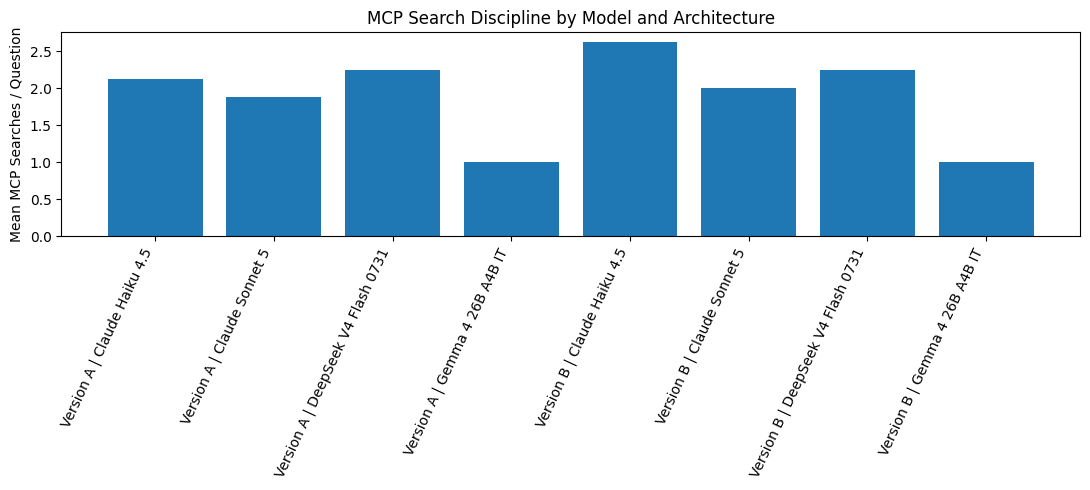

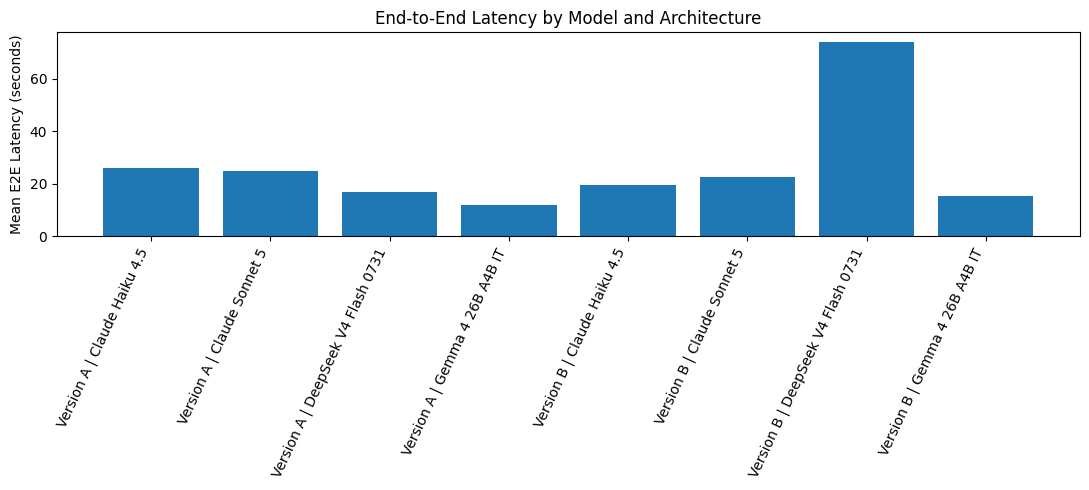

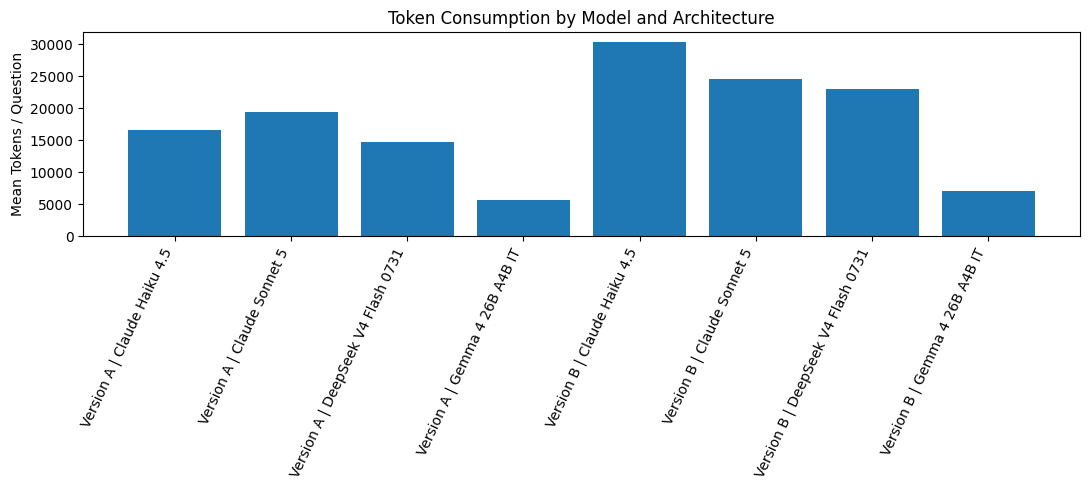


Latency decomposition:


,architecture,model,mean_retrieval_sec,mean_non_retrieval_sec,mean_e2e_sec,retrieval_share_pct,non_retrieval_share_pct
0,Version A,Gemma 4 26B A4B IT,2.39,9.57,11.96,19.97,80.03
1,Version B,Gemma 4 26B A4B IT,5.89,9.47,15.36,38.35,61.65
2,Version A,DeepSeek V4 Flash 0731,4.95,11.74,16.70,29.68,70.32
3,Version B,Claude Haiku 4.5,3.57,15.85,19.42,18.39,81.61
4,Version B,Claude Sonnet 5,4.43,17.98,22.41,19.78,80.22
5,Version A,Claude Sonnet 5,4.82,20.10,24.92,19.35,80.65
6,Version A,Claude Haiku 4.5,12.92,13.10,26.02,49.66,50.34
7,Version B,DeepSeek V4 Flash 0731,3.15,70.81,73.96,4.26,95.74



✓ Execution efficiency analysis completed.
✓ Search count, retrieval latency, non-retrieval latency and token consumption remain separate analytical dimensions.


In [9]:
# ============================================================
# CELL 6 — MCP SEARCH DISCIPLINE + LATENCY + TOKEN ANALYSIS
# ============================================================


# ============================================================
# 1. BUILD RUNTIME-EFFICIENCY SUMMARY
# ============================================================

runtime_efficiency_df = (

    results_df

    .groupby(
        [
            "architecture",
            "model",
            "provider"
        ],
        as_index=False
    )

    .agg(

        questions=(
            "question_id",
            "count"
        ),

        total_mcp_searches=(
            "mcp_searches",
            "sum"
        ),

        mean_mcp_searches=(
            "mcp_searches",
            "mean"
        ),

        one_search_questions=(
            "mcp_searches",
            lambda values:
                int(
                    (
                        values
                        ==
                        1
                    ).sum()
                )
        ),

        two_search_questions=(
            "mcp_searches",
            lambda values:
                int(
                    (
                        values
                        ==
                        2
                    ).sum()
                )
        ),

        three_search_questions=(
            "mcp_searches",
            lambda values:
                int(
                    (
                        values
                        ==
                        3
                    ).sum()
                )
        ),

        mean_retrieval_sec=(
            "retrieval_latency_sec",
            "mean"
        ),

        median_retrieval_sec=(
            "retrieval_latency_sec",
            "median"
        ),

        mean_non_retrieval_sec=(
            "non_retrieval_latency_sec",
            "mean"
        ),

        mean_e2e_sec=(
            "total_latency_sec",
            "mean"
        ),

        median_e2e_sec=(
            "total_latency_sec",
            "median"
        ),

        total_tokens=(
            "total_tokens",
            "sum"
        ),

        mean_tokens=(
            "total_tokens",
            "mean"
        ),

        mean_input_tokens=(
            "input_tokens",
            "mean"
        ),

        mean_output_tokens=(
            "output_tokens",
            "mean"
        ),

        mean_answer_words=(
            "answer_words",
            "mean"
        ),
    )
)


# ============================================================
# 2. DERIVE LATENCY + TOKEN EFFICIENCY METRICS
# ============================================================

runtime_efficiency_df[
    "retrieval_share_pct"
] = np.where(

    runtime_efficiency_df[
        "mean_e2e_sec"
    ]
    >
    0,

    (
        100.0
        *
        runtime_efficiency_df[
            "mean_retrieval_sec"
        ]
        /
        runtime_efficiency_df[
            "mean_e2e_sec"
        ]
    ),

    np.nan
)


runtime_efficiency_df[
    "non_retrieval_share_pct"
] = np.where(

    runtime_efficiency_df[
        "mean_e2e_sec"
    ]
    >
    0,

    (
        100.0
        *
        runtime_efficiency_df[
            "mean_non_retrieval_sec"
        ]
        /
        runtime_efficiency_df[
            "mean_e2e_sec"
        ]
    ),

    np.nan
)


runtime_efficiency_df[
    "tokens_per_search"
] = np.where(

    runtime_efficiency_df[
        "total_mcp_searches"
    ]
    >
    0,

    (
        runtime_efficiency_df[
            "total_tokens"
        ]
        /
        runtime_efficiency_df[
            "total_mcp_searches"
        ]
    ),

    np.nan
)


# ============================================================
# 3. DISPLAY RUNTIME-EFFICIENCY SUMMARY
# ============================================================

print(
    "=" * 110
)

print(
    "MODULE 3 — MCP SEARCH DISCIPLINE + RUNTIME EFFICIENCY"
)

print(
    "=" * 110
)


display(

    runtime_efficiency_df[
        [
            "architecture",
            "model",
            "provider",
            "total_mcp_searches",
            "mean_mcp_searches",
            "one_search_questions",
            "two_search_questions",
            "three_search_questions",
            "mean_retrieval_sec",
            "mean_non_retrieval_sec",
            "mean_e2e_sec",
            "retrieval_share_pct",
            "total_tokens",
            "mean_tokens",
            "tokens_per_search",
            "mean_answer_words",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "mean_e2e_sec"
        ]
    )

    .reset_index(
        drop=True
    )

    .round(2)
)


# ============================================================
# 4. QUESTION-LEVEL SEARCH DISTRIBUTION
# ============================================================

search_distribution_df = (

    results_df

    .groupby(
        [
            "architecture",
            "model",
            "mcp_searches"
        ]
    )

    .size()

    .reset_index(
        name="questions"
    )

    .sort_values(
        [
            "architecture",
            "model",
            "mcp_searches"
        ]
    )
)


print(
    "\nQuestion-level MCP search distribution:"
)

display(
    search_distribution_df
)


# ============================================================
# 5. IDENTIFY LATENCY OUTLIERS
# ============================================================

latency_threshold = (

    results_df[
        "total_latency_sec"
    ]

    .quantile(
        0.90
    )
)


latency_outliers_df = (

    results_df[
        results_df[
            "total_latency_sec"
        ]
        >=
        latency_threshold
    ]

    [
        [
            "architecture",
            "model",
            "question_id",
            "domain",
            "mcp_searches",
            "retrieval_latency_sec",
            "non_retrieval_latency_sec",
            "total_latency_sec",
            "total_tokens",
            "answer_words",
        ]
    ]

    .sort_values(
        "total_latency_sec",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print(
    f"\nTop 10% E2E latency threshold: "
    f"{latency_threshold:.3f} sec"
)

display(
    latency_outliers_df.round(3)
)


# ============================================================
# 6. VISUALIZE MEAN MCP SEARCHES
# ============================================================

plot_df = runtime_efficiency_df.copy()


plot_df[
    "experiment"
] = (

    plot_df[
        "architecture"
    ]

    +
    " | "

    +
    plot_df[
        "model"
    ]
)


plt.figure(
    figsize=(11, 5)
)

plt.bar(
    plot_df[
        "experiment"
    ],
    plot_df[
        "mean_mcp_searches"
    ]
)

plt.ylabel(
    "Mean MCP Searches / Question"
)

plt.title(
    "MCP Search Discipline by Model and Architecture"
)

plt.xticks(
    rotation=65,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. VISUALIZE MEAN E2E LATENCY
# ============================================================

plt.figure(
    figsize=(11, 5)
)

plt.bar(
    plot_df[
        "experiment"
    ],
    plot_df[
        "mean_e2e_sec"
    ]
)

plt.ylabel(
    "Mean E2E Latency (seconds)"
)

plt.title(
    "End-to-End Latency by Model and Architecture"
)

plt.xticks(
    rotation=65,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. VISUALIZE MEAN TOKEN CONSUMPTION
# ============================================================

plt.figure(
    figsize=(11, 5)
)

plt.bar(
    plot_df[
        "experiment"
    ],
    plot_df[
        "mean_tokens"
    ]
)

plt.ylabel(
    "Mean Tokens / Question"
)

plt.title(
    "Token Consumption by Model and Architecture"
)

plt.xticks(
    rotation=65,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. LATENCY DECOMPOSITION
# ============================================================

latency_decomposition_df = (

    runtime_efficiency_df[
        [
            "architecture",
            "model",
            "mean_retrieval_sec",
            "mean_non_retrieval_sec",
            "mean_e2e_sec",
            "retrieval_share_pct",
            "non_retrieval_share_pct",
        ]
    ]

    .sort_values(
        "mean_e2e_sec"
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nLatency decomposition:"
)

display(
    latency_decomposition_df.round(2)
)


print(
    "\n✓ Execution efficiency analysis completed."
)

print(
    "✓ Search count, retrieval latency, "
    "non-retrieval latency and token consumption "
    "remain separate analytical dimensions."
)

**Observation:**
- Runtime behaviour varies strongly by model.
- Gemma consistently used **one MCP search per question** and the fewest tokens, while Claude Haiku and DeepSeek used more repeated searches.
- DeepSeek Version B shows the clearest latency bottleneck outside retrieval, with only **4.26%** of mean E2E time spent in retrieval and **95.74%** in the non-retrieval/model-provider portion.

**Key Decision:**
- Evaluate search discipline, retrieval latency, model/provider latency and token usage independently rather than using E2E latency alone.


# **SECTION 3 — Routing & Source Behaviour**

## **Cell 7 — Route Accuracy + Strict Route Adherence**

**Purpose**: Evaluate whether each model reached the expected 3GPP/TCC/Hybrid route and whether all subsequent MCP searches remained appropriately routed.

In [10]:
# ============================================================
# CELL 7 — ROUTE ACCURACY + STRICT ROUTE ADHERENCE
# ============================================================


# ============================================================
# 1. BUILD ROUTING SUMMARY
# ============================================================

routing_summary_df = (

    results_df

    .groupby(
        [
            "architecture",
            "model",
            "provider"
        ],
        as_index=False
    )

    .agg(

        questions=(
            "question_id",
            "count"
        ),

        route_matches=(
            "route_match",
            lambda values:
                int(
                    values.astype(
                        bool
                    ).sum()
                )
        ),

        strict_route_matches=(
            "strict_route_adherence",
            lambda values:
                int(
                    values.astype(
                        bool
                    ).sum()
                )
        ),

        source_family_matches=(
            "source_family_match",
            lambda values:
                int(
                    values.astype(
                        bool
                    ).sum()
                )
        ),
    )
)


# ============================================================
# 2. CALCULATE ROUTING PERCENTAGES
# ============================================================

routing_summary_df[
    "route_accuracy_pct"
] = (

    100.0
    *
    routing_summary_df[
        "route_matches"
    ]
    /
    routing_summary_df[
        "questions"
    ]
)


routing_summary_df[
    "strict_route_adherence_pct"
] = (

    100.0
    *
    routing_summary_df[
        "strict_route_matches"
    ]
    /
    routing_summary_df[
        "questions"
    ]
)


routing_summary_df[
    "source_family_accuracy_pct"
] = (

    100.0
    *
    routing_summary_df[
        "source_family_matches"
    ]
    /
    routing_summary_df[
        "questions"
    ]
)


# ============================================================
# 3. DISPLAY ROUTING SUMMARY
# ============================================================

print(
    "=" * 105
)

print(
    "MODULE 3 — ROUTE ACCURACY + STRICT ROUTE ADHERENCE"
)

print(
    "=" * 105
)


display(

    routing_summary_df[
        [
            "architecture",
            "model",
            "provider",
            "questions",
            "route_accuracy_pct",
            "strict_route_adherence_pct",
            "source_family_accuracy_pct",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )

    .round(1)
)


# ============================================================
# 4. IDENTIFY ROUTE-DRIFT CASES
# ============================================================

route_drift_df = (

    results_df[
        (
            results_df[
                "route_match"
            ]
            ==
            True
        )
        &
        (
            results_df[
                "strict_route_adherence"
            ]
            ==
            False
        )
    ]

    [
        [
            "architecture",
            "model",
            "question_id",
            "domain",
            "expected_route",
            "routes_used",
            "observed_source_families",
            "mcp_searches",
            "search_queries",
            "status",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "model",
            "question_id"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nCases where the expected route was reached "
    "but strict route adherence failed:"
)


if route_drift_df.empty:

    print(
        "✓ No route-drift cases detected."
    )

else:

    display(
        route_drift_df
    )


# ============================================================
# 5. ROUTE BEHAVIOUR BY EXPECTED DOMAIN
# ============================================================

route_by_scope_df = (

    results_df

    .groupby(
        [
            "architecture",
            "expected_route"
        ],
        as_index=False
    )

    .agg(

        questions=(
            "question_id",
            "count"
        ),

        route_accuracy_pct=(
            "route_match",
            lambda values:
                100.0
                *
                values.astype(
                    bool
                ).mean()
        ),

        strict_route_adherence_pct=(
            "strict_route_adherence",
            lambda values:
                100.0
                *
                values.astype(
                    bool
                ).mean()
        ),
    )
)


print(
    "\nRouting behaviour by expected knowledge route:"
)

display(
    route_by_scope_df.round(1)
)


print(
    "\n✓ Formal route accuracy and supplemental "
    "strict-route adherence remain separate metrics."
)

MODULE 3 — ROUTE ACCURACY + STRICT ROUTE ADHERENCE


,architecture,model,provider,questions,route_accuracy_pct,strict_route_adherence_pct,source_family_accuracy_pct
0,Version A,Claude Haiku 4.5,Anthropic API,8,100.0,87.5,100.0
1,Version A,Claude Sonnet 5,Anthropic API,8,100.0,87.5,100.0
2,Version A,DeepSeek V4 Flash 0731,OpenRouter,8,100.0,87.5,100.0
3,Version A,Gemma 4 26B A4B IT,OpenRouter,8,100.0,87.5,87.5
4,Version B,Claude Haiku 4.5,Anthropic API,8,100.0,87.5,100.0
5,Version B,Claude Sonnet 5,Anthropic API,8,100.0,87.5,100.0
6,Version B,DeepSeek V4 Flash 0731,OpenRouter,8,100.0,100.0,100.0
7,Version B,Gemma 4 26B A4B IT,OpenRouter,8,100.0,100.0,100.0



Cases where the expected route was reached but strict route adherence failed:


,architecture,model,question_id,domain,expected_route,routes_used,observed_source_families,mcp_searches,search_queries,status
0,Version A,Claude Haiku 4.5,Q3,RAN,3gpp,"[3gpp, tcc, 3gpp]","[3GPP, TCC]",3,"[radio link failure detection handling 5G NR, radio link monitoring T310 T312 beam failure detection 5G NR, radio link monitoring RLM beam failure RSRP SINR...",COMPLETED
1,Version A,Claude Sonnet 5,Q5,Security,3gpp,"[3gpp, tcc]","[3GPP, TCC]",2,"[5G authentication procedure AMF AUSF UDM roles, 5G-AKA authentication procedure key hierarchy Kausf Kseaf SUCI SUPI de-concealment]",COMPLETED
2,Version A,DeepSeek V4 Flash 0731,Q5,Security,3gpp,"[3gpp, tcc, 3gpp]","[3GPP, TCC]",3,"[5G authentication procedure AMF AUSF UDM roles, 5G AKA authentication vector SEAF USIM key derivation, 5G AKA SEAF AUSF UDM roles KSEAF serving network nam...",CHECK
3,Version A,Gemma 4 26B A4B IT,Q8,5G SBA + Internet Protocols,hybrid,[hybrid],[TCC],1,[5G Service-Based Architecture HTTP TLS 3GPP IETF roles],COMPLETED
4,Version B,Claude Haiku 4.5,Q3,RAN,3gpp,"[3gpp, 3gpp, tcc]","[3GPP, TCC]",3,"[5G NR radio link failure detection handling, radio link failure RLF detection BLER PHY-RX-FAILURE recovery procedure, T310 T312 MAC PHY PHY-RX-FAILURE out-...",COMPLETED
5,Version B,Claude Sonnet 5,Q5,Security,3gpp,"[3gpp, tcc]","[3GPP, TCC]",2,"[5G authentication procedure AMF AUSF UDM, 5G AKA authentication vector SEAF Nudm_UEAuthentication Nausf_UEAuthentication]",COMPLETED



Routing behaviour by expected knowledge route:


,architecture,expected_route,questions,route_accuracy_pct,strict_route_adherence_pct
0,Version A,3gpp,20,100.0,85.0
1,Version A,hybrid,4,100.0,75.0
2,Version A,tcc,8,100.0,100.0
3,Version B,3gpp,20,100.0,90.0
4,Version B,hybrid,4,100.0,100.0
5,Version B,tcc,8,100.0,100.0



✓ Formal route accuracy and supplemental strict-route adherence remain separate metrics.


**Observation**:
- Formal route accuracy was 100% across all experiments, but strict route adherence exposed several search-drift cases.
- Version B achieved full strict adherence for Gemma and DeepSeek, while Claude models retained some cross-route search drift.

**Key Decision**:
- Use strict route adherence alongside route accuracy because route success alone can hide later query-routing drift.

## **Cell 8 — Source Family + TCC Collection + Hybrid + 3GPP Spec Analysis**

**Purpose**: Verify the actual evidence returned to the LLM, including source-family coverage, TCC collection selection, Hybrid 3GPP+TCC coverage and expected 3GPP specification retrieval.

In [11]:
# ============================================================
# CELL 8 — SOURCE FAMILY + COLLECTION + HYBRID + SPEC ANALYSIS
# ============================================================


# ============================================================
# 1. DERIVE ACTUAL EVIDENCE PROVENANCE PER QUESTION
# ============================================================

evidence_provenance_rows = []


for (
    artifact_key,
    question_id
), group in evidence_df.groupby(
    [
        "artifact_key",
        "question_id"
    ]
):

    source_families = sorted(
        group[
            "source_family"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )


    collections = sorted(
        group[
            "collection"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )


    gpp_specs = sorted(
        group.loc[
            group[
                "source_family"
            ]
            ==
            "3GPP",
            "identifier"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )


    evidence_provenance_rows.append(
        {
            "artifact_key":
                artifact_key,

            "question_id":
                question_id,

            "actual_source_families":
                source_families,

            "actual_collections":
                collections,

            "actual_3gpp_specs":
                gpp_specs,
        }
    )


evidence_provenance_df = pd.DataFrame(
    evidence_provenance_rows
)


# ============================================================
# 2. MERGE WITH QUESTION-LEVEL EXPECTATIONS
# ============================================================

source_analysis_df = (

    results_df

    .merge(
        evidence_provenance_df,
        on=[
            "artifact_key",
            "question_id"
        ],
        how="left"
    )
)


for column in [
    "actual_source_families",
    "actual_collections",
    "actual_3gpp_specs",
]:

    source_analysis_df[
        column
    ] = source_analysis_df[
        column
    ].apply(
        lambda value:
            value
            if isinstance(
                value,
                list
            )
            else []
    )


# ============================================================
# 3. ACTUAL SOURCE-FAMILY COVERAGE
# ============================================================

def actual_source_family_match(
    expected_sources,
    actual_sources
):

    expected = set(
        expected_sources
        or []
    )

    actual = set(
        actual_sources
        or []
    )


    if not expected:

        return True


    return expected.issubset(
        actual
    )


source_analysis_df[
    "actual_source_family_match"
] = source_analysis_df.apply(

    lambda row:
        actual_source_family_match(
            row[
                "expected_source_families"
            ],
            row[
                "actual_source_families"
            ]
        ),

    axis=1
)


# ============================================================
# 4. TCC COLLECTION COVERAGE
# ============================================================

def tcc_collection_coverage(
    expected_collections,
    actual_collections
):

    expected = set(
        expected_collections
        or []
    )

    actual = set(
        actual_collections
        or []
    )


    if not expected:

        return np.nan


    matches = expected.intersection(
        actual
    )


    return (
        100.0
        *
        len(
            matches
        )
        /
        len(
            expected
        )
    )


source_analysis_df[
    "tcc_collection_coverage_pct"
] = source_analysis_df.apply(

    lambda row:
        tcc_collection_coverage(
            row[
                "expected_tcc_collections"
            ],
            row[
                "actual_collections"
            ]
        ),

    axis=1
)


# ============================================================
# 5. 3GPP SPECIFICATION COVERAGE
# ============================================================

def gpp_spec_coverage(
    expected_specs,
    actual_specs
):

    expected = set(
        expected_specs
        or []
    )

    actual = set(
        actual_specs
        or []
    )


    if not expected:

        return np.nan


    matches = expected.intersection(
        actual
    )


    return (
        100.0
        *
        len(
            matches
        )
        /
        len(
            expected
        )
    )


source_analysis_df[
    "gpp_spec_coverage_pct"
] = source_analysis_df.apply(

    lambda row:
        gpp_spec_coverage(
            row[
                "expected_3gpp_specs"
            ],
            row[
                "actual_3gpp_specs"
            ]
        ),

    axis=1
)


# ============================================================
# 6. HYBRID SOURCE-FAMILY COVERAGE
# ============================================================

def hybrid_source_coverage(
    expected_route,
    actual_source_families
):

    if (
        str(
            expected_route
        ).lower()
        !=
        "hybrid"
    ):

        return np.nan


    return {
        "3GPP",
        "TCC"
    }.issubset(
        set(
            actual_source_families
            or []
        )
    )


source_analysis_df[
    "hybrid_source_coverage"
] = source_analysis_df.apply(

    lambda row:
        hybrid_source_coverage(
            row[
                "expected_route"
            ],
            row[
                "actual_source_families"
            ]
        ),

    axis=1
)


# ============================================================
# 7. SOURCE-FAMILY SUMMARY
# ============================================================

source_family_summary_df = (

    source_analysis_df

    .groupby(
        [
            "architecture",
            "model"
        ],
        as_index=False
    )

    .agg(

        actual_source_family_accuracy_pct=(
            "actual_source_family_match",

            lambda values:
                100.0
                *
                values.astype(
                    bool
                ).mean()
        ),

        mean_gpp_spec_coverage_pct=(
            "gpp_spec_coverage_pct",
            "mean"
        ),

        mean_tcc_collection_coverage_pct=(
            "tcc_collection_coverage_pct",
            "mean"
        ),
    )
)


print(
    "=" * 110
)

print(
    "MODULE 3 — SOURCE / COLLECTION / SPECIFICATION ANALYSIS"
)

print(
    "=" * 110
)


display(
    source_family_summary_df
    .sort_values(
        [
            "architecture",
            "model"
        ]
    )
    .reset_index(
        drop=True
    )
    .round(1)
)


# ============================================================
# 8. Q7 — RESEARCH COLLECTION CASE
# ============================================================

q7_collection_df = (

    source_analysis_df[
        source_analysis_df[
            "question_id"
        ]
        ==
        "Q7"
    ]

    [
        [
            "architecture",
            "model",
            "search_queries",
            "actual_collections",
            "expected_tcc_collections",
            "tcc_collection_coverage_pct",
            "status",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nQ7 — IEEE/OpenAlex research-collection case:"
)

display(
    q7_collection_df
)


# ============================================================
# 9. Q8 — HYBRID SOURCE COVERAGE
# ============================================================

q8_hybrid_df = (

    source_analysis_df[
        source_analysis_df[
            "question_id"
        ]
        ==
        "Q8"
    ]

    [
        [
            "architecture",
            "model",
            "routes_used",
            "actual_source_families",
            "actual_collections",
            "actual_3gpp_specs",
            "hybrid_source_coverage",
            "status",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nQ8 — Hybrid 3GPP + TCC evidence coverage:"
)

display(
    q8_hybrid_df
)


# ============================================================
# 10. QUESTION-LEVEL 3GPP SPECIFICATION DIAGNOSTIC
# ============================================================

gpp_spec_detail_df = (

    source_analysis_df[
        source_analysis_df[
            "expected_3gpp_specs"
        ].apply(
            lambda value:
                len(
                    value
                    or []
                )
                >
                0
        )
    ]

    [
        [
            "architecture",
            "model",
            "question_id",
            "expected_3gpp_specs",
            "actual_3gpp_specs",
            "gpp_spec_coverage_pct",
        ]
    ]

    .sort_values(
        [
            "question_id",
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n3GPP specification coverage diagnostic:"
)

display(
    gpp_spec_detail_df
)


print(
    "\n✓ Source-family, collection, Hybrid and "
    "3GPP-specification behaviour evaluated from "
    "the evidence actually returned to the LLM."
)

MODULE 3 — SOURCE / COLLECTION / SPECIFICATION ANALYSIS


,architecture,model,actual_source_family_accuracy_pct,mean_gpp_spec_coverage_pct,mean_tcc_collection_coverage_pct
0,Version A,Claude Haiku 4.5,100.0,86.1,66.7
1,Version A,Claude Sonnet 5,100.0,94.4,50.0
2,Version A,DeepSeek V4 Flash 0731,100.0,94.4,66.7
3,Version A,Gemma 4 26B A4B IT,87.5,77.8,66.7
4,Version B,Claude Haiku 4.5,100.0,86.1,33.3
5,Version B,Claude Sonnet 5,100.0,94.4,50.0
6,Version B,DeepSeek V4 Flash 0731,100.0,94.4,33.3
7,Version B,Gemma 4 26B A4B IT,100.0,80.6,66.7



Q7 — IEEE/OpenAlex research-collection case:


,architecture,model,search_queries,actual_collections,expected_tcc_collections,tcc_collection_coverage_pct,status
0,Version A,Claude Haiku 4.5,"[AI ML traffic prediction mobile network management benefits challenges, machine learning deep learning traffic forecasting prediction mobile networks resou...",[Wikipedia-Telecom],"[IEEE-Access, OpenAlex]",0.0,COMPLETED
1,Version A,Claude Sonnet 5,"[AI/ML traffic prediction mobile network management benefits challenges, machine learning network traffic forecasting self-organizing networks SON]",[Wikipedia-Telecom],"[IEEE-Access, OpenAlex]",0.0,COMPLETED
2,Version A,DeepSeek V4 Flash 0731,"[AI/ML traffic prediction mobile network management benefits challenges, machine learning mobile traffic forecasting network optimization technical challeng...",[Wikipedia-Telecom],"[IEEE-Access, OpenAlex]",0.0,COMPLETED
3,Version A,Gemma 4 26B A4B IT,[benefits and technical challenges of AI/ML-based traffic prediction for mobile network management IEEE research],"[IEEE-Access, OpenAlex]","[IEEE-Access, OpenAlex]",100.0,COMPLETED
4,Version B,Claude Haiku 4.5,"[AI ML machine learning traffic prediction mobile network management, traffic prediction network optimization resource management deep learning neural netwo...",[Wikipedia-Telecom],"[IEEE-Access, OpenAlex]",0.0,COMPLETED
5,Version B,Claude Sonnet 5,"[AI/ML traffic prediction mobile network management benefits challenges, machine learning network traffic forecasting self-organizing network RAN optimization]",[Wikipedia-Telecom],"[IEEE-Access, OpenAlex]",0.0,COMPLETED
6,Version B,DeepSeek V4 Flash 0731,"[AI/ML based traffic prediction mobile network management benefits challenges, machine learning mobile traffic forecasting network optimization challenges, ...",[Wikipedia-Telecom],"[IEEE-Access, OpenAlex]",0.0,COMPLETED
7,Version B,Gemma 4 26B A4B IT,[AI/ML-based traffic prediction mobile network management benefits technical challenges IEEE],"[IEEE-Access, OpenAlex]","[IEEE-Access, OpenAlex]",100.0,COMPLETED



Q8 — Hybrid 3GPP + TCC evidence coverage:


,architecture,model,routes_used,actual_source_families,actual_collections,actual_3gpp_specs,hybrid_source_coverage,status
0,Version A,Claude Haiku 4.5,"[tcc, hybrid, tcc]","[3GPP, TCC]","[3GPP, IETF-Drafts, IETF-RFCs]",[23.501],True,COMPLETED
1,Version A,Claude Sonnet 5,"[hybrid, 3gpp]","[3GPP, TCC]","[3GPP, IETF-Drafts]","[23.501, 29.500, 33.501]",True,COMPLETED
2,Version A,DeepSeek V4 Flash 0731,"[hybrid, 3gpp]","[3GPP, TCC]","[3GPP, IETF-Drafts, IETF-RFCs]","[23.501, 29.500, 33.501]",True,CHECK
3,Version A,Gemma 4 26B A4B IT,[hybrid],[TCC],[IETF-Drafts],[],False,COMPLETED
4,Version B,Claude Haiku 4.5,"[hybrid, 3gpp, 3gpp]","[3GPP, TCC]","[3GPP-Specifications, IETF-Drafts]","[23.369, 23.501, 23.731, 29.500, 29.501, 29.891, 33.127]",True,COMPLETED
5,Version B,Claude Sonnet 5,"[tcc, hybrid, 3gpp]","[3GPP, TCC]","[3GPP-Specifications, IETF-Drafts, IETF-RFCs]","[23.501, 33.501]",True,COMPLETED
6,Version B,DeepSeek V4 Flash 0731,"[hybrid, 3gpp, 3gpp]","[3GPP, TCC]","[3GPP-Specifications, IETF-Drafts]","[23.501, 29.500, 33.501]",True,COMPLETED
7,Version B,Gemma 4 26B A4B IT,[hybrid],"[3GPP, TCC]","[3GPP-Specifications, IETF-Drafts]",[23.501],True,COMPLETED



3GPP specification coverage diagnostic:


,architecture,model,question_id,expected_3gpp_specs,actual_3gpp_specs,gpp_spec_coverage_pct
0,Version A,Claude Haiku 4.5,Q1,"[23.501, 23.502]","[23.501, 23.502]",100.000000
1,Version A,Claude Sonnet 5,Q1,"[23.501, 23.502]","[23.501, 23.502, 24.501]",100.000000
2,Version A,DeepSeek V4 Flash 0731,Q1,"[23.501, 23.502]","[23.501, 23.502, 38.300]",100.000000
3,Version A,Gemma 4 26B A4B IT,Q1,"[23.501, 23.502]","[23.501, 23.502]",100.000000
4,Version B,Claude Haiku 4.5,Q1,"[23.501, 23.502]","[23.501, 23.502, 33.501]",100.000000
5,Version B,Claude Sonnet 5,Q1,"[23.501, 23.502]","[23.501, 23.502]",100.000000
6,Version B,DeepSeek V4 Flash 0731,Q1,"[23.501, 23.502]","[23.501, 23.502]",100.000000
7,Version B,Gemma 4 26B A4B IT,Q1,"[23.501, 23.502]","[23.501, 23.502]",100.000000
8,Version A,Claude Haiku 4.5,Q2,"[23.502, 38.300, 38.423]","[23.501, 23.502, 38.300]",66.666667
9,Version A,Claude Sonnet 5,Q2,"[23.502, 38.300, 38.423]","[23.501, 23.502, 38.300]",66.666667



✓ Source-family, collection, Hybrid and 3GPP-specification behaviour evaluated from the evidence actually returned to the LLM.


**Observation**:
- Source-family coverage was generally strong, but collection and specification selection varied by model.
- The clearest case was Q7, where only Gemma reached the intended IEEE-Access and OpenAlex collections in both architectures.
- Version A Gemma also failed full Hybrid source coverage for Q8, while Version B restored both 3GPP and TCC evidence.

**Key Decision**:
- Evaluate source, collection and specification selection separately because correct routing does not guarantee retrieval of the intended authoritative evidence.

# **SECTION 4 — Retrieval & Response Diagnostics**

## **Cell 9  — Expected-Element Coverage**
**Purpose**:
- Measure whether each final answer explicitly addresses the benchmark's predefined technical elements for every question
- This is a deterministic coverage diagnostic only; presence of the expected terms does not establish technical correctness.

In [12]:
# ============================================================
# CELL 9 — EXPECTED-ELEMENT COVERAGE
# ============================================================


# ============================================================
# 1. BENCHMARK ELEMENT MATCHING PATTERNS
# ============================================================

ELEMENT_PATTERNS = {

    "Q1": {

        "AMF":
            r"\bamf\b",

        "registration":
            r"\bregistration\b",

        "mobility management":
            r"\bmobility(?:\s+management)?\b",

        "NAS":
            r"\bnas\b",

        "N1":
            r"\bn1\b",

        "N2":
            r"\bn2\b",
    },


    "Q2": {

        "source gNB":
            r"\bsource\s+g(?:nb|nodeb)\b",

        "target gNB":
            r"\btarget\s+g(?:nb|nodeb)\b",

        "AMF":
            r"\bamf\b",

        "handover":
            r"\bhandover\b",

        "Xn":
            r"\bxn(?:ap|-u)?\b",

        "N2":
            r"\bn2\b",
    },


    "Q3": {

        "radio link failure":
            r"\b(?:radio\s+link\s+failure|rlf)\b",

        "RLF":
            r"\b(?:rlf|radio\s+link\s+failure)\b",

        "RRC":
            r"\brrc\b",

        "T310":
            r"\bt310\b",

        "N310":
            r"\bn310\b",

        "RRC re-establishment":
            (
                r"\b(?:rrc\s+)?"
                r"re[\s-]?establish"
                r"(?:ment|ed|ing)?\b"
            ),
    },


    "Q4": {

        "5QI":
            r"\b5qi\b",

        "QoS Flow":
            r"\bqos\s+flow(?:s)?\b",

        "QFI":
            r"\bqfi\b",

        "SMF":
            r"\bsmf\b",

        "UPF":
            r"\bupf\b",

        "QoS rules":
            r"\bqos\s+rule(?:s)?\b",
    },


    "Q5": {

        "AMF":
            r"\bamf\b",

        "AUSF":
            r"\bausf\b",

        "UDM":
            r"\budm\b",

        "5G-AKA":
            r"\b5g[\s-]?aka\b",

        "SEAF":
            r"\bseaf\b",

        "authentication":
            r"\bauthenticat(?:e|ed|es|ing|ion)\b",
    },


    "Q6": {

        "QUIC":
            r"\bquic\b",

        "TLS 1.3":
            r"\btls\s*1\.3\b",

        "stream multiplexing":
            (
                r"(?=.*\bstream(?:s)?\b)"
                r"(?=.*\bmultiplex(?:ing|ed)?\b)"
            ),

        "Connection ID":
            r"\b(?:connection\s+id|cid)\b",

        "connection migration":
            r"\b(?:connection\s+)?migration\b",
    },


    "Q7": {

        "traffic prediction":
            (
                r"\btraffic\s+"
                r"(?:prediction|forecast(?:ing)?)\b"
            ),

        "machine learning":
            r"\b(?:machine\s+learning|ml|ai)\b",

        "forecasting":
            r"\b(?:forecast(?:ing)?|prediction)\b",

        "network management":
            (
                r"\bnetwork\s+"
                r"(?:management|optim(?:ization|isation))\b"
            ),

        "benefits":
            (
                r"\b(?:benefit(?:s)?|"
                r"advantage(?:s)?|"
                r"improvement(?:s)?)\b"
            ),

        "challenges":
            (
                r"\b(?:challenge(?:s)?|"
                r"limitation(?:s)?|"
                r"constraint(?:s)?)\b"
            ),
    },


    "Q8": {

        "Service-Based Architecture":
            (
                r"\b(?:service[\s-]?based\s+architecture|sba)\b"
            ),

        "AMF":
            r"\bamf\b",

        "SMF":
            r"\bsmf\b",

        "HTTP":
            r"\bhttp(?:/2|/3)?\b",

        "TLS":
            r"\btls\b",

        "3GPP":
            r"\b3gpp\b",

        "IETF":
            r"\bietf\b",
    },
}


# ============================================================
# 2. COVERAGE FUNCTION
# ============================================================

def calculate_element_coverage(
    question_id,
    text
):

    patterns = ELEMENT_PATTERNS[
        question_id
    ]


    text = str(
        text
        or ""
    )


    found = []

    missing = []


    for (
        element,
        pattern
    ) in patterns.items():

        matched = re.search(
            pattern,
            text,
            flags=(
                re.IGNORECASE
                |
                re.DOTALL
            )
        )


        if matched:

            found.append(
                element
            )

        else:

            missing.append(
                element
            )


    total = len(
        patterns
    )


    coverage_pct = (

        100.0
        *
        len(
            found
        )
        /
        total

        if total > 0

        else np.nan
    )


    return {

        "coverage_pct":
            coverage_pct,

        "found":
            found,

        "missing":
            missing,

        "found_count":
            len(
                found
            ),

        "expected_count":
            total,
    }


# ============================================================
# 3. APPLY TO FINAL ANSWERS
# ============================================================

answer_element_rows = []


for _, row in results_df.iterrows():

    coverage = calculate_element_coverage(

        row[
            "question_id"
        ],

        row[
            "answer"
        ]
    )


    answer_element_rows.append(
        {
            "artifact_key":
                row[
                    "artifact_key"
                ],

            "architecture":
                row[
                    "architecture"
                ],

            "model":
                row[
                    "model"
                ],

            "question_id":
                row[
                    "question_id"
                ],

            "domain":
                row[
                    "domain"
                ],

            "status":
                row[
                    "status"
                ],

            "expected_elements":
                row[
                    "expected_elements"
                ],

            "found_elements":
                coverage[
                    "found"
                ],

            "missing_elements":
                coverage[
                    "missing"
                ],

            "found_count":
                coverage[
                    "found_count"
                ],

            "expected_count":
                coverage[
                    "expected_count"
                ],

            "answer_element_coverage_pct":
                coverage[
                    "coverage_pct"
                ],
        }
    )


answer_element_df = pd.DataFrame(
    answer_element_rows
)


# ============================================================
# 4. AGGREGATE BY EXPERIMENT
# ============================================================

answer_element_summary_df = (

    answer_element_df

    .groupby(
        [
            "architecture",
            "model"
        ],
        as_index=False
    )

    .agg(

        mean_answer_element_coverage_pct=(
            "answer_element_coverage_pct",
            "mean"
        ),

        minimum_answer_element_coverage_pct=(
            "answer_element_coverage_pct",
            "min"
        ),
    )
)


print(
    "=" * 105
)

print(
    "MODULE 3 — EXPECTED-ELEMENT COVERAGE"
)

print(
    "=" * 105
)


display(
    answer_element_summary_df
    .sort_values(
        [
            "architecture",
            "model"
        ]
    )
    .reset_index(
        drop=True
    )
    .round(1)
)


# ============================================================
# 5. SHOW INCOMPLETE COVERAGE CASES
# ============================================================

incomplete_answer_elements_df = (

    answer_element_df[
        answer_element_df[
            "answer_element_coverage_pct"
        ]
        <
        100.0
    ]

    [
        [
            "architecture",
            "model",
            "question_id",
            "domain",
            "status",
            "answer_element_coverage_pct",
            "missing_elements",
        ]
    ]

    .sort_values(
        [
            "question_id",
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nAnswers with incomplete expected-element coverage:"
)


if incomplete_answer_elements_df.empty:

    print(
        "✓ All answers explicitly covered "
        "all benchmark elements."
    )

else:

    display(
        incomplete_answer_elements_df
    )


print(
    "\nNOTE:"
)

print(
    "Expected-element coverage is a deterministic "
    "diagnostic only; it does not establish technical correctness."
)

MODULE 3 — EXPECTED-ELEMENT COVERAGE


,architecture,model,mean_answer_element_coverage_pct,minimum_answer_element_coverage_pct
0,Version A,Claude Haiku 4.5,97.9,83.3
1,Version A,Claude Sonnet 5,100.0,100.0
2,Version A,DeepSeek V4 Flash 0731,83.3,0.0
3,Version A,Gemma 4 26B A4B IT,91.7,50.0
4,Version B,Claude Haiku 4.5,89.2,66.7
5,Version B,Claude Sonnet 5,100.0,100.0
6,Version B,DeepSeek V4 Flash 0731,100.0,100.0
7,Version B,Gemma 4 26B A4B IT,87.5,66.7



Answers with incomplete expected-element coverage:


,architecture,model,question_id,domain,status,answer_element_coverage_pct,missing_elements
0,Version A,DeepSeek V4 Flash 0731,Q1,5G Core,COMPLETED,83.333333,[N1]
1,Version A,Gemma 4 26B A4B IT,Q1,5G Core,COMPLETED,50.000000,"[NAS, N1, N2]"
2,Version B,Gemma 4 26B A4B IT,Q1,5G Core,COMPLETED,83.333333,[NAS]
3,Version B,Gemma 4 26B A4B IT,Q2,Mobility,COMPLETED,83.333333,[N2]
4,Version A,Claude Haiku 4.5,Q3,RAN,COMPLETED,83.333333,[N310]
5,Version A,DeepSeek V4 Flash 0731,Q3,RAN,COMPLETED,83.333333,[N310]
6,Version A,Gemma 4 26B A4B IT,Q3,RAN,COMPLETED,83.333333,[N310]
7,Version B,Claude Haiku 4.5,Q3,RAN,COMPLETED,66.666667,"[RRC, N310]"
8,Version B,Gemma 4 26B A4B IT,Q3,RAN,COMPLETED,66.666667,"[T310, N310]"
9,Version A,DeepSeek V4 Flash 0731,Q4,QoS,CHECK,0.000000,"[5QI, QoS Flow, QFI, SMF, UPF, QoS rules]"



NOTE:
Expected-element coverage is a deterministic diagnostic only; it does not establish technical correctness.


**Observation**:
- Expected-element coverage varied materially across models.
- Claude Sonnet achieved 100% mean coverage in both architectures, while several other models omitted specific technical elements such as N310, N2, QFI, QoS rules or TLS 1.3.
- DeepSeek Version A also recorded 0% coverage for Q4 because the CHECK outcome produced no usable final answer.

## **Cell 10 — Evidence Coverage + Evidence Authority Diagnostics**
**Purpose**:
- Assess whether the retrieved evidence itself contains the benchmark's required technical elements and whether that evidence comes from the expected authoritative specifications or collections.
- This separates:
  - answer completeness — what the model said;
  - evidence sufficiency — what the model received;
  - evidence authority — whether the evidence came from the intended source.

In [13]:
# ============================================================
# CELL 10 — EVIDENCE COVERAGE + AUTHORITY DIAGNOSTICS
# ============================================================


# ============================================================
# 1. CREATE A DEDUPLICATED EVIDENCE POOL
# ============================================================

def unique_evidence_pool(
    artifact_key,
    question_id
):

    pool = (

        evidence_df[
            (
                evidence_df[
                    "artifact_key"
                ]
                ==
                artifact_key
            )
            &
            (
                evidence_df[
                    "question_id"
                ]
                ==
                question_id
            )
        ]

        .copy()
    )


    # Repeated MCP searches may return the same source/excerpt.
    # Deduplicate for quality analysis while leaving evidence_df
    # itself unchanged for auditability.

    pool = pool.drop_duplicates(

        subset=[
            "source_family",
            "collection",
            "identifier",
            "title",
            "evidence",
        ]
    )


    return pool.reset_index(
        drop=True
    )


# ============================================================
# 2. BENCHMARK-ALIGNED AUTHORITY FUNCTION
# ============================================================

def evidence_authority_alignment(
    row,
    evidence_pool
):

    if evidence_pool.empty:

        return np.nan


    expected_route = str(
        row[
            "expected_route"
        ]
    ).lower()


    expected_specs = set(
        row[
            "expected_3gpp_specs"
        ]
        or []
    )


    expected_collections = set(
        row[
            "expected_tcc_collections"
        ]
        or []
    )


    alignment_results = []


    for _, evidence in evidence_pool.iterrows():

        source_family = str(
            evidence[
                "source_family"
            ]
        )


        collection = str(
            evidence[
                "collection"
            ]
        )


        identifier = str(
            evidence[
                "identifier"
            ]
        )


        aligned = False


        # ----------------------------------------------------
        # 3GPP question
        # ----------------------------------------------------

        if expected_route == "3gpp":

            aligned = (

                source_family
                ==
                "3GPP"

                and

                (
                    not expected_specs

                    or

                    identifier
                    in
                    expected_specs
                )
            )


        # ----------------------------------------------------
        # TCC question
        # ----------------------------------------------------

        elif expected_route == "tcc":

            aligned = (

                source_family
                ==
                "TCC"

                and

                (
                    not expected_collections

                    or

                    collection
                    in
                    expected_collections
                )
            )


        # ----------------------------------------------------
        # Hybrid question
        # ----------------------------------------------------

        elif expected_route == "hybrid":

            gpp_aligned = (

                source_family
                ==
                "3GPP"

                and

                (
                    not expected_specs

                    or

                    identifier
                    in
                    expected_specs
                )
            )


            tcc_aligned = (

                source_family
                ==
                "TCC"

                and

                (
                    not expected_collections

                    or

                    collection
                    in
                    expected_collections
                )
            )


            aligned = (

                gpp_aligned
                or
                tcc_aligned
            )


        alignment_results.append(
            aligned
        )


    return (

        100.0

        *

        np.mean(
            alignment_results
        )
    )


# ============================================================
# 3. BUILD QUESTION-LEVEL EVIDENCE DIAGNOSTICS
# ============================================================

evidence_quality_rows = []


for _, row in results_df.iterrows():

    pool = unique_evidence_pool(

        row[
            "artifact_key"
        ],

        row[
            "question_id"
        ]
    )


    pooled_evidence_text = "\n\n".join(

        pool[
            "evidence"
        ]

        .fillna(
            ""
        )

        .astype(
            str
        )

        .tolist()
    )


    coverage = calculate_element_coverage(

        row[
            "question_id"
        ],

        pooled_evidence_text
    )


    authority_alignment_pct = (
        evidence_authority_alignment(
            row,
            pool
        )
    )


    evidence_quality_rows.append(
        {
            "artifact_key":
                row[
                    "artifact_key"
                ],

            "architecture":
                row[
                    "architecture"
                ],

            "model":
                row[
                    "model"
                ],

            "question_id":
                row[
                    "question_id"
                ],

            "domain":
                row[
                    "domain"
                ],

            "status":
                row[
                    "status"
                ],

            "unique_evidence_excerpts":
                len(
                    pool
                ),

            "evidence_element_coverage_pct":
                coverage[
                    "coverage_pct"
                ],

            "evidence_found_elements":
                coverage[
                    "found"
                ],

            "evidence_missing_elements":
                coverage[
                    "missing"
                ],

            "evidence_authority_alignment_pct":
                authority_alignment_pct,
        }
    )


evidence_quality_df = pd.DataFrame(
    evidence_quality_rows
)


# ============================================================
# 4. AGGREGATE EVIDENCE QUALITY DIAGNOSTICS
# ============================================================

evidence_quality_summary_df = (

    evidence_quality_df

    .groupby(
        [
            "architecture",
            "model"
        ],
        as_index=False
    )

    .agg(

        mean_evidence_element_coverage_pct=(
            "evidence_element_coverage_pct",
            "mean"
        ),

        minimum_evidence_element_coverage_pct=(
            "evidence_element_coverage_pct",
            "min"
        ),

        mean_evidence_authority_alignment_pct=(
            "evidence_authority_alignment_pct",
            "mean"
        ),

        mean_unique_evidence_excerpts=(
            "unique_evidence_excerpts",
            "mean"
        ),
    )
)


print(
    "=" * 110
)

print(
    "MODULE 3 — EVIDENCE COVERAGE + AUTHORITY DIAGNOSTICS"
)

print(
    "=" * 110
)


display(

    evidence_quality_summary_df

    .sort_values(
        [
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )

    .round(1)
)


# ============================================================
# 5. IDENTIFY EVIDENCE GAPS
# ============================================================

evidence_gap_df = (

    evidence_quality_df[
        (
            evidence_quality_df[
                "evidence_element_coverage_pct"
            ]
            <
            100.0
        )
        |
        (
            evidence_quality_df[
                "evidence_authority_alignment_pct"
            ]
            <
            100.0
        )
    ]

    [
        [
            "architecture",
            "model",
            "question_id",
            "domain",
            "evidence_element_coverage_pct",
            "evidence_missing_elements",
            "evidence_authority_alignment_pct",
            "unique_evidence_excerpts",
        ]
    ]

    .sort_values(
        [
            "question_id",
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nEvidence cases requiring closer review:"
)

display(
    evidence_gap_df
)


# ============================================================
# 6. COMBINE ANSWER + EVIDENCE DIAGNOSTICS
# ============================================================

response_evidence_diagnostic_df = (

    answer_element_df[
        [
            "artifact_key",
            "architecture",
            "model",
            "question_id",
            "answer_element_coverage_pct",
            "missing_elements",
        ]
    ]

    .merge(

        evidence_quality_df[
            [
                "artifact_key",
                "question_id",
                "evidence_element_coverage_pct",
                "evidence_missing_elements",
                "evidence_authority_alignment_pct",
                "unique_evidence_excerpts",
            ]
        ],

        on=[
            "artifact_key",
            "question_id"
        ],

        how="left"
    )
)


print(
    "\nCombined answer/evidence diagnostic preview:"
)

display(

    response_evidence_diagnostic_df

    .sort_values(
        [
            "question_id",
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )

    .head(
        20
    )
)


print(
    "\nNOTE:"
)

print(
    "Evidence coverage and authority alignment are "
    "diagnostics, not claim-grounding verdicts."
)

print(
    "Strict groundedness will be assessed later by "
    "comparing individual answer claims with the saved "
    "evidence excerpts."
)

MODULE 3 — EVIDENCE COVERAGE + AUTHORITY DIAGNOSTICS


,architecture,model,mean_evidence_element_coverage_pct,minimum_evidence_element_coverage_pct,mean_evidence_authority_alignment_pct,mean_unique_evidence_excerpts
0,Version A,Claude Haiku 4.5,89.6,33.3,70.6,8.2
1,Version A,Claude Sonnet 5,87.1,33.3,70.8,8.0
2,Version A,DeepSeek V4 Flash 0731,87.1,50.0,69.6,8.8
3,Version A,Gemma 4 26B A4B IT,85.3,66.7,88.8,4.2
4,Version B,Claude Haiku 4.5,93.8,83.3,64.1,12.1
5,Version B,Claude Sonnet 5,89.6,66.7,68.8,9.2
6,Version B,DeepSeek V4 Flash 0731,88.4,57.1,78.1,10.1
7,Version B,Gemma 4 26B A4B IT,67.3,33.3,90.0,4.8



Evidence cases requiring closer review:


,architecture,model,question_id,domain,evidence_element_coverage_pct,evidence_missing_elements,evidence_authority_alignment_pct,unique_evidence_excerpts
0,Version A,Claude Sonnet 5,Q1,5G Core,100.000000,[],88.888889,9
1,Version A,DeepSeek V4 Flash 0731,Q1,5G Core,83.333333,[N1],88.888889,9
2,Version A,Gemma 4 26B A4B IT,Q1,5G Core,66.666667,"[NAS, N1]",100.000000,4
3,Version B,Claude Haiku 4.5,Q1,5G Core,100.000000,[],86.666667,15
4,Version B,Claude Sonnet 5,Q1,5G Core,83.333333,[NAS],100.000000,10
5,Version B,Gemma 4 26B A4B IT,Q1,5G Core,66.666667,"[NAS, N2]",100.000000,5
6,Version A,Claude Haiku 4.5,Q2,Mobility,100.000000,[],60.000000,5
7,Version A,Claude Sonnet 5,Q2,Mobility,100.000000,[],77.777778,9
8,Version A,DeepSeek V4 Flash 0731,Q2,Mobility,100.000000,[],60.000000,5
9,Version A,Gemma 4 26B A4B IT,Q2,Mobility,100.000000,[],60.000000,5



Combined answer/evidence diagnostic preview:


,artifact_key,architecture,model,question_id,answer_element_coverage_pct,missing_elements,evidence_element_coverage_pct,evidence_missing_elements,evidence_authority_alignment_pct,unique_evidence_excerpts
0,A_HAIKU,Version A,Claude Haiku 4.5,Q1,100.000000,[],100.000000,[],100.000000,4
1,A_SONNET,Version A,Claude Sonnet 5,Q1,100.000000,[],100.000000,[],88.888889,9
2,A_DEEPSEEK,Version A,DeepSeek V4 Flash 0731,Q1,83.333333,[N1],83.333333,[N1],88.888889,9
3,A_GEMMA,Version A,Gemma 4 26B A4B IT,Q1,50.000000,"[NAS, N1, N2]",66.666667,"[NAS, N1]",100.000000,4
4,B_HAIKU,Version B,Claude Haiku 4.5,Q1,100.000000,[],100.000000,[],86.666667,15
5,B_SONNET,Version B,Claude Sonnet 5,Q1,100.000000,[],83.333333,[NAS],100.000000,10
6,B_DEEPSEEK,Version B,DeepSeek V4 Flash 0731,Q1,100.000000,[],100.000000,[],100.000000,12
7,B_GEMMA,Version B,Gemma 4 26B A4B IT,Q1,83.333333,[NAS],66.666667,"[NAS, N2]",100.000000,5
8,A_HAIKU,Version A,Claude Haiku 4.5,Q2,100.000000,[],100.000000,[],60.000000,5
9,A_SONNET,Version A,Claude Sonnet 5,Q2,100.000000,[],100.000000,[],77.777778,9



NOTE:
Evidence coverage and authority alignment are diagnostics, not claim-grounding verdicts.
Strict groundedness will be assessed later by comparing individual answer claims with the saved evidence excerpts.


**Observation**:
- Evidence quality was mixed even when routing succeeded.
- Version B generally improved evidence-element coverage for some models, while Gemma returned fewer but more authority-aligned excerpts.
- Q7 again exposed the clearest retrieval gap: non-Gemma runs largely missed the intended IEEE/OpenAlex research evidence, whereas Gemma achieved full authority alignment.

**Key Decision**:
- Keep evidence coverage and authority alignment as diagnostics only.
- Final groundedness must be assessed claim-by-claim against the saved evidence excerpts.

# **SECTION 5 — Technical Quality & Grounding**
**Purpose**: Move beyond execution and retrieval diagnostics to evaluate whether the final answers are technically correct, complete, relevant and supported by the evidence actually retrieved.

## **Cell 11 — LLM Technical-Quality Judge**

**Purpose:** Independently score all 64 frozen answers for **technical correctness, completeness, relevance and engineering quality**, each on a 1–5 scale.

**Important:** The GPT-5.6 Sol Pro judge is not told the evaluated model or architecture identity. It may use its own technical knowledge in this cell because the objective is answer quality, not evidence grounding. The judge is a consistent automated evaluator, not human ground truth.


In [21]:
# ============================================================
# CELL 11 — GPT-5.6 SOL PRO TECHNICAL-QUALITY JUDGE
# ============================================================

import hashlib
import json
import time
import subprocess
import sys
from pathlib import Path


# ============================================================
# 1. OPENAI-COMPATIBLE CLIENT
# ============================================================

try:
    from openai import OpenAI
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "openai",
        ]
    )
    from openai import OpenAI


from google.colab import userdata


OPENROUTER_API_KEY = userdata.get(
    "OPENROUTER_API_KEY"
)

if not OPENROUTER_API_KEY:
    raise RuntimeError(
        "OPENROUTER_API_KEY was not found in Colab Secrets."
    )


judge_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    timeout=300.0,
    max_retries=0,
)


# ============================================================
# 2. FROZEN JUDGE CONFIGURATION
# ============================================================

JUDGE_MODEL = "openai/gpt-5.6-sol-pro"

JUDGE_PROVIDER = {
    "only": ["openai"],
    "allow_fallbacks": False,
    "require_parameters": True,
}


JUDGE_QUALITY_SYSTEM_PROMPT = """
You are an independent technical evaluator of telecom and
network-protocol answers.

Evaluate the supplied answer to the benchmark question.

Score four dimensions from 1 to 5:

1. Technical correctness
   1 = materially incorrect
   2 = major technical problems
   3 = broadly correct with meaningful issues
   4 = technically strong with only minor issues
   5 = highly accurate and precise

2. Completeness
   1 = largely unanswered
   2 = major required elements missing
   3 = adequate but incomplete
   4 = strong coverage with minor omissions
   5 = comprehensive for the question asked

3. Relevance
   1 = largely irrelevant
   2 = substantial irrelevant content
   3 = generally relevant but unfocused
   4 = focused and relevant
   5 = highly focused and efficient

4. Engineering quality
   1 = unusable engineering explanation
   2 = weak or confusing
   3 = acceptable
   4 = strong engineering explanation
   5 = precise, structured and operationally useful

Important evaluation rules:

- Judge technical meaning, not keyword presence.
- Do not award correctness merely because expected terms appear.
- Expected elements describe desired coverage, not exact wording.
- Expected 3GPP specifications are diagnostic references and are
  NOT strict pass/fail requirements.
- Penalize incorrect relationships between functions, interfaces,
  procedures, timers, protocols or standards.
- Penalize unsupported certainty or material technical invention.
- A concise but complete answer may score highly.
- Do not infer anything about the answer's author or model.
- Use your technical knowledge for this quality assessment.
- Give a concise justification.
""".strip()


QUALITY_SCHEMA = {
    "type": "object",
    "properties": {
        "technical_correctness_score": {
            "type": "integer",
            "minimum": 1,
            "maximum": 5,
        },
        "completeness_score": {
            "type": "integer",
            "minimum": 1,
            "maximum": 5,
        },
        "relevance_score": {
            "type": "integer",
            "minimum": 1,
            "maximum": 5,
        },
        "engineering_quality_score": {
            "type": "integer",
            "minimum": 1,
            "maximum": 5,
        },
        "major_technical_issue": {
            "type": "boolean",
        },
        "major_technical_issue_description": {
            "type": "string",
        },
        "justification": {
            "type": "string",
        },
    },
    "required": [
        "technical_correctness_score",
        "completeness_score",
        "relevance_score",
        "engineering_quality_score",
        "major_technical_issue",
        "major_technical_issue_description",
        "justification",
    ],
    "additionalProperties": False,
}


def canonical_sha256(obj):
    if isinstance(obj, str):
        text = obj
    else:
        text = json.dumps(
            obj,
            sort_keys=True,
            separators=(",", ":"),
        )

    return hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()


QUALITY_PROMPT_SHA256 = canonical_sha256(
    JUDGE_QUALITY_SYSTEM_PROMPT
)

QUALITY_SCHEMA_SHA256 = canonical_sha256(
    QUALITY_SCHEMA
)


# ============================================================
# 3. CHECKPOINT FILES
# ============================================================

QUALITY_JUDGE_JSONL = (
    ANALYSIS_OUTPUT_DIR
    /
    "module3_llm_judge_quality_results.jsonl"
)

QUALITY_JUDGE_CSV = (
    ANALYSIS_OUTPUT_DIR
    /
    "module3_llm_judge_quality_results.csv"
)


# ============================================================
# 4. CHECKPOINT HELPERS
# ============================================================

def load_jsonl(path):

    if not path.exists():
        return []

    records = []

    with path.open(
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            line = line.strip()

            if line:
                records.append(
                    json.loads(line)
                )

    return records


def append_jsonl(
    path,
    record
):

    with path.open(
        "a",
        encoding="utf-8"
    ) as f:

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            )
            +
            "\n"
        )


def validate_existing_checkpoint(
    records,
    prompt_sha,
    schema_sha
):

    for record in records:

        if (
            record.get("judge_model")
            !=
            JUDGE_MODEL
        ):
            raise RuntimeError(
                "Existing judge checkpoint uses a different model."
            )

        if (
            record.get("judge_prompt_sha256")
            !=
            prompt_sha
        ):
            raise RuntimeError(
                "Existing judge checkpoint uses a different prompt."
            )

        if (
            record.get("judge_schema_sha256")
            !=
            schema_sha
        ):
            raise RuntimeError(
                "Existing judge checkpoint uses a different schema."
            )


# ============================================================
# 5. STRUCTURED JUDGE CALL
# ============================================================

def call_structured_judge(
    system_prompt,
    user_payload,
    schema_name,
    schema,
    max_tokens,
    max_attempts=3,
):

    last_error = None


    for attempt in range(
        1,
        max_attempts + 1
    ):

        try:

            start = time.perf_counter()


            response = (
                judge_client
                .chat
                .completions
                .create(
                    model=JUDGE_MODEL,

                    messages=[
                        {
                            "role": "system",
                            "content": system_prompt,
                        },
                        {
                            "role": "user",
                            "content": json.dumps(
                                user_payload,
                                ensure_ascii=False,
                                indent=2,
                            ),
                        },
                    ],

                    response_format={
                        "type": "json_schema",
                        "json_schema": {
                            "name": schema_name,
                            "strict": True,
                            "schema": schema,
                        },
                    },

                    max_tokens=max_tokens,

                    extra_body={
                        "provider":
                            JUDGE_PROVIDER
                    },
                )
            )


            latency_sec = (
                time.perf_counter()
                -
                start
            )


            raw = response.model_dump()

            content = (
                response
                .choices[0]
                .message
                .content
            )


            parsed = json.loads(
                content
            )


            usage = raw.get(
                "usage",
                {}
            ) or {}


            completion_details = (
                usage.get(
                    "completion_tokens_details",
                    {}
                )
                or {}
            )


            metadata = {
                "response_id":
                    raw.get("id"),

                "served_model":
                    raw.get("model"),

                "served_provider":
                    raw.get(
                        "provider",
                        "openai"
                    ),

                "service_tier":
                    raw.get(
                        "service_tier"
                    ),

                "prompt_tokens":
                    usage.get(
                        "prompt_tokens",
                        0
                    ),

                "completion_tokens":
                    usage.get(
                        "completion_tokens",
                        0
                    ),

                "reasoning_tokens":
                    completion_details.get(
                        "reasoning_tokens",
                        0
                    ),

                "total_tokens":
                    usage.get(
                        "total_tokens",
                        0
                    ),

                "openrouter_cost_credits":
                    usage.get(
                        "cost"
                    ),

                "judge_latency_sec":
                    latency_sec,
            }


            return (
                parsed,
                metadata
            )


        except Exception as exc:

            last_error = exc

            print(
                f"    Attempt {attempt} failed: "
                f"{type(exc).__name__}: {exc}"
            )

            if attempt < max_attempts:

                time.sleep(
                    5 * attempt
                )


    raise RuntimeError(
        f"Judge call failed after "
        f"{max_attempts} attempts: "
        f"{last_error}"
    )


# ============================================================
# 6. LOAD ANY PREVIOUS COMPLETED CHECKPOINTS
# ============================================================

quality_records = load_jsonl(
    QUALITY_JUDGE_JSONL
)

validate_existing_checkpoint(
    quality_records,
    QUALITY_PROMPT_SHA256,
    QUALITY_SCHEMA_SHA256,
)


completed_keys = {
    record["record_key"]
    for record in quality_records
}


# ============================================================
# 7. EXECUTE TECHNICAL-QUALITY JUDGING
# ============================================================

print(
    "=" * 110
)

print(
    "MODULE 3 — GPT-5.6 SOL PRO TECHNICAL-QUALITY JUDGE"
)

print(
    "=" * 110
)

print(
    f"Judge model       : {JUDGE_MODEL}"
)

print(
    "Provider          : openai (pinned)"
)

print(
    f"Quality prompt SHA: {QUALITY_PROMPT_SHA256}"
)

print(
    f"Quality schema SHA: {QUALITY_SCHEMA_SHA256}"
)

print(
    f"Existing results  : {len(completed_keys)}"
)

print()


for index, row in results_df.iterrows():

    record_key = (
        f"{row['artifact_key']}|"
        f"{row['question_id']}"
    )


    if record_key in completed_keys:

        continue


    print(
        f"[{len(completed_keys)+1:02d}/64] "
        f"{row['artifact_key']} "
        f"{row['question_id']}"
    )


    # --------------------------------------------------------
    # IMPORTANT:
    # Model identity and architecture are NOT sent to judge.
    # --------------------------------------------------------

    judge_input = {
        "benchmark_question":
            row["question"],

        "expected_technical_elements":
            row["expected_elements"],

        "diagnostic_expected_3gpp_specs":
            row["expected_3gpp_specs"],

        "answer_to_evaluate":
            row["answer"],
    }


    try:

        judgement, usage_meta = (
            call_structured_judge(
                system_prompt=
                    JUDGE_QUALITY_SYSTEM_PROMPT,

                user_payload=
                    judge_input,

                schema_name=
                    "telecom_quality_judgement",

                schema=
                    QUALITY_SCHEMA,

                max_tokens=
                    3000,
            )
        )


        record = {
            "record_key":
                record_key,

            "artifact_key":
                row["artifact_key"],

            "architecture":
                row["architecture"],

            "model":
                row["model"],

            "provider":
                row["provider"],

            "question_id":
                row["question_id"],

            "domain":
                row["domain"],

            "judge_model":
                JUDGE_MODEL,

            "judge_provider_requested":
                "openai",

            "judge_prompt_sha256":
                QUALITY_PROMPT_SHA256,

            "judge_schema_sha256":
                QUALITY_SCHEMA_SHA256,

            **judgement,
            **usage_meta,
        }


        append_jsonl(
            QUALITY_JUDGE_JSONL,
            record
        )


        completed_keys.add(
            record_key
        )


        print(
            "    ✓ "
            f"Quality="
            f"{np.mean([judgement['technical_correctness_score'], judgement['completeness_score'], judgement['relevance_score'], judgement['engineering_quality_score']]):.2f}"
        )


    except Exception as exc:

        print(
            f"    ✗ NOT checkpointed: {exc}"
        )


# ============================================================
# 8. BUILD CURRENT QUALITY DATAFRAME
# ============================================================

quality_judge_df = pd.DataFrame(
    load_jsonl(
        QUALITY_JUDGE_JSONL
    )
)


if not quality_judge_df.empty:

    quality_judge_df = (

        quality_judge_df

        .drop_duplicates(
            subset=["record_key"],
            keep="last"
        )

        .sort_values(
            [
                "question_id",
                "architecture",
                "model",
            ]
        )

        .reset_index(
            drop=True
        )
    )


    quality_judge_df[
        "judge_quality_mean_score"
    ] = (

        quality_judge_df[
            [
                "technical_correctness_score",
                "completeness_score",
                "relevance_score",
                "engineering_quality_score",
            ]
        ]

        .mean(
            axis=1
        )
    )


    quality_judge_df.to_csv(
        QUALITY_JUDGE_CSV,
        index=False
    )


print(
    "\nTechnical-quality judge results:"
)

print(
    f"  Completed : {len(quality_judge_df):,} / 64"
)

print(
    f"  Checkpoint: {QUALITY_JUDGE_JSONL}"
)


if len(quality_judge_df) == 64:

    print(
        "✓ All 64 technical-quality assessments completed."
    )

else:

    print(
        "⚠ Some assessments remain incomplete. "
        "Rerunning Cell 11 will resume from the checkpoint."
    )

MODULE 3 — GPT-5.6 SOL PRO TECHNICAL-QUALITY JUDGE
Judge model       : openai/gpt-5.6-sol-pro
Provider          : openai (pinned)
Quality prompt SHA: 1a49a43f83bacc1d9b6ab662af93949a0b597a475dd9d4fc438dea27ad3bb273
Quality schema SHA: db99a173b983b4e7e1b260e2a789a3f2ad27178a6a435180ba73a671a1ac82bb
Existing results  : 0

[01/64] A_SONNET Q1
    ✓ Quality=4.25
[02/64] A_SONNET Q2
    ✓ Quality=4.25
[03/64] A_SONNET Q3
    ✓ Quality=3.75
[04/64] A_SONNET Q4
    ✓ Quality=4.50
[05/64] A_SONNET Q5
    ✓ Quality=3.50
[06/64] A_SONNET Q6
    ✓ Quality=4.00
[07/64] A_SONNET Q7
    ✓ Quality=2.25
[08/64] A_SONNET Q8
    ✓ Quality=4.50
[09/64] A_HAIKU Q1
    ✓ Quality=4.00
[10/64] A_HAIKU Q2
    ✓ Quality=3.75
[11/64] A_HAIKU Q3
    ✓ Quality=3.00
[12/64] A_HAIKU Q4
    ✓ Quality=4.00
[13/64] A_HAIKU Q5
    ✓ Quality=3.75
[14/64] A_HAIKU Q6
    ✓ Quality=4.25
[15/64] A_HAIKU Q7
    ✓ Quality=1.75
[16/64] A_HAIKU Q8
    ✓ Quality=3.25
[17/64] A_GEMMA Q1
    ✓ Quality=4.00
[18/64] A_GEMMA Q2
    

**Observation:**

- GPT-5.6 Sol Pro completed all **64 technical-quality assessments** successfully.
- Claude Sonnet produced the highest average quality in both architectures, while Gemma remained close behind; Q7 was consistently difficult for Sonnet, Haiku and DeepSeek, whereas Gemma performed notably better.
- DeepSeek Version A Q4 received the lowest score because the benchmark run did not produce a usable final answer.

***Key Decision:*** Use the frozen judge scores as the independent technical-quality layer, while keeping them separate from grounding, routing and efficiency metrics.

## **Cell 12 — LLM Claim-Grounding Judge**

**Purpose:** Evaluate whether the **material technical claims** in each final answer are supported by the evidence actually retrieved through MCP.

**Important:** Unlike Cell 11, the judge is explicitly forbidden from using outside telecom knowledge to rescue a claim. Each material claim is labeled **Supported**, **Partially Supported**, **Unsupported** or **Contradicted**. The weighted grounding score assigns 1.0 to Supported, 0.5 to Partially Supported and 0 to Unsupported/Contradicted, while contradictions are retained separately as a risk indicator.


In [22]:
# ============================================================
# CELL 12 — GPT-5.6 SOL PRO CLAIM-GROUNDING JUDGE
# ============================================================


# ============================================================
# 1. FROZEN GROUNDING PROMPT
# ============================================================

JUDGE_GROUNDING_SYSTEM_PROMPT = """
You are an evidence-grounding evaluator.

Your task is NOT to determine whether an answer is true using
your own knowledge.

Your task is to determine whether the material technical claims
in the answer are supported by the RETRIEVED EVIDENCE supplied
in the prompt.

Identify the material factual or technical claims in the answer.
Combine closely related statements when appropriate. Ignore
headings, rhetorical introductions, formatting text and purely
stylistic statements.

For every material claim assign exactly one label:

Supported:
The supplied evidence directly supports or reasonably entails
the material claim.

Partially Supported:
The evidence supports an important part of the claim but does
not establish the entire claim, qualification, relationship or
level of certainty.

Unsupported:
The claim is not established by the supplied evidence.
A claim may be technically correct in the real world and still
be Unsupported here.

Contradicted:
The supplied evidence explicitly conflicts with the claim.

Critical rules:

- Use ONLY the supplied retrieved evidence.
- Do NOT use outside technical knowledge to rescue a claim.
- Do NOT infer support merely from shared keywords.
- Evidence must support the relationship asserted by the claim,
  not just mention the same entities.
- Cite only evidence IDs actually supplied.
- If no evidence supports a claim, evidence_ids must be empty.
- Keep justifications concise.
""".strip()


GROUNDING_SCHEMA = {
    "type": "object",
    "properties": {
        "claims": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "claim_text": {
                        "type": "string",
                    },
                    "grounding_label": {
                        "type": "string",
                        "enum": [
                            "Supported",
                            "Partially Supported",
                            "Unsupported",
                            "Contradicted",
                        ],
                    },
                    "evidence_ids": {
                        "type": "array",
                        "items": {
                            "type": "string",
                        },
                    },
                    "justification": {
                        "type": "string",
                    },
                },
                "required": [
                    "claim_text",
                    "grounding_label",
                    "evidence_ids",
                    "justification",
                ],
                "additionalProperties": False,
            },
        },
        "overall_grounding_summary": {
            "type": "string",
        },
    },
    "required": [
        "claims",
        "overall_grounding_summary",
    ],
    "additionalProperties": False,
}


GROUNDING_PROMPT_SHA256 = canonical_sha256(
    JUDGE_GROUNDING_SYSTEM_PROMPT
)

GROUNDING_SCHEMA_SHA256 = canonical_sha256(
    GROUNDING_SCHEMA
)


# ============================================================
# 2. CHECKPOINT FILES
# ============================================================

GROUNDING_JUDGE_JSONL = (
    ANALYSIS_OUTPUT_DIR
    /
    "module3_llm_judge_grounding_results.jsonl"
)

GROUNDING_JUDGE_CSV = (
    ANALYSIS_OUTPUT_DIR
    /
    "module3_llm_judge_grounding_results.csv"
)


# ============================================================
# 3. FORMAT RETRIEVED EVIDENCE
# ============================================================

def clean_json_value(value):

    if value is None:
        return None

    if isinstance(
        value,
        float
    ) and np.isnan(value):
        return None

    return value


def build_grounding_evidence(
    artifact_key,
    question_id
):

    pool = unique_evidence_pool(
        artifact_key,
        question_id
    )


    evidence_items = []


    for index, evidence in pool.iterrows():

        evidence_items.append(
            {
                "evidence_id":
                    f"E{len(evidence_items)+1}",

                "source_family":
                    clean_json_value(
                        evidence.get(
                            "source_family"
                        )
                    ),

                "collection":
                    clean_json_value(
                        evidence.get(
                            "collection"
                        )
                    ),

                "identifier":
                    clean_json_value(
                        evidence.get(
                            "identifier"
                        )
                    ),

                "title":
                    clean_json_value(
                        evidence.get(
                            "title"
                        )
                    ),

                "section_heading":
                    clean_json_value(
                        evidence.get(
                            "section_heading"
                        )
                    ),

                "text":
                    str(
                        evidence.get(
                            "evidence",
                            ""
                        )
                        or
                        ""
                    ),
            }
        )


    return evidence_items


# ============================================================
# 4. LOAD EXISTING GROUNDING CHECKPOINT
# ============================================================

grounding_records = load_jsonl(
    GROUNDING_JUDGE_JSONL
)


validate_existing_checkpoint(
    grounding_records,
    GROUNDING_PROMPT_SHA256,
    GROUNDING_SCHEMA_SHA256,
)


completed_grounding_keys = {
    record["record_key"]
    for record in grounding_records
}


# ============================================================
# 5. EXECUTE GROUNDING JUDGE
# ============================================================

print(
    "=" * 110
)

print(
    "MODULE 3 — GPT-5.6 SOL PRO CLAIM-GROUNDING JUDGE"
)

print(
    "=" * 110
)

print(
    f"Judge model          : {JUDGE_MODEL}"
)

print(
    "Provider             : openai (pinned)"
)

print(
    f"Grounding prompt SHA : {GROUNDING_PROMPT_SHA256}"
)

print(
    f"Grounding schema SHA : {GROUNDING_SCHEMA_SHA256}"
)

print(
    f"Existing results     : {len(completed_grounding_keys)}"
)

print()


for index, row in results_df.iterrows():

    record_key = (
        f"{row['artifact_key']}|"
        f"{row['question_id']}"
    )


    if record_key in completed_grounding_keys:

        continue


    evidence_items = (
        build_grounding_evidence(
            row["artifact_key"],
            row["question_id"]
        )
    )


    print(
        f"[{len(completed_grounding_keys)+1:02d}/64] "
        f"{row['artifact_key']} "
        f"{row['question_id']} "
        f"| evidence={len(evidence_items)}"
    )


    # --------------------------------------------------------
    # Again: model and architecture identity are hidden.
    # --------------------------------------------------------

    judge_input = {
        "benchmark_question":
            row["question"],

        "answer_to_assess":
            row["answer"],

        "retrieved_evidence":
            evidence_items,
    }


    try:

        judgement, usage_meta = (
            call_structured_judge(
                system_prompt=
                    JUDGE_GROUNDING_SYSTEM_PROMPT,

                user_payload=
                    judge_input,

                schema_name=
                    "telecom_grounding_judgement",

                schema=
                    GROUNDING_SCHEMA,

                max_tokens=
                    5000,
            )
        )


        record = {
            "record_key":
                record_key,

            "artifact_key":
                row["artifact_key"],

            "architecture":
                row["architecture"],

            "model":
                row["model"],

            "provider":
                row["provider"],

            "question_id":
                row["question_id"],

            "domain":
                row["domain"],

            "evidence_items_supplied":
                len(
                    evidence_items
                ),

            "judge_model":
                JUDGE_MODEL,

            "judge_provider_requested":
                "openai",

            "judge_prompt_sha256":
                GROUNDING_PROMPT_SHA256,

            "judge_schema_sha256":
                GROUNDING_SCHEMA_SHA256,

            **judgement,
            **usage_meta,
        }


        append_jsonl(
            GROUNDING_JUDGE_JSONL,
            record
        )


        completed_grounding_keys.add(
            record_key
        )


        print(
            "    ✓ "
            f"Material claims="
            f"{len(judgement['claims'])}"
        )


    except Exception as exc:

        print(
            f"    ✗ NOT checkpointed: {exc}"
        )


# ============================================================
# 6. BUILD CURRENT GROUNDING DATAFRAME
# ============================================================

grounding_judge_df = pd.DataFrame(
    load_jsonl(
        GROUNDING_JUDGE_JSONL
    )
)


if not grounding_judge_df.empty:

    grounding_judge_df = (

        grounding_judge_df

        .drop_duplicates(
            subset=["record_key"],
            keep="last"
        )

        .sort_values(
            [
                "question_id",
                "architecture",
                "model",
            ]
        )

        .reset_index(
            drop=True
        )
    )


    # Lists are serialized safely in CSV.
    grounding_csv_df = (
        grounding_judge_df.copy()
    )

    grounding_csv_df[
        "claims"
    ] = grounding_csv_df[
        "claims"
    ].apply(
        json.dumps
    )


    grounding_csv_df.to_csv(
        GROUNDING_JUDGE_CSV,
        index=False
    )


print(
    "\nGrounding judge results:"
)

print(
    f"  Completed : "
    f"{len(grounding_judge_df):,} / 64"
)

print(
    f"  Checkpoint: "
    f"{GROUNDING_JUDGE_JSONL}"
)


if len(grounding_judge_df) == 64:

    print(
        "✓ All 64 grounding assessments completed."
    )

else:

    print(
        "⚠ Some assessments remain incomplete. "
        "Rerunning Cell 12 will resume from the checkpoint."
    )

MODULE 3 — GPT-5.6 SOL PRO CLAIM-GROUNDING JUDGE
Judge model          : openai/gpt-5.6-sol-pro
Provider             : openai (pinned)
Grounding prompt SHA : b2b53218e669491a79fcbebd65d116002cc01062ad8a7ab479468577283bcbed
Grounding schema SHA : 738a0e751cffeb95934687982aefa09c31f85b217f7153b378ee30877714b8d5
Existing results     : 0

[01/64] A_SONNET Q1 | evidence=9
    ✓ Material claims=16
[02/64] A_SONNET Q2 | evidence=9
    ✓ Material claims=18
[03/64] A_SONNET Q3 | evidence=4
    ✓ Material claims=14
[04/64] A_SONNET Q4 | evidence=4
    ✓ Material claims=16
[05/64] A_SONNET Q5 | evidence=9
    ✓ Material claims=16
[06/64] A_SONNET Q6 | evidence=10
    ✓ Material claims=20
[07/64] A_SONNET Q7 | evidence=10
    ✓ Material claims=5
[08/64] A_SONNET Q8 | evidence=9
    ✓ Material claims=13
[09/64] A_HAIKU Q1 | evidence=4
    ✓ Material claims=20
[10/64] A_HAIKU Q2 | evidence=5
    ✓ Material claims=16
[11/64] A_HAIKU Q3 | evidence=9
    ✓ Material claims=15
[12/64] A_HAIKU Q4 | evidenc

**Observation:**
- GPT-5.6 Sol Pro completed grounding assessment for all **64 responses**, evaluating only the material technical claims against the MCP evidence actually retrieved.
- Claim counts varied by response structure and content, while DeepSeek Version A Q4 produced no material claims because no usable final answer was generated.

***Key Decision:*** Use the resulting claim-level grounding labels as the structured evidence-support layer and consolidate them with the technical-quality scores in Cell 13.


## **Cell 13 — Validate & Consolidate Judge Results**

**Purpose:** Validate both 64-response judge passes, consolidate technical-quality and grounding results, calculate response/model-level metrics, and summarize judge token/cost usage.

**Important:** Technical quality and grounding remain separate dimensions. Because a single blind LLM judge is used, these scores should be interpreted alongside the deterministic benchmark diagnostics rather than treated as human ground truth.


In [23]:
# ============================================================
# CELL 13 — VALIDATE + CONSOLIDATE LLM-JUDGE RESULTS
# ============================================================


# ============================================================
# 1. LOAD AUTHORITATIVE CHECKPOINTS
# ============================================================

quality_records = load_jsonl(
    QUALITY_JUDGE_JSONL
)

grounding_records = load_jsonl(
    GROUNDING_JUDGE_JSONL
)


quality_judge_df = pd.DataFrame(
    quality_records
)

grounding_judge_df = pd.DataFrame(
    grounding_records
)


# ============================================================
# 2. REMOVE ANY ACCIDENTAL DUPLICATES
# ============================================================

quality_judge_df = (

    quality_judge_df

    .drop_duplicates(
        subset=["record_key"],
        keep="last"
    )

    .reset_index(
        drop=True
    )
)


grounding_judge_df = (

    grounding_judge_df

    .drop_duplicates(
        subset=["record_key"],
        keep="last"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 3. REQUIRE COMPLETE 64 × 2 JUDGE PASSES
# ============================================================

expected_keys = set(

    results_df.apply(
        lambda row:
            f"{row['artifact_key']}|"
            f"{row['question_id']}",
        axis=1
    )
)


quality_keys = set(
    quality_judge_df[
        "record_key"
    ]
)


grounding_keys = set(
    grounding_judge_df[
        "record_key"
    ]
)


missing_quality = (
    expected_keys
    -
    quality_keys
)

missing_grounding = (
    expected_keys
    -
    grounding_keys
)


print(
    "=" * 110
)

print(
    "MODULE 3 — LLM-JUDGE VALIDATION + CONSOLIDATION"
)

print(
    "=" * 110
)


print(
    f"Technical-quality assessments : "
    f"{len(quality_keys)} / 64"
)

print(
    f"Grounding assessments         : "
    f"{len(grounding_keys)} / 64"
)


if missing_quality:

    print(
        "\nMissing quality assessments:"
    )

    print(
        sorted(
            missing_quality
        )
    )


if missing_grounding:

    print(
        "\nMissing grounding assessments:"
    )

    print(
        sorted(
            missing_grounding
        )
    )


if (
    missing_quality
    or
    missing_grounding
):

    raise RuntimeError(
        "LLM-as-a-Judge evaluation is incomplete. "
        "Rerun Cell 11 and/or Cell 12 to resume."
    )


# ============================================================
# 4. VALIDATE JUDGE CONFIGURATION
# ============================================================

assert (
    quality_judge_df[
        "judge_model"
    ]
    ==
    JUDGE_MODEL
).all()


assert (
    grounding_judge_df[
        "judge_model"
    ]
    ==
    JUDGE_MODEL
).all()


assert (
    quality_judge_df[
        "judge_prompt_sha256"
    ]
    ==
    QUALITY_PROMPT_SHA256
).all()


assert (
    grounding_judge_df[
        "judge_prompt_sha256"
    ]
    ==
    GROUNDING_PROMPT_SHA256
).all()


# ============================================================
# 5. TECHNICAL QUALITY METRICS
# ============================================================

QUALITY_COLUMNS = [
    "technical_correctness_score",
    "completeness_score",
    "relevance_score",
    "engineering_quality_score",
]


for column in QUALITY_COLUMNS:

    quality_judge_df[
        column
    ] = pd.to_numeric(
        quality_judge_df[
            column
        ],
        errors="raise"
    )


    assert (
        quality_judge_df[
            column
        ]
        .between(
            1,
            5
        )
        .all()
    )


quality_judge_df[
    "judge_quality_mean_score"
] = (

    quality_judge_df[
        QUALITY_COLUMNS
    ]

    .mean(
        axis=1
    )
)


# Optional normalized representation for later scorecards.
quality_judge_df[
    "judge_quality_pct"
] = (

    (
        quality_judge_df[
            "judge_quality_mean_score"
        ]
        -
        1
    )

    /
    4

    *
    100.0
)


# ============================================================
# 6. EXPLODE CLAIM-LEVEL GROUNDING RESULTS
# ============================================================

GROUNDING_VALUE_MAP = {
    "Supported":
        1.0,

    "Partially Supported":
        0.5,

    "Unsupported":
        0.0,

    "Contradicted":
        0.0,
}


grounding_claim_rows = []


for _, response in grounding_judge_df.iterrows():

    claims = response[
        "claims"
    ]


    for claim_number, claim in enumerate(
        claims,
        start=1
    ):

        label = claim[
            "grounding_label"
        ]


        if label not in GROUNDING_VALUE_MAP:

            raise ValueError(
                f"Unexpected grounding label: {label}"
            )


        grounding_claim_rows.append(
            {
                "record_key":
                    response[
                        "record_key"
                    ],

                "artifact_key":
                    response[
                        "artifact_key"
                    ],

                "architecture":
                    response[
                        "architecture"
                    ],

                "model":
                    response[
                        "model"
                    ],

                "question_id":
                    response[
                        "question_id"
                    ],

                "claim_number":
                    claim_number,

                "claim_text":
                    claim[
                        "claim_text"
                    ],

                "grounding_label":
                    label,

                "grounding_value":
                    GROUNDING_VALUE_MAP[
                        label
                    ],

                "evidence_ids":
                    claim[
                        "evidence_ids"
                    ],

                "grounding_justification":
                    claim[
                        "justification"
                    ],
            }
        )


grounding_claim_df = pd.DataFrame(
    grounding_claim_rows
)


# ============================================================
# 7. RESPONSE-LEVEL GROUNDING METRICS
# ============================================================

grounding_response_rows = []


for _, response in grounding_judge_df.iterrows():

    claims = response[
        "claims"
    ]


    labels = [
        claim[
            "grounding_label"
        ]
        for claim in claims
    ]


    total_claims = len(
        labels
    )


    supported = labels.count(
        "Supported"
    )

    partial = labels.count(
        "Partially Supported"
    )

    unsupported = labels.count(
        "Unsupported"
    )

    contradicted = labels.count(
        "Contradicted"
    )


    if total_claims > 0:

        grounding_score_pct = (

            100.0

            *

            (
                supported
                +
                0.5 * partial
            )

            /
            total_claims
        )

    else:

        grounding_score_pct = np.nan


    grounding_response_rows.append(
        {
            "record_key":
                response[
                    "record_key"
                ],

            "artifact_key":
                response[
                    "artifact_key"
                ],

            "question_id":
                response[
                    "question_id"
                ],

            "material_claims":
                total_claims,

            "supported_claims":
                supported,

            "partially_supported_claims":
                partial,

            "unsupported_claims":
                unsupported,

            "contradicted_claims":
                contradicted,

            "grounding_score_pct":
                grounding_score_pct,

            "overall_grounding_summary":
                response[
                    "overall_grounding_summary"
                ],
        }
    )


grounding_response_summary_df = pd.DataFrame(
    grounding_response_rows
)


# ============================================================
# 8. MERGE QUALITY + GROUNDING INTO ORIGINAL RESULTS
# ============================================================

quality_merge_columns = [
    "artifact_key",
    "question_id",
    "technical_correctness_score",
    "completeness_score",
    "relevance_score",
    "engineering_quality_score",
    "major_technical_issue",
    "major_technical_issue_description",
    "justification",
    "judge_quality_mean_score",
    "judge_quality_pct",
]


judged_results_df = (

    results_df

    .merge(

        quality_judge_df[
            quality_merge_columns
        ],

        on=[
            "artifact_key",
            "question_id"
        ],

        how="left"
    )

    .merge(

        grounding_response_summary_df[
            [
                "artifact_key",
                "question_id",
                "material_claims",
                "supported_claims",
                "partially_supported_claims",
                "unsupported_claims",
                "contradicted_claims",
                "grounding_score_pct",
                "overall_grounding_summary",
            ]
        ],

        on=[
            "artifact_key",
            "question_id"
        ],

        how="left"
    )
)


assert len(
    judged_results_df
) == 64


# ============================================================
# 9. EXPERIMENT-LEVEL QUALITY SUMMARY
# ============================================================

judge_experiment_summary_df = (

    judged_results_df

    .groupby(
        [
            "architecture",
            "model",
            "provider",
        ],
        as_index=False
    )

    .agg(

        technical_correctness_score=(
            "technical_correctness_score",
            "mean"
        ),

        completeness_score=(
            "completeness_score",
            "mean"
        ),

        relevance_score=(
            "relevance_score",
            "mean"
        ),

        engineering_quality_score=(
            "engineering_quality_score",
            "mean"
        ),

        judge_quality_mean_score=(
            "judge_quality_mean_score",
            "mean"
        ),

        judge_quality_pct=(
            "judge_quality_pct",
            "mean"
        ),

        mean_grounding_score_pct=(
            "grounding_score_pct",
            "mean"
        ),

        material_claims=(
            "material_claims",
            "sum"
        ),

        supported_claims=(
            "supported_claims",
            "sum"
        ),

        partially_supported_claims=(
            "partially_supported_claims",
            "sum"
        ),

        unsupported_claims=(
            "unsupported_claims",
            "sum"
        ),

        contradicted_claims=(
            "contradicted_claims",
            "sum"
        ),
    )
)


# ============================================================
# 10. WEIGHTED CLAIM-LEVEL GROUNDING SCORE
# ============================================================

judge_experiment_summary_df[
    "weighted_grounding_score_pct"
] = np.where(

    judge_experiment_summary_df[
        "material_claims"
    ]
    >
    0,

    100.0
    *
    (
        judge_experiment_summary_df[
            "supported_claims"
        ]
        +
        0.5
        *
        judge_experiment_summary_df[
            "partially_supported_claims"
        ]
    )
    /
    judge_experiment_summary_df[
        "material_claims"
    ],

    np.nan
)


# ============================================================
# 11. JUDGE TOKEN / COST ACCOUNTING
# ============================================================

def judge_usage_summary(
    df,
    stage
):

    return {
        "stage":
            stage,

        "calls":
            len(df),

        "prompt_tokens":
            pd.to_numeric(
                df[
                    "prompt_tokens"
                ],
                errors="coerce"
            ).sum(),

        "completion_tokens":
            pd.to_numeric(
                df[
                    "completion_tokens"
                ],
                errors="coerce"
            ).sum(),

        "reasoning_tokens":
            pd.to_numeric(
                df[
                    "reasoning_tokens"
                ],
                errors="coerce"
            ).sum(),

        "total_tokens":
            pd.to_numeric(
                df[
                    "total_tokens"
                ],
                errors="coerce"
            ).sum(),

        "reported_cost_credits":
            pd.to_numeric(
                df[
                    "openrouter_cost_credits"
                ],
                errors="coerce"
            ).sum(),

        "total_latency_sec":
            pd.to_numeric(
                df[
                    "judge_latency_sec"
                ],
                errors="coerce"
            ).sum(),
    }


judge_usage_df = pd.DataFrame(
    [
        judge_usage_summary(
            quality_judge_df,
            "Technical Quality"
        ),

        judge_usage_summary(
            grounding_judge_df,
            "Claim Grounding"
        ),
    ]
)


# ============================================================
# 12. DISPLAY RESULTS
# ============================================================

print(
    "\nJudge experiment-level summary:"
)


display(

    judge_experiment_summary_df

    .sort_values(
        [
            "architecture",
            "model"
        ]
    )

    .reset_index(
        drop=True
    )

    .round(
        2
    )
)


print(
    "\nLLM-as-a-Judge usage:"
)


display(
    judge_usage_df.round(
        3
    )
)


print(
    "\nClaim-level grounding records:"
)

print(
    f"  Material claims evaluated : "
    f"{len(grounding_claim_df):,}"
)

print(
    f"  Supported                 : "
    f"{(grounding_claim_df['grounding_label'] == 'Supported').sum():,}"
)

print(
    f"  Partially Supported       : "
    f"{(grounding_claim_df['grounding_label'] == 'Partially Supported').sum():,}"
)

print(
    f"  Unsupported               : "
    f"{(grounding_claim_df['grounding_label'] == 'Unsupported').sum():,}"
)

print(
    f"  Contradicted              : "
    f"{(grounding_claim_df['grounding_label'] == 'Contradicted').sum():,}"
)


print(
    "\n✓ 64 technical-quality assessments validated."
)

print(
    "✓ 64 evidence-grounding assessments validated."
)

print(
    "✓ Judge identity was hidden from the evaluated models' "
    "metadata during scoring."
)

print(
    "✓ Technical correctness and evidence grounding remain "
    "separate evaluation dimensions."
)

MODULE 3 — LLM-JUDGE VALIDATION + CONSOLIDATION
Technical-quality assessments : 64 / 64
Grounding assessments         : 64 / 64

Judge experiment-level summary:


,architecture,model,provider,technical_correctness_score,completeness_score,relevance_score,engineering_quality_score,judge_quality_mean_score,judge_quality_pct,mean_grounding_score_pct,material_claims,supported_claims,partially_supported_claims,unsupported_claims,contradicted_claims,weighted_grounding_score_pct
0,Version A,Claude Haiku 4.5,Anthropic API,3.12,3.38,4.25,3.12,3.47,61.72,66.27,117,58,42,16,1,67.52
1,Version A,Claude Sonnet 5,Anthropic API,3.50,4.25,4.25,3.50,3.88,71.88,55.72,118,47,43,24,4,58.05
2,Version A,DeepSeek V4 Flash 0731,OpenRouter,2.88,3.12,3.75,3.12,3.22,55.47,72.42,94,47,35,10,2,68.62
3,Version A,Gemma 4 26B A4B IT,OpenRouter,3.50,3.62,4.75,3.50,3.84,71.09,61.38,95,42,34,18,1,62.11
4,Version B,Claude Haiku 4.5,Anthropic API,2.88,3.00,3.88,3.00,3.19,54.69,62.90,129,59,46,22,2,63.57
5,Version B,Claude Sonnet 5,Anthropic API,3.75,4.12,4.25,3.62,3.94,73.44,56.07,103,43,34,24,2,58.25
6,Version B,DeepSeek V4 Flash 0731,OpenRouter,3.25,3.38,4.25,3.00,3.47,61.72,60.21,95,41,33,21,0,60.53
7,Version B,Gemma 4 26B A4B IT,OpenRouter,3.50,3.38,4.62,3.50,3.75,68.75,41.78,93,21,33,39,0,40.32



LLM-as-a-Judge usage:


,stage,calls,prompt_tokens,completion_tokens,reasoning_tokens,total_tokens,reported_cost_credits,total_latency_sec
0,Technical Quality,64,571281,192610,142642,763891,2.816,1571.769
1,Claim Grounding,64,2076180,369645,131532,2445825,6.415,2028.107



Claim-level grounding records:
  Material claims evaluated : 844
  Supported                 : 358
  Partially Supported       : 300
  Unsupported               : 174
  Contradicted              : 12

✓ 64 technical-quality assessments validated.
✓ 64 evidence-grounding assessments validated.
✓ Judge identity was hidden from the evaluated models' metadata during scoring.
✓ Technical correctness and evidence grounding remain separate evaluation dimensions.


**Observation:**

All **128 LLM-judge assessments** were validated, comprising 64 technical-quality and 64 evidence-grounding evaluations across **844 material claims**.

* **Technical Correctness:** Claude Sonnet was strongest overall, reaching **3.50/5 in Version A** and **3.75/5 in Version B**. Gemma matched Sonnet at **3.50/5 in Version A**, while DeepSeek improved from **2.88 to 3.25** in Version B.
* **Completeness:** Claude Sonnet achieved the strongest coverage in both architectures (**4.25/5 A; 4.12/5 B**), indicating consistently fuller treatment of the benchmark questions.
* **Relevance:** **Gemma produced the most focused answers in both architectures**, scoring **4.75/5 in Version A** and **4.62/5 in Version B**. This aligns with its observed one-search-per-question behaviour and lower tendency to expand into unnecessary content.
* **Engineering Quality:** Sonnet and Gemma were strongest in Version A (**3.50/5 each**), while Sonnet led Version B at **3.62/5**.
* **Overall Technical Quality:** Sonnet ranked highest in both architectures (**3.88/5 A; 3.94/5 B**). Gemma remained close in Version A (**3.84/5**) but declined slightly in Version B (**3.75/5**).
* **Evidence Grounding:** DeepSeek Version A achieved the highest weighted grounding (**68.62%**), followed closely by Haiku Version A (**67.52%**). In Version B, Haiku led at **63.57%**. Gemma Version B showed the largest quality-grounding gap: despite **3.75/5 technical quality** and high relevance, its weighted grounding fell to **40.32%**, with **39 unsupported claims**.
* **Grounding Risk:** Across all experiments, the judge identified **358 Supported, 300 Partially Supported, 174 Unsupported and 12 Contradicted claims**. Unsupported and contradicted claims therefore remain important risk indicators alongside the aggregate grounding percentage.
* **Evaluation Cost:** The complete GPT-5.6 Sol Pro evaluation consumed approximately **3.21M tokens** and cost **$9.23** — $2.82 for technical-quality judging and $6.42 for grounding evaluation.

***Key Decision:*** Keep **correctness, completeness, relevance, engineering quality and evidence grounding as separate dimensions**. In particular, Gemma demonstrates that highly relevant and technically strong answers can still be weakly grounded in the evidence retrieved, while stronger grounding does not necessarily imply the strongest overall technical answer.


# **SECTION 6 — Architecture & Cross-Model Comparison**

## **Cell 14 — Paired Version A vs Version B Comparison**

Purpose: Compare each model against itself across Version A and Version B to isolate the effect of changing the retrieval architecture while holding the model and benchmark constant.

Important: Paired comparison is more informative than comparing overall averages because it reduces model capability as a confounding factor. Differences should therefore be interpreted primarily as architectural or architecture–model interaction effects.

In [24]:
# ============================================================
# CELL 14 — PAIRED VERSION A vs VERSION B COMPARISON
# ============================================================


# ============================================================
# 1. BUILD CONSOLIDATED EXPERIMENT-LEVEL METRICS
# ============================================================

experiment_metrics_df = (

    execution_reliability_df[
        [
            "architecture",
            "model",
            "provider",
            "completion_rate_pct",
            "check_rate_pct",
            "error_rate_pct",
        ]
    ]

    .merge(

        runtime_efficiency_df[
            [
                "architecture",
                "model",
                "provider",
                "total_mcp_searches",
                "mean_mcp_searches",
                "mean_retrieval_sec",
                "mean_non_retrieval_sec",
                "mean_e2e_sec",
                "retrieval_share_pct",
                "non_retrieval_share_pct",
                "total_tokens",
                "mean_tokens",
                "mean_answer_words",
            ]
        ],

        on=[
            "architecture",
            "model",
            "provider",
        ],

        how="left"
    )

    .merge(

        routing_summary_df[
            [
                "architecture",
                "model",
                "provider",
                "route_accuracy_pct",
                "strict_route_adherence_pct",
            ]
        ],

        on=[
            "architecture",
            "model",
            "provider",
        ],

        how="left"
    )

    .merge(

        source_family_summary_df[
            [
                "architecture",
                "model",
                "actual_source_family_accuracy_pct",
                "mean_gpp_spec_coverage_pct",
                "mean_tcc_collection_coverage_pct",
            ]
        ],

        on=[
            "architecture",
            "model",
        ],

        how="left"
    )

    .merge(

        answer_element_summary_df[
            [
                "architecture",
                "model",
                "mean_answer_element_coverage_pct",
            ]
        ],

        on=[
            "architecture",
            "model",
        ],

        how="left"
    )

    .merge(

        evidence_quality_summary_df[
            [
                "architecture",
                "model",
                "mean_evidence_element_coverage_pct",
                "mean_evidence_authority_alignment_pct",
                "mean_unique_evidence_excerpts",
            ]
        ],

        on=[
            "architecture",
            "model",
        ],

        how="left"
    )

    .merge(

        judge_experiment_summary_df[
            [
                "architecture",
                "model",
                "technical_correctness_score",
                "completeness_score",
                "relevance_score",
                "engineering_quality_score",
                "judge_quality_mean_score",
                "judge_quality_pct",
                "weighted_grounding_score_pct",
                "material_claims",
                "supported_claims",
                "partially_supported_claims",
                "unsupported_claims",
                "contradicted_claims",
            ]
        ],

        on=[
            "architecture",
            "model",
        ],

        how="left"
    )
)


# ============================================================
# 2. VALIDATE
# ============================================================

assert len(
    experiment_metrics_df
) == 8


assert (
    experiment_metrics_df[
        [
            "architecture",
            "model",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    ==
    8
)


# ============================================================
# 3. SPLIT VERSION A AND VERSION B
# ============================================================

version_a_metrics = (

    experiment_metrics_df[
        experiment_metrics_df[
            "architecture"
        ]
        ==
        "Version A"
    ]

    .drop(
        columns="architecture"
    )

    .copy()
)


version_b_metrics = (

    experiment_metrics_df[
        experiment_metrics_df[
            "architecture"
        ]
        ==
        "Version B"
    ]

    .drop(
        columns="architecture"
    )

    .copy()
)


# ============================================================
# 4. CREATE PAIRED DATASET
# ============================================================

pair_metrics = [

    "completion_rate_pct",
    "strict_route_adherence_pct",
    "actual_source_family_accuracy_pct",

    "mean_mcp_searches",
    "mean_retrieval_sec",
    "mean_e2e_sec",
    "mean_tokens",

    "mean_answer_element_coverage_pct",
    "mean_evidence_element_coverage_pct",
    "mean_evidence_authority_alignment_pct",

    "judge_quality_mean_score",
    "judge_quality_pct",
    "weighted_grounding_score_pct",

    "unsupported_claims",
    "contradicted_claims",
]


a_columns = {
    metric:
        f"A_{metric}"
    for metric in pair_metrics
}


b_columns = {
    metric:
        f"B_{metric}"
    for metric in pair_metrics
}


paired_ab_df = (

    version_a_metrics[
        [
            "model",
            "provider",
        ]
        +
        pair_metrics
    ]

    .rename(
        columns=a_columns
    )

    .merge(

        version_b_metrics[
            [
                "model",
                "provider",
            ]
            +
            pair_metrics
        ]

        .rename(
            columns=b_columns
        ),

        on=[
            "model",
            "provider",
        ],

        how="inner"
    )
)


# ============================================================
# 5. CALCULATE B - A DELTAS
# ============================================================

for metric in pair_metrics:

    paired_ab_df[
        f"delta_{metric}"
    ] = (

        paired_ab_df[
            f"B_{metric}"
        ]

        -

        paired_ab_df[
            f"A_{metric}"
        ]
    )


# ============================================================
# 6. DISPLAY CORE PAIRED COMPARISON
# ============================================================

print(
    "=" * 115
)

print(
    "MODULE 3 — PAIRED VERSION A vs VERSION B COMPARISON"
)

print(
    "=" * 115
)


paired_core_df = paired_ab_df[
    [
        "model",

        "A_completion_rate_pct",
        "B_completion_rate_pct",
        "delta_completion_rate_pct",

        "A_judge_quality_mean_score",
        "B_judge_quality_mean_score",
        "delta_judge_quality_mean_score",

        "A_weighted_grounding_score_pct",
        "B_weighted_grounding_score_pct",
        "delta_weighted_grounding_score_pct",

        "A_mean_mcp_searches",
        "B_mean_mcp_searches",
        "delta_mean_mcp_searches",

        "A_mean_e2e_sec",
        "B_mean_e2e_sec",
        "delta_mean_e2e_sec",

        "A_mean_tokens",
        "B_mean_tokens",
        "delta_mean_tokens",
    ]
]


display(
    paired_core_df.round(
        2
    )
)


# ============================================================
# 7. ROUTING / RETRIEVAL PAIRED COMPARISON
# ============================================================

print(
    "\nRouting and retrieval comparison:"
)


display(

    paired_ab_df[
        [
            "model",

            "A_strict_route_adherence_pct",
            "B_strict_route_adherence_pct",
            "delta_strict_route_adherence_pct",

            "A_actual_source_family_accuracy_pct",
            "B_actual_source_family_accuracy_pct",
            "delta_actual_source_family_accuracy_pct",

            "A_mean_evidence_element_coverage_pct",
            "B_mean_evidence_element_coverage_pct",
            "delta_mean_evidence_element_coverage_pct",

            "A_mean_evidence_authority_alignment_pct",
            "B_mean_evidence_authority_alignment_pct",
            "delta_mean_evidence_authority_alignment_pct",
        ]
    ]

    .round(
        2
    )
)


print(
    "\nNOTE:"
)

print(
    "All deltas are Version B minus Version A."
)

print(
    "For quality, grounding and coverage, positive generally means improvement."
)

print(
    "For searches, latency and tokens, negative generally means improved efficiency."
)

MODULE 3 — PAIRED VERSION A vs VERSION B COMPARISON


,model,A_completion_rate_pct,B_completion_rate_pct,delta_completion_rate_pct,A_judge_quality_mean_score,B_judge_quality_mean_score,delta_judge_quality_mean_score,A_weighted_grounding_score_pct,B_weighted_grounding_score_pct,delta_weighted_grounding_score_pct,A_mean_mcp_searches,B_mean_mcp_searches,delta_mean_mcp_searches,A_mean_e2e_sec,B_mean_e2e_sec,delta_mean_e2e_sec,A_mean_tokens,B_mean_tokens,delta_mean_tokens
0,Claude Haiku 4.5,100.0,100.0,0.0,3.47,3.19,-0.28,67.52,63.57,-3.96,2.12,2.62,0.50,26.02,19.42,-6.60,16546.88,30327.38,13780.50
1,Claude Sonnet 5,87.5,100.0,12.5,3.88,3.94,0.06,58.05,58.25,0.20,1.88,2.00,0.12,24.92,22.41,-2.51,19418.75,24495.75,5077.00
2,DeepSeek V4 Flash 0731,62.5,87.5,25.0,3.22,3.47,0.25,68.62,60.53,-8.09,2.25,2.25,0.00,16.70,73.96,57.27,14721.50,22985.75,8264.25
3,Gemma 4 26B A4B IT,100.0,100.0,0.0,3.84,3.75,-0.09,62.11,40.32,-21.78,1.00,1.00,0.00,11.96,15.36,3.40,5612.50,7100.12,1487.62



Routing and retrieval comparison:


,model,A_strict_route_adherence_pct,B_strict_route_adherence_pct,delta_strict_route_adherence_pct,A_actual_source_family_accuracy_pct,B_actual_source_family_accuracy_pct,delta_actual_source_family_accuracy_pct,A_mean_evidence_element_coverage_pct,B_mean_evidence_element_coverage_pct,delta_mean_evidence_element_coverage_pct,A_mean_evidence_authority_alignment_pct,B_mean_evidence_authority_alignment_pct,delta_mean_evidence_authority_alignment_pct
0,Claude Haiku 4.5,87.5,87.5,0.0,100.0,100.0,0.0,89.58,93.75,4.17,70.56,64.10,-6.45
1,Claude Sonnet 5,87.5,87.5,0.0,100.0,100.0,0.0,87.08,89.58,2.50,70.83,68.75,-2.08
2,DeepSeek V4 Flash 0731,87.5,100.0,12.5,100.0,100.0,0.0,87.08,88.39,1.31,69.58,78.08,8.49
3,Gemma 4 26B A4B IT,87.5,100.0,12.5,87.5,100.0,12.5,85.30,67.26,-18.04,88.75,90.00,1.25



NOTE:
All deltas are Version B minus Version A.
For quality, grounding and coverage, positive generally means improvement.
For searches, latency and tokens, negative generally means improved efficiency.


**Observation:**

The paired A→B comparison shows that Version B produced **model-dependent rather than universal improvements**.

* **Claude Sonnet 5:** Version B delivered the most balanced improvement. Completion increased from **87.5% to 100%**, technical quality improved slightly (**3.88 → 3.94**), grounding remained essentially stable (**58.05% → 58.25%**), and mean E2E latency improved by **2.51 s**. These gains came with moderately higher search activity and approximately **5.1k additional tokens per question**.
* **Claude Haiku 4.5:** Version B improved retrieval-element coverage (**+4.17 pp**) and reduced mean E2E latency by **6.60 s**, but required more searches and substantially more tokens. Technical quality declined (**3.47 → 3.19**), grounding decreased by **3.96 pp**, and evidence-authority alignment also fell.
* **DeepSeek V4 Flash 0731:** Version B substantially improved execution reliability (**62.5% → 87.5%**), strict route adherence (**87.5% → 100%**), technical quality (**3.22 → 3.47**) and evidence-authority alignment (**+8.49 pp**). However, grounding declined by **8.09 pp** and mean E2E latency increased dramatically from **16.70 s to 73.96 s**, confirming that the Version B latency issue is primarily model/provider-side rather than retrieval-side.
* **Gemma 4 26B A4B IT:** Version B corrected the main structural retrieval weaknesses—strict route adherence improved to **100%**, source-family accuracy improved from **87.5% to 100%**, and authority alignment remained very strong (**90%**). However, evidence-element coverage fell sharply (**85.30% → 67.26%**) and weighted grounding declined from **62.11% to 40.32%**, despite only a small reduction in technical quality (**3.84 → 3.75**). Gemma retained its highly efficient **one-search-per-question** behaviour and lowest token usage.

Overall, Version B clearly improved **routing discipline and structural retrieval consistency**, particularly for DeepSeek and Gemma, but these improvements did not automatically translate into stronger answer grounding or higher technical quality.

***Key Decision:*** Treat retrieval architecture and model behaviour as interacting factors rather than assuming that a stronger retrieval architecture produces uniformly better LLM outputs. Version B improves important infrastructure-level properties, but the downstream value depends on how each model formulates searches, consumes evidence and constructs its final answer.


## **Cell 15 — Version A / Version B Cross-Model Scorecards**

Purpose: Compare Sonnet, Haiku, Gemma and DeepSeek within each architecture across reliability, routing, retrieval, efficiency, technical quality and grounding.

Important: No single metric determines the strongest model. The comparison should expose trade-offs between answer quality, tool-use discipline, latency, token consumption and retrieval behaviour.

In [25]:
# ============================================================
# CELL 15 — VERSION A / VERSION B CROSS-MODEL SCORECARDS
# ============================================================


# ============================================================
# 1. CREATE DIMENSION-SPECIFIC RANKS
# ============================================================

cross_model_scorecard_df = (
    experiment_metrics_df.copy()
)


cross_model_scorecard_df[
    "quality_rank"
] = (

    cross_model_scorecard_df

    .groupby(
        "architecture"
    )[
        "judge_quality_mean_score"
    ]

    .rank(
        method="min",
        ascending=False
    )
)


cross_model_scorecard_df[
    "grounding_rank"
] = (

    cross_model_scorecard_df

    .groupby(
        "architecture"
    )[
        "weighted_grounding_score_pct"
    ]

    .rank(
        method="min",
        ascending=False
    )
)


cross_model_scorecard_df[
    "latency_rank"
] = (

    cross_model_scorecard_df

    .groupby(
        "architecture"
    )[
        "mean_e2e_sec"
    ]

    .rank(
        method="min",
        ascending=True
    )
)


cross_model_scorecard_df[
    "token_efficiency_rank"
] = (

    cross_model_scorecard_df

    .groupby(
        "architecture"
    )[
        "mean_tokens"
    ]

    .rank(
        method="min",
        ascending=True
    )
)


cross_model_scorecard_df[
    "search_efficiency_rank"
] = (

    cross_model_scorecard_df

    .groupby(
        "architecture"
    )[
        "mean_mcp_searches"
    ]

    .rank(
        method="min",
        ascending=True
    )
)


# ============================================================
# 2. DISPLAY EACH ARCHITECTURE
# ============================================================

print(
    "=" * 115
)

print(
    "MODULE 3 — CROSS-MODEL SCORECARDS"
)

print(
    "=" * 115
)


for architecture in [
    "Version A",
    "Version B",
]:

    print(
        f"\n{architecture}"
    )


    architecture_df = (

        cross_model_scorecard_df[
            cross_model_scorecard_df[
                "architecture"
            ]
            ==
            architecture
        ]

        [
            [
                "model",
                "provider",

                "completion_rate_pct",
                "strict_route_adherence_pct",
                "actual_source_family_accuracy_pct",

                "judge_quality_mean_score",
                "quality_rank",

                "weighted_grounding_score_pct",
                "grounding_rank",

                "mean_mcp_searches",
                "search_efficiency_rank",

                "mean_e2e_sec",
                "latency_rank",

                "mean_tokens",
                "token_efficiency_rank",
            ]
        ]

        .sort_values(
            "quality_rank"
        )

        .reset_index(
            drop=True
        )
    )


    display(
        architecture_df.round(
            2
        )
    )


print(
    "\nNOTE:"
)

print(
    "Ranks are dimension-specific. No composite overall rank "
    "is imposed because quality, grounding and runtime efficiency "
    "represent different engineering trade-offs."
)

MODULE 3 — CROSS-MODEL SCORECARDS

Version A


,model,provider,completion_rate_pct,strict_route_adherence_pct,actual_source_family_accuracy_pct,judge_quality_mean_score,quality_rank,weighted_grounding_score_pct,grounding_rank,mean_mcp_searches,search_efficiency_rank,mean_e2e_sec,latency_rank,mean_tokens,token_efficiency_rank
0,Claude Sonnet 5,Anthropic API,87.5,87.5,100.0,3.88,1.0,58.05,4.0,1.88,2.0,24.92,3.0,19418.75,4.0
1,Gemma 4 26B A4B IT,OpenRouter,100.0,87.5,87.5,3.84,2.0,62.11,3.0,1.00,1.0,11.96,1.0,5612.50,1.0
2,Claude Haiku 4.5,Anthropic API,100.0,87.5,100.0,3.47,3.0,67.52,2.0,2.12,3.0,26.02,4.0,16546.88,3.0
3,DeepSeek V4 Flash 0731,OpenRouter,62.5,87.5,100.0,3.22,4.0,68.62,1.0,2.25,4.0,16.70,2.0,14721.50,2.0



Version B


,model,provider,completion_rate_pct,strict_route_adherence_pct,actual_source_family_accuracy_pct,judge_quality_mean_score,quality_rank,weighted_grounding_score_pct,grounding_rank,mean_mcp_searches,search_efficiency_rank,mean_e2e_sec,latency_rank,mean_tokens,token_efficiency_rank
0,Claude Sonnet 5,Anthropic API,100.0,87.5,100.0,3.94,1.0,58.25,3.0,2.00,2.0,22.41,3.0,24495.75,3.0
1,Gemma 4 26B A4B IT,OpenRouter,100.0,100.0,100.0,3.75,2.0,40.32,4.0,1.00,1.0,15.36,1.0,7100.12,1.0
2,DeepSeek V4 Flash 0731,OpenRouter,87.5,100.0,100.0,3.47,3.0,60.53,2.0,2.25,3.0,73.96,4.0,22985.75,2.0
3,Claude Haiku 4.5,Anthropic API,100.0,87.5,100.0,3.19,4.0,63.57,1.0,2.62,4.0,19.42,2.0,30327.38,4.0



NOTE:
Ranks are dimension-specific. No composite overall rank is imposed because quality, grounding and runtime efficiency represent different engineering trade-offs.


**Observation:**

The cross-model scorecards confirm that no single model dominates every dimension.

* **Version A:** Claude Sonnet ranked highest for technical quality (**3.88/5**), DeepSeek ranked highest for grounding (**68.62%**), while Gemma was the most efficient model with **1 MCP search/question**, the lowest mean latency (**11.96 s**) and the lowest token usage (**5.6k/question**). Haiku achieved full completion and strong grounding but was the slowest Version A model.
* **Version B:** Claude Sonnet again ranked highest for technical quality (**3.94/5**). Haiku ranked highest for grounding (**63.57%**), while Gemma retained the strongest efficiency profile with **1 search/question**, the lowest mean latency (**15.36 s**) and lowest token usage (**7.1k/question**). DeepSeek improved structurally but remained the slowest model at **73.96 s mean E2E latency**.
* **Routing:** Version B strengthened strict route adherence for Gemma and DeepSeek to **100%**, while Sonnet and Haiku remained at **87.5%**.
* **Trade-off pattern:** Sonnet consistently provides the strongest overall technical answers, Gemma provides the best runtime efficiency and relevance, while grounding leadership varies by architecture.

***Key Decision:*** Preserve dimension-specific rankings rather than selecting a single “best model.” Production choice should depend on whether the priority is answer quality, grounding, latency, token efficiency, search discipline or execution reliability.


# **SECTION 7 — Provider & Runtime Behaviour**


## **Cell 16 — Provider / Model Runtime Characteristics**

Purpose: Examine model- and provider-specific execution behaviour, including MCP search frequency, token consumption, retrieval latency, non-retrieval latency and completion behaviour.

Important: Large E2E latency does not necessarily indicate slow MCP retrieval. Retrieval and model/provider inference time must remain separated when identifying performance bottlenecks.

In [26]:
# ============================================================
# CELL 16 — PROVIDER / MODEL RUNTIME CHARACTERISTICS
# ============================================================


# ============================================================
# 1. CLASSIFICATION HELPERS
# ============================================================

def classify_latency_driver(
    retrieval_share
):

    if pd.isna(
        retrieval_share
    ):
        return "Unknown"

    if retrieval_share >= 60:
        return "Retrieval-dominant"

    if retrieval_share <= 30:
        return "Model/provider-dominant"

    return "Mixed"


def classify_search_pattern(
    mean_searches
):

    if mean_searches <= 1.25:
        return "Single-search dominant"

    if mean_searches <= 2.25:
        return "Moderate iteration"

    return "High search iteration"


# ============================================================
# 2. BUILD RUNTIME CHARACTERISTICS
# ============================================================

provider_runtime_df = (

    experiment_metrics_df[
        [
            "architecture",
            "model",
            "provider",

            "completion_rate_pct",

            "mean_mcp_searches",

            "mean_retrieval_sec",
            "mean_non_retrieval_sec",
            "mean_e2e_sec",

            "retrieval_share_pct",
            "non_retrieval_share_pct",

            "mean_tokens",
            "mean_answer_words",

            "judge_quality_mean_score",
            "weighted_grounding_score_pct",
        ]
    ]

    .copy()
)


provider_runtime_df[
    "latency_driver"
] = (

    provider_runtime_df[
        "retrieval_share_pct"
    ]

    .apply(
        classify_latency_driver
    )
)


provider_runtime_df[
    "search_pattern"
] = (

    provider_runtime_df[
        "mean_mcp_searches"
    ]

    .apply(
        classify_search_pattern
    )
)


# ============================================================
# 3. DISPLAY
# ============================================================

print(
    "=" * 115
)

print(
    "MODULE 3 — PROVIDER / MODEL RUNTIME CHARACTERISTICS"
)

print(
    "=" * 115
)


display(

    provider_runtime_df

    .sort_values(
        [
            "architecture",
            "mean_e2e_sec",
        ]
    )

    .reset_index(
        drop=True
    )

    .round(
        2
    )
)


# ============================================================
# 4. QUESTION-LEVEL NON-RETRIEVAL LATENCY OUTLIERS
# ============================================================

runtime_outliers_df = (

    judged_results_df[
        [
            "architecture",
            "model",
            "provider",
            "question_id",
            "mcp_searches",

            "retrieval_latency_sec",
            "non_retrieval_latency_sec",
            "total_latency_sec",

            "total_tokens",
            "judge_quality_mean_score",
            "grounding_score_pct",
        ]
    ]

    .sort_values(
        "non_retrieval_latency_sec",
        ascending=False
    )

    .head(
        10
    )

    .reset_index(
        drop=True
    )
)


print(
    "\nLargest non-retrieval latency cases:"
)

display(
    runtime_outliers_df.round(
        2
    )
)


print(
    "\n✓ Retrieval and model/provider latency remain explicitly separated."
)

MODULE 3 — PROVIDER / MODEL RUNTIME CHARACTERISTICS


,architecture,model,provider,completion_rate_pct,mean_mcp_searches,mean_retrieval_sec,mean_non_retrieval_sec,mean_e2e_sec,retrieval_share_pct,non_retrieval_share_pct,mean_tokens,mean_answer_words,judge_quality_mean_score,weighted_grounding_score_pct,latency_driver,search_pattern
0,Version A,Gemma 4 26B A4B IT,OpenRouter,100.0,1.00,2.39,9.57,11.96,19.97,80.03,5612.50,430.88,3.84,62.11,Model/provider-dominant,Single-search dominant
1,Version A,DeepSeek V4 Flash 0731,OpenRouter,62.5,2.25,4.95,11.74,16.70,29.68,70.32,14721.50,324.62,3.22,68.62,Model/provider-dominant,Moderate iteration
2,Version A,Claude Sonnet 5,Anthropic API,87.5,1.88,4.82,20.10,24.92,19.35,80.65,19418.75,436.62,3.88,58.05,Model/provider-dominant,Moderate iteration
3,Version A,Claude Haiku 4.5,Anthropic API,100.0,2.12,12.92,13.10,26.02,49.66,50.34,16546.88,447.00,3.47,67.52,Mixed,Moderate iteration
4,Version B,Gemma 4 26B A4B IT,OpenRouter,100.0,1.00,5.89,9.47,15.36,38.35,61.65,7100.12,427.00,3.75,40.32,Mixed,Single-search dominant
5,Version B,Claude Haiku 4.5,Anthropic API,100.0,2.62,3.57,15.85,19.42,18.39,81.61,30327.38,519.00,3.19,63.57,Model/provider-dominant,High search iteration
6,Version B,Claude Sonnet 5,Anthropic API,100.0,2.00,4.43,17.98,22.41,19.78,80.22,24495.75,437.88,3.94,58.25,Model/provider-dominant,Moderate iteration
7,Version B,DeepSeek V4 Flash 0731,OpenRouter,87.5,2.25,3.15,70.81,73.96,4.26,95.74,22985.75,404.38,3.47,60.53,Model/provider-dominant,Moderate iteration



Largest non-retrieval latency cases:


,architecture,model,provider,question_id,mcp_searches,retrieval_latency_sec,non_retrieval_latency_sec,total_latency_sec,total_tokens,judge_quality_mean_score,grounding_score_pct
0,Version B,DeepSeek V4 Flash 0731,OpenRouter,Q8,3,4.05,121.40,125.45,26511,4.50,54.55
1,Version B,DeepSeek V4 Flash 0731,OpenRouter,Q1,3,5.47,113.67,119.14,39721,3.00,58.33
2,Version B,DeepSeek V4 Flash 0731,OpenRouter,Q4,2,3.56,101.43,104.99,20108,3.50,45.00
3,Version B,DeepSeek V4 Flash 0731,OpenRouter,Q2,3,5.29,85.55,90.84,38526,4.25,46.88
4,Version B,DeepSeek V4 Flash 0731,OpenRouter,Q6,1,1.77,54.67,56.44,7539,3.50,71.43
5,Version B,DeepSeek V4 Flash 0731,OpenRouter,Q3,1,0.53,42.22,42.76,6970,3.25,53.85
6,Version A,Claude Sonnet 5,Anthropic API,Q3,2,0.91,37.06,37.97,13740,3.75,32.14
7,Version B,DeepSeek V4 Flash 0731,OpenRouter,Q7,3,1.29,28.85,30.14,25170,1.75,75.00
8,Version B,Claude Sonnet 5,Anthropic API,Q5,2,3.62,21.84,25.47,25238,4.50,41.67
9,Version A,Claude Sonnet 5,Anthropic API,Q5,2,6.75,21.58,28.34,21488,3.50,46.88



✓ Retrieval and model/provider latency remain explicitly separated.


**Observation:**
- Runtime behaviour is strongly model- and provider-dependent rather than being explained by retrieval alone.
- Gemma remained the most efficient model in both architectures, using **one MCP search per question** with the lowest token consumption and lowest mean E2E latency.
- Claude Sonnet showed moderate search iteration with most latency occurring outside retrieval, while Haiku Version B increased to a **high-search-iteration** pattern with **2.62 searches/question**.

- The most significant runtime issue is **DeepSeek Version B**: retrieval represented only **4.26%** of its mean E2E latency, while **95.74%** occurred in the non-retrieval/model-provider path.
- Its largest individual cases reached **125.45 s for Q8** and **119.14 s for Q1**, despite retrieval taking only about 4–5 seconds.

***Key Decision:*** Treat retrieval latency and model/provider execution latency as separate production concerns. Model-specific orchestration and provider selection are necessary even when all models consume the same MCP service.


## **Cell 17 — Runtime Configuration + Optional Cost Analysis**

**Purpose:** Assess how model-specific search behaviour, output limits, token use and provider/runtime characteristics affect practical deployment behaviour.

**Important:** Historical benchmark-generation costs were not stored and should not be reconstructed from changing public prices. Judge cost is evaluation overhead and remains separate from benchmark-model economics. The `mean_grounding_pct` shown here is an unweighted mean of per-response grounding scores; final cross-model conclusions use the claim-weighted grounding score from Cell 13.


In [27]:
# ============================================================
# CELL 17 — RUNTIME CONFIGURATION + OPTIONAL COST ANALYSIS
# ============================================================


# ============================================================
# 1. BUILD RUNTIME CONFIGURATION DIAGNOSTICS
# ============================================================

runtime_configuration_df = (

    judged_results_df

    .groupby(
        [
            "architecture",
            "model",
            "provider",
        ],
        as_index=False
    )

    .agg(

        questions=(
            "question_id",
            "count"
        ),

        mean_searches=(
            "mcp_searches",
            "mean"
        ),

        max_searches=(
            "mcp_searches",
            "max"
        ),

        three_search_questions=(
            "mcp_searches",
            lambda values:
                int(
                    (
                        values
                        ==
                        3
                    ).sum()
                )
        ),

        max_token_stops=(
            "stop_reason",
            lambda values:
                int(
                    (
                        values
                        ==
                        "max_tokens"
                    ).sum()
                )
        ),

        forced_after_search_cap=(
            "completion_mode",
            lambda values:
                int(
                    (
                        values
                        ==
                        "forced_after_search_cap"
                    ).sum()
                )
        ),

        mean_output_tokens=(
            "output_tokens",
            "mean"
        ),

        mean_total_tokens=(
            "total_tokens",
            "mean"
        ),

        mean_e2e_sec=(
            "total_latency_sec",
            "mean"
        ),

        mean_quality=(
            "judge_quality_mean_score",
            "mean"
        ),

        mean_grounding_pct=(
            "grounding_score_pct",
            "mean"
        ),
    )
)


# ============================================================
# 2. ADD OBSERVED CONFIGURATION INTERPRETATION
# ============================================================

MODEL_RUNTIME_NOTES = {

    "Claude Sonnet 5":
        (
            "Generally strong answer quality. Preserve adequate "
            "output budget; use bounded iterative search where "
            "additional evidence materially improves coverage."
        ),

    "Claude Haiku 4.5":
        (
            "Frequently uses iterative searches. Apply search-budget "
            "guardrails and verify that additional searches improve "
            "evidence rather than merely increasing context and tokens."
        ),

    "Gemma 4 26B A4B IT":
        (
            "Strong single-search discipline. Retain a one-search "
            "default, with targeted additional search only when "
            "source authority or coverage diagnostics indicate a gap."
        ),

    "DeepSeek V4 Flash 0731":
        (
            "Requires tighter completion and latency controls. "
            "Consider concise-final-answer instructions, appropriate "
            "output budget and provider/model latency guardrails."
        ),
}


runtime_configuration_df[
    "runtime_observation"
] = (

    runtime_configuration_df[
        "model"
    ]

    .map(
        MODEL_RUNTIME_NOTES
    )
)


print(
    "=" * 115
)

print(
    "MODULE 3 — MODEL-SPECIFIC RUNTIME CONFIGURATION"
)

print(
    "=" * 115
)


display(

    runtime_configuration_df

    .sort_values(
        [
            "architecture",
            "model",
        ]
    )

    .reset_index(
        drop=True
    )

    .round(
        2
    )
)


# ============================================================
# 3. OPTIONAL ORIGINAL EXPERIMENT COST ANALYSIS
# ============================================================

cost_columns = [

    column

    for column in judged_results_df.columns

    if "cost" in column.lower()
]


print(
    "\nOriginal benchmark cost analysis:"
)


if cost_columns:

    print(
        "Recorded cost fields detected:",
        cost_columns
    )


    display(

        judged_results_df[
            [
                "architecture",
                "model",
                "question_id",
            ]
            +
            cost_columns
        ]

        .head(
            20
        )
    )


else:

    print(
        "No per-response generation-cost field is present "
        "in the frozen benchmark artifacts."
    )

    print(
        "✓ Original model/provider cost will therefore not be "
        "estimated retrospectively from changing public prices."
    )


# ============================================================
# 4. LLM-JUDGE COST — SEPARATE FROM BENCHMARK COST
# ============================================================

print(
    "\nLLM-as-a-Judge evaluation cost:"
)


if "judge_usage_df" in globals():

    display(
        judge_usage_df.round(
            3
        )
    )

else:

    print(
        "Judge usage summary is not yet available. "
        "Run Cell 13 first."
    )


print(
    "\nNOTE:"
)

print(
    "Judge cost is evaluation overhead and is kept separate "
    "from the runtime economics of the benchmarked models."
)

MODULE 3 — MODEL-SPECIFIC RUNTIME CONFIGURATION


,architecture,model,provider,questions,mean_searches,max_searches,three_search_questions,max_token_stops,forced_after_search_cap,mean_output_tokens,mean_total_tokens,mean_e2e_sec,mean_quality,mean_grounding_pct,runtime_observation
0,Version A,Claude Haiku 4.5,Anthropic API,8,2.12,3,4,0,4,990.12,16546.88,26.02,3.47,66.27,Frequently uses iterative searches. Apply search-budget guardrails and verify that additional searches improve evidence rather than merely increasing contex...
1,Version A,Claude Sonnet 5,Anthropic API,8,1.88,2,0,1,0,1451.62,19418.75,24.92,3.88,55.72,Generally strong answer quality. Preserve adequate output budget; use bounded iterative search where additional evidence materially improves coverage.
2,Version A,DeepSeek V4 Flash 0731,OpenRouter,8,2.25,3,3,2,3,1650.75,14721.50,16.70,3.22,72.42,"Requires tighter completion and latency controls. Consider concise-final-answer instructions, appropriate output budget and provider/model latency guardrails."
3,Version A,Gemma 4 26B A4B IT,OpenRouter,8,1.00,1,0,0,0,695.75,5612.50,11.96,3.84,61.38,"Strong single-search discipline. Retain a one-search default, with targeted additional search only when source authority or coverage diagnostics indicate a ..."
4,Version B,Claude Haiku 4.5,Anthropic API,8,2.62,3,6,0,6,1203.00,30327.38,19.42,3.19,62.90,Frequently uses iterative searches. Apply search-budget guardrails and verify that additional searches improve evidence rather than merely increasing contex...
5,Version B,Claude Sonnet 5,Anthropic API,8,2.00,3,1,0,1,1440.25,24495.75,22.41,3.94,56.07,Generally strong answer quality. Preserve adequate output budget; use bounded iterative search where additional evidence materially improves coverage.
6,Version B,DeepSeek V4 Flash 0731,OpenRouter,8,2.25,3,4,1,4,1711.62,22985.75,73.96,3.47,60.21,"Requires tighter completion and latency controls. Consider concise-final-answer instructions, appropriate output budget and provider/model latency guardrails."
7,Version B,Gemma 4 26B A4B IT,OpenRouter,8,1.00,1,0,0,0,681.75,7100.12,15.36,3.75,41.78,"Strong single-search discipline. Retain a one-search default, with targeted additional search only when source authority or coverage diagnostics indicate a ..."



Original benchmark cost analysis:
No per-response generation-cost field is present in the frozen benchmark artifacts.
✓ Original model/provider cost will therefore not be estimated retrospectively from changing public prices.

LLM-as-a-Judge evaluation cost:


,stage,calls,prompt_tokens,completion_tokens,reasoning_tokens,total_tokens,reported_cost_credits,total_latency_sec
0,Technical Quality,64,571281,192610,142642,763891,2.816,1571.769
1,Claim Grounding,64,2076180,369645,131532,2445825,6.415,2028.107



NOTE:
Judge cost is evaluation overhead and is kept separate from the runtime economics of the benchmarked models.


**Observation:**

Runtime requirements differ materially by model even though all models use the same MCP interface.

* **Gemma:** Maintained the cleanest orchestration pattern in both architectures with exactly **1 search/question**, no search-cap forcing and no token-limit stops. It also generated the shortest outputs and used the fewest total tokens, supporting a lightweight runtime profile.
* **Claude Sonnet:** Produced the strongest overall technical quality while requiring moderate search iteration. Version A recorded one token-limit stop, while Version B completed without token-limit termination, suggesting that adequate output budget is important for preserving answer completeness.
* **Claude Haiku:** Showed substantially higher search iteration, especially in Version B where **6 of 8 questions reached three searches** and required forced completion after the search cap. The increased search activity did not translate into better quality and was accompanied by the highest token consumption in Version B.
* **DeepSeek:** Frequently reached the search cap and recorded token-limit stops in both architectures. Version B improved technical quality but suffered extreme E2E latency, reinforcing the need for model/provider latency controls and tighter completion behaviour.
* **Cost:** Historical benchmark-generation costs were not stored and are therefore not reconstructed from current pricing. The separate GPT-5.6 Sol Pro evaluation cost was **$9.23** across 128 judge calls, with grounding evaluation accounting for most of the cost because substantially more retrieved evidence was supplied to the judge.

***Key Decision:*** A common MCP API should be paired with **model-specific runtime policies** for search budget, output-token limits, evidence volume and latency control. Model-agnostic tooling does not imply model-agnostic orchestration.


# **SECTION 8 — Final Evaluation**

## **Cell 18 — Integrated Module 3 Scorecard**

Purpose: Consolidate the major evaluation dimensions into a single comparative view covering execution reliability, routing, retrieval, efficiency, technical quality and grounding.

Important: The integrated scorecard should preserve the underlying metrics rather than hide them behind one composite score. Architecture and model selection involve engineering trade-offs that cannot be represented adequately by a single number.

In [28]:
# ============================================================
# CELL 18 — INTEGRATED MODULE 3 SCORECARD
# ============================================================


# ============================================================
# 1. ADD QUALITY-RISK METRICS
# ============================================================

major_issue_summary = (

    judged_results_df

    .groupby(
        [
            "architecture",
            "model",
        ],
        as_index=False
    )

    .agg(

        major_technical_issues=(
            "major_technical_issue",
            lambda values:
                int(
                    values.astype(
                        bool
                    ).sum()
                )
        ),

        questions=(
            "question_id",
            "count"
        ),
    )
)


major_issue_summary[
    "major_technical_issue_rate_pct"
] = (

    100.0
    *
    major_issue_summary[
        "major_technical_issues"
    ]
    /
    major_issue_summary[
        "questions"
    ]
)


# ============================================================
# 2. BUILD INTEGRATED SCORECARD
# ============================================================

integrated_scorecard_df = (

    experiment_metrics_df

    .merge(

        major_issue_summary[
            [
                "architecture",
                "model",
                "major_technical_issue_rate_pct",
            ]
        ],

        on=[
            "architecture",
            "model",
        ],

        how="left"
    )

    .copy()
)


integrated_scorecard_df[
    "unsupported_or_contradicted_claim_rate_pct"
] = np.where(

    integrated_scorecard_df[
        "material_claims"
    ]
    >
    0,

    100.0
    *
    (
        integrated_scorecard_df[
            "unsupported_claims"
        ]
        +
        integrated_scorecard_df[
            "contradicted_claims"
        ]
    )
    /
    integrated_scorecard_df[
        "material_claims"
    ],

    np.nan
)


# ============================================================
# 3. DISPLAY SCORECARD
# ============================================================

print(
    "=" * 120
)

print(
    "MODULE 3 — INTEGRATED EVALUATION SCORECARD"
)

print(
    "=" * 120
)


display(

    integrated_scorecard_df[
        [
            "architecture",
            "model",

            # Reliability
            "completion_rate_pct",

            # Routing
            "strict_route_adherence_pct",
            "actual_source_family_accuracy_pct",

            # Retrieval / answer
            "mean_evidence_element_coverage_pct",
            "mean_evidence_authority_alignment_pct",
            "mean_answer_element_coverage_pct",

            # Independent judge
            "judge_quality_mean_score",
            "weighted_grounding_score_pct",

            # Risk
            "major_technical_issue_rate_pct",
            "unsupported_or_contradicted_claim_rate_pct",
            "contradicted_claims",

            # Efficiency
            "mean_mcp_searches",
            "mean_e2e_sec",
            "mean_tokens",
        ]
    ]

    .sort_values(
        [
            "architecture",
            "judge_quality_mean_score",
        ],
        ascending=[
            True,
            False,
        ]
    )

    .reset_index(
        drop=True
    )

    .round(
        2
    )
)


# ============================================================
# 4. SAVE FINAL NUMERIC SCORECARD
# ============================================================

INTEGRATED_SCORECARD_FILE = (
    ANALYSIS_OUTPUT_DIR
    /
    "module3_integrated_scorecard.csv"
)


integrated_scorecard_df.to_csv(
    INTEGRATED_SCORECARD_FILE,
    index=False
)


print(
    f"\n✓ Integrated scorecard saved:\n"
    f"  {INTEGRATED_SCORECARD_FILE}"
)

print(
    "\nNOTE:"
)

print(
    "No single composite score is calculated. "
    "Production model selection remains a multi-objective "
    "engineering decision."
)

MODULE 3 — INTEGRATED EVALUATION SCORECARD


,architecture,model,completion_rate_pct,strict_route_adherence_pct,actual_source_family_accuracy_pct,mean_evidence_element_coverage_pct,mean_evidence_authority_alignment_pct,mean_answer_element_coverage_pct,judge_quality_mean_score,weighted_grounding_score_pct,major_technical_issue_rate_pct,unsupported_or_contradicted_claim_rate_pct,contradicted_claims,mean_mcp_searches,mean_e2e_sec,mean_tokens
0,Version A,Claude Sonnet 5,87.5,87.5,100.0,87.08,70.83,100.00,3.88,58.05,25.0,23.73,4,1.88,24.92,19418.75
1,Version A,Gemma 4 26B A4B IT,100.0,87.5,87.5,85.30,88.75,91.67,3.84,62.11,12.5,20.00,1,1.00,11.96,5612.50
2,Version A,Claude Haiku 4.5,100.0,87.5,100.0,89.58,70.56,97.92,3.47,67.52,50.0,14.53,1,2.12,26.02,16546.88
3,Version A,DeepSeek V4 Flash 0731,62.5,87.5,100.0,87.08,69.58,83.33,3.22,68.62,50.0,12.77,2,2.25,16.70,14721.50
4,Version B,Claude Sonnet 5,100.0,87.5,100.0,89.58,68.75,100.00,3.94,58.25,12.5,25.24,2,2.00,22.41,24495.75
5,Version B,Gemma 4 26B A4B IT,100.0,100.0,100.0,67.26,90.00,87.50,3.75,40.32,37.5,41.94,0,1.00,15.36,7100.12
6,Version B,DeepSeek V4 Flash 0731,87.5,100.0,100.0,88.39,78.08,100.00,3.47,60.53,50.0,22.11,0,2.25,73.96,22985.75
7,Version B,Claude Haiku 4.5,100.0,87.5,100.0,93.75,64.10,89.17,3.19,63.57,62.5,18.60,2,2.62,19.42,30327.38



✓ Integrated scorecard saved:
  /content/module3_final_analysis_outputs/module3_integrated_scorecard.csv

NOTE:
No single composite score is calculated. Production model selection remains a multi-objective engineering decision.


**Observation:**

The integrated scorecard confirms that model performance is strongly multi-dimensional and that no single architecture/model combination dominates every criterion.

* **Execution Reliability:** Version B improved completion for Sonnet (**87.5% → 100%**) and DeepSeek (**62.5% → 87.5%**), while Haiku and Gemma remained at **100%**.
* **Routing & Source Discipline:** Version B produced the strongest structural behaviour for Gemma and DeepSeek, both reaching **100% strict route adherence and 100% source-family accuracy**. Sonnet and Haiku retained some route drift at **87.5% strict adherence**.
* **Retrieval Coverage:** Haiku Version B achieved the highest mean evidence-element coverage (**93.75%**), while Gemma Version B fell sharply to **67.26%** despite having the highest evidence-authority alignment (**90.00%**). This demonstrates that retrieving authoritative sources does not necessarily mean retrieving sufficiently complete evidence.
* **Answer Completeness:** Sonnet achieved **100% expected-element coverage** in both architectures. DeepSeek Version B also reached **100%**, while Gemma Version B declined to **87.5%**.
* **Technical Quality:** Sonnet remained the strongest model overall, scoring **3.88/5 in Version A** and **3.94/5 in Version B**. Gemma remained close behind, particularly in Version A (**3.84/5**).
* **Grounding:** DeepSeek Version A achieved the highest weighted grounding (**68.62%**), followed by Haiku Version A (**67.52%**). Version B grounding was strongest for Haiku (**63.57%**). Gemma Version B showed the weakest grounding (**40.32%**) despite strong relevance, routing and source authority.
* **Technical Risk:** Major-issue rates expose an important distinction from average quality scores. Sonnet Version B had the lowest major technical issue rate (**12.5%**), while Haiku Version B reached **62.5%**. Gemma Version B had no contradicted claims but had the highest unsupported-or-contradicted claim rate (**41.94%**), indicating that weak grounding can arise from insufficient evidence without explicit factual contradiction.
* **Efficiency:** Gemma remained the most efficient model in both architectures with exactly **1 MCP search/question**, the lowest E2E latency (**11.96 s A; 15.36 s B**) and the lowest token consumption (**5.6k A; 7.1k B**). DeepSeek Version B remained the major latency outlier at **73.96 s** mean E2E latency.
* **Architecture Effect:** Version B clearly improved structural retrieval properties and execution reliability for several models, but those improvements did not consistently increase technical quality or grounding. The strongest example is Gemma, where routing and authority improved while evidence coverage and grounding deteriorated substantially.

***Key Decision:*** Do not collapse Module 3 into a single composite score. Production selection should explicitly balance **reliability, routing discipline, retrieval completeness, answer quality, grounding risk and runtime efficiency** according to the telecom use case.


## **Cell 19 — Evidence-Backed Key Findings**

**Purpose:** Generate the principal Module 3 findings directly from the validated deterministic metrics and the blind LLM-as-a-Judge technical-quality/grounding results.

**Important:** Findings distinguish observed measurements from broader engineering inference, with particular attention to model-generated query specificity, search discipline, source selection, latency decomposition and grounding behaviour.


In [29]:
# ============================================================
# CELL 19 — EVIDENCE-BACKED KEY FINDINGS
# ============================================================


# ============================================================
# 1. HELPER
# ============================================================

def names_at_best(
    df,
    metric,
    higher_is_better=True
):

    values = df[
        metric
    ].dropna()


    if values.empty:
        return "N/A"


    best_value = (

        values.max()

        if higher_is_better

        else values.min()
    )


    models = (

        df.loc[
            df[
                metric
            ]
            ==
            best_value,
            "model"
        ]

        .tolist()
    )


    return (
        ", ".join(
            models
        ),
        best_value
    )


# ============================================================
# 2. GENERATE FINDINGS
# ============================================================

findings = []


for architecture in [
    "Version A",
    "Version B",
]:

    arch_df = integrated_scorecard_df[
        integrated_scorecard_df[
            "architecture"
        ]
        ==
        architecture
    ]


    best_quality_models, quality_value = (
        names_at_best(
            arch_df,
            "judge_quality_mean_score",
            True
        )
    )


    best_grounding_models, grounding_value = (
        names_at_best(
            arch_df,
            "weighted_grounding_score_pct",
            True
        )
    )


    fastest_models, latency_value = (
        names_at_best(
            arch_df,
            "mean_e2e_sec",
            False
        )
    )


    lowest_token_models, token_value = (
        names_at_best(
            arch_df,
            "mean_tokens",
            False
        )
    )


    findings.append(
        (
            f"**{architecture}:** Highest judged technical quality "
            f"was {best_quality_models} "
            f"({quality_value:.2f}/5)."
        )
    )


    findings.append(
        (
            f"**{architecture}:** Highest claim-level grounding "
            f"was {best_grounding_models} "
            f"({grounding_value:.1f}%)."
        )
    )


    findings.append(
        (
            f"**{architecture}:** Lowest mean E2E latency was "
            f"{fastest_models} ({latency_value:.2f}s), while the "
            f"lowest mean token consumption was {lowest_token_models} "
            f"({token_value:,.0f} tokens/question)."
        )
    )


# ============================================================
# 3. PAIRED A/B QUALITY EFFECTS
# ============================================================

quality_improvement_row = (

    paired_ab_df

    .sort_values(
        "delta_judge_quality_mean_score",
        ascending=False
    )

    .iloc[
        0
    ]
)


quality_decline_row = (

    paired_ab_df

    .sort_values(
        "delta_judge_quality_mean_score",
        ascending=True
    )

    .iloc[
        0
    ]
)


findings.append(
    (
        "**Architecture interaction:** The largest Version B "
        f"technical-quality improvement was observed for "
        f"{quality_improvement_row['model']} "
        f"(Δ={quality_improvement_row['delta_judge_quality_mean_score']:+.2f})."
    )
)


if (
    quality_decline_row[
        "delta_judge_quality_mean_score"
    ]
    <
    0
):

    findings.append(
        (
            "Version B did not uniformly improve final-answer quality; "
            f"the largest decline was observed for "
            f"{quality_decline_row['model']} "
            f"(Δ={quality_decline_row['delta_judge_quality_mean_score']:+.2f})."
        )
    )


# ============================================================
# 4. ROUTING FINDING
# ============================================================

if (
    routing_summary_df[
        "route_accuracy_pct"
    ]
    .eq(
        100.0
    )
    .all()
):

    minimum_strict = (

        routing_summary_df[
            "strict_route_adherence_pct"
        ].min()
    )


    findings.append(
        (
            "Formal route accuracy was 100% across all experiments, "
            f"while strict route adherence fell as low as "
            f"{minimum_strict:.1f}%, confirming that aggregate route "
            "success can hide subsequent search drift."
        )
    )


# ============================================================
# 5. Q7 RESEARCH-COLLECTION FINDING
# ============================================================

q7_success = (

    q7_collection_df[
        q7_collection_df[
            "tcc_collection_coverage_pct"
        ]
        ==
        100.0
    ]

    [
        [
            "architecture",
            "model",
        ]
    ]
)


if not q7_success.empty:

    q7_success_text = "; ".join(

        q7_success.apply(
            lambda row:
                f"{row['architecture']} {row['model']}",
            axis=1
        )
    )


    findings.append(
        (
            "For Q7, full IEEE-Access/OpenAlex collection coverage "
            f"was achieved only by: {q7_success_text}. This isolates "
            "model-generated search-query specificity as an important "
            "retrieval variable."
        )
    )


# ============================================================
# 6. GEMMA SEARCH DISCIPLINE
# ============================================================

gemma_runtime = runtime_efficiency_df[
    runtime_efficiency_df[
        "model"
    ]
    ==
    "Gemma 4 26B A4B IT"
]


if (
    not gemma_runtime.empty
    and
    gemma_runtime[
        "mean_mcp_searches"
    ]
    .eq(
        1.0
    )
    .all()
):

    findings.append(
        (
            "Gemma used exactly one MCP search per benchmark question "
            "in both architectures, demonstrating materially different "
            "tool-use discipline despite the common MCP interface."
        )
    )


# ============================================================
# 7. DEEPSEEK VERSION B LATENCY
# ============================================================

deepseek_b = provider_runtime_df[
    (
        provider_runtime_df[
            "architecture"
        ]
        ==
        "Version B"
    )
    &
    (
        provider_runtime_df[
            "model"
        ]
        ==
        "DeepSeek V4 Flash 0731"
    )
]


if not deepseek_b.empty:

    row = deepseek_b.iloc[
        0
    ]


    findings.append(
        (
            "DeepSeek Version B spent only "
            f"{row['retrieval_share_pct']:.2f}% of mean E2E latency "
            "in retrieval and "
            f"{row['non_retrieval_share_pct']:.2f}% outside retrieval, "
            "indicating that the principal latency bottleneck was the "
            "model/provider execution path rather than BM25/MCP retrieval."
        )
    )


# ============================================================
# 8. DISPLAY FINDINGS
# ============================================================

print(
    "=" * 115
)

print(
    "MODULE 3 — EVIDENCE-BACKED KEY FINDINGS"
)

print(
    "=" * 115
)


finding_markdown = (
    "\n\n".join(
        [
            f"{index}. {finding}"
            for index, finding
            in enumerate(
                findings,
                start=1
            )
        ]
    )
)


display(
    Markdown(
        finding_markdown
    )
)


# ============================================================
# 9. STORE FINDINGS
# ============================================================

findings_df = pd.DataFrame(
    {
        "finding_id":
            [
                f"F{i}"
                for i in range(
                    1,
                    len(findings) + 1
                )
            ],

        "finding":
            findings,
    }
)


FINDINGS_FILE = (
    ANALYSIS_OUTPUT_DIR
    /
    "module3_key_findings.csv"
)


findings_df.to_csv(
    FINDINGS_FILE,
    index=False
)


print(
    f"\n✓ Findings saved:\n"
    f"  {FINDINGS_FILE}"
)

MODULE 3 — EVIDENCE-BACKED KEY FINDINGS


1. **Version A:** Highest judged technical quality was Claude Sonnet 5 (3.88/5).

2. **Version A:** Highest claim-level grounding was DeepSeek V4 Flash 0731 (68.6%).

3. **Version A:** Lowest mean E2E latency was Gemma 4 26B A4B IT (11.96s), while the lowest mean token consumption was Gemma 4 26B A4B IT (5,612 tokens/question).

4. **Version B:** Highest judged technical quality was Claude Sonnet 5 (3.94/5).

5. **Version B:** Highest claim-level grounding was Claude Haiku 4.5 (63.6%).

6. **Version B:** Lowest mean E2E latency was Gemma 4 26B A4B IT (15.36s), while the lowest mean token consumption was Gemma 4 26B A4B IT (7,100 tokens/question).

7. **Architecture interaction:** The largest Version B technical-quality improvement was observed for DeepSeek V4 Flash 0731 (Δ=+0.25).

8. Version B did not uniformly improve final-answer quality; the largest decline was observed for Claude Haiku 4.5 (Δ=-0.28).

9. Formal route accuracy was 100% across all experiments, while strict route adherence fell as low as 87.5%, confirming that aggregate route success can hide subsequent search drift.

10. For Q7, full IEEE-Access/OpenAlex collection coverage was achieved only by: Version A Gemma 4 26B A4B IT; Version B Gemma 4 26B A4B IT. This isolates model-generated search-query specificity as an important retrieval variable.

11. Gemma used exactly one MCP search per benchmark question in both architectures, demonstrating materially different tool-use discipline despite the common MCP interface.

12. DeepSeek Version B spent only 4.26% of mean E2E latency in retrieval and 95.74% outside retrieval, indicating that the principal latency bottleneck was the model/provider execution path rather than BM25/MCP retrieval.


✓ Findings saved:
  /content/module3_final_analysis_outputs/module3_key_findings.csv


**Observation:** Cell 19 consolidates the detailed scorecard into four recurring system-level patterns: **Sonnet leads technical quality; Gemma leads runtime efficiency and query specificity; grounding leadership varies by architecture; and DeepSeek Version B latency is dominated by the model/provider path rather than retrieval.** Q7 further confirms that model-generated search-query specificity can determine whether the intended authoritative collection is reached even under a common MCP interface.

***Key Decision:*** Treat the common MCP interface as a stable knowledge-access abstraction, while selecting and configuring models according to their observed quality, grounding, query-generation, tool-use and provider/runtime characteristics.


# **SECTION 9 — Conclusions**

## **Cell 20 — Final Architecture Conclusions + Production Recommendations**

**Purpose:** Translate the validated Module 3 results into architecture conclusions and production recommendations without introducing new measurements.

## **Final Architecture Conclusions**

Module 3 evaluated four LLMs against the same frozen **Benchmark v2**, common MCP interface, deterministic 3GPP/TCC/Hybrid routing strategy and shared orchestration limits across two retrieval architectures:

* **Version A:** direct query-time remote retrieval;
* **Version B:** persistent BM25/FTS-indexed telecom knowledge base.

A critical characteristic of the experiment is that the models were evaluated largely **out of the box**. No post-hoc model-specific tuning was performed after observing benchmark behaviour. The results should therefore be interpreted as a controlled baseline of how each model naturally interacts with the same MCP knowledge service rather than the maximum performance achievable after individual optimization.

### **1. The MCP abstraction worked across heterogeneous LLMs**

All evaluated models successfully consumed the same provider-neutral MCP knowledge tool, while formal route accuracy reached **100% across all eight scored experiments**.

This confirms that a common MCP interface can effectively decouple the LLM from the underlying telecom knowledge architecture.

However, strict route adherence, generated search queries, number of searches and evidence consumption differed materially by model.

### **2. Model-agnostic MCP does not imply model-agnostic behaviour**

The models exhibited distinctly different out-of-the-box operating characteristics:

* **Claude Sonnet 5** consistently produced the strongest technical-quality responses.
* **Gemma 4** produced the most relevant and operationally efficient responses, using exactly **one MCP search per question** in both architectures.
* **Claude Haiku 4.5** frequently used iterative searches and consumed substantially more context/tokens in Version B.
* **DeepSeek V4 Flash 0731** improved structurally in Version B but showed completion sensitivity and significant provider/model-side latency.

These behaviours emerged despite identical external MCP semantics.

### **3. Version B improved retrieval architecture, but not every downstream outcome**

Version B produced clear architectural improvements in areas such as:

* persistent and reusable knowledge indexing;
* stronger route discipline for Gemma and DeepSeek;
* improved source-family consistency;
* improved execution reliability for Sonnet and DeepSeek;
* lower query-time dependence on remote source availability.

However, these structural improvements did **not** uniformly improve final-answer quality or grounding.

Gemma provides the clearest example: Version B improved strict routing and source authority, yet evidence-element coverage and weighted grounding declined significantly. This demonstrates that authoritative retrieval alone is insufficient if the retrieved evidence does not adequately cover the claims generated by the model.

### **4. Search-query generation is an important model capability**

Q7 provided the clearest controlled example.

Only Gemma preserved the decisive **IEEE/research** qualifier strongly enough to retrieve from both `IEEE-Access` and `OpenAlex` in Versions A and B. Sonnet, Haiku and DeepSeek progressively generalized the search toward broader AI/ML traffic-prediction terminology and retrieved Wikipedia-oriented evidence instead.

The retrieval system therefore depends not only on indexing and routing quality, but also on the model's ability to formulate sufficiently discriminative tool queries.

### **5. Technical quality and grounding must remain separate**

The LLM-as-a-Judge evaluation confirmed that a response can be:

* technically strong but weakly grounded;
* strongly grounded but incomplete;
* highly relevant but insufficiently supported;
* efficiently generated without being the highest-quality response.

Claude Sonnet led technical quality, while grounding leadership varied by architecture. Gemma Version B demonstrated the strongest quality-grounding separation, producing highly relevant answers despite relatively weak evidence support.

Therefore, correctness, completeness, relevance and grounding should remain independent production metrics.

### **6. Runtime performance is strongly model/provider dependent**

Retrieval latency alone does not explain system latency.

DeepSeek Version B spent only **4.26%** of mean E2E latency in retrieval, with **95.74%** occurring outside the retrieval path. In contrast, Gemma maintained the strongest overall runtime efficiency.

This confirms that production optimization must separately address:

* retrieval latency;
* LLM inference latency;
* provider routing;
* reasoning behaviour;
* search iteration;
* token consumption.

### **7. LLM-as-a-Judge is an evaluation aid, not human ground truth**

GPT-5.6 Sol Pro provided a consistent blind assessment of technical quality and evidence grounding, with model/architecture identity withheld from the judge prompt. This strengthens repeatability and reduces avoidable identity bias, but a single LLM judge can still introduce evaluator bias. Final conclusions therefore triangulate judge scores with deterministic routing, retrieval, coverage, latency and token metrics rather than treating judge scores as absolute truth.

## **Production Recommendations**

1. **Retain a common MCP interface** so retrieval architecture can evolve independently of the selected LLM.

2. **Prefer persistent indexed retrieval when repeatability, source control and independence from query-time remote availability are production priorities**, while validating evidence coverage and source provenance for each model/use case.

3. **Introduce model-specific runtime profiles** covering:

   * search budget;
   * output-token budget;
   * reasoning depth;
   * evidence volume;
   * latency thresholds;
   * provider/model routing.

4. **Use retrieval-quality diagnostics before generation where practical**, particularly evidence coverage, source authority and expected-domain checks.

5. **Preserve claim-level grounding evaluation** for high-value telecom engineering use cases where technically plausible but unsupported statements may create operational risk.

6. **Do not select a production model using a single composite score.** Model choice should depend on the application:

   * quality-oriented reasoning;
   * low-latency interaction;
   * constrained-token environments;
   * evidence-critical engineering analysis;
   * operational automation.

## **Final Module 3 Conclusion**

> **A model-agnostic MCP interface successfully standardizes access to telecom knowledge, but model behaviour remains strongly model-specific. Out-of-the-box evaluation shows that different LLMs require different runtime and orchestration settings to achieve the desired balance of technical quality, grounding, latency, search discipline and cost.**

Module 3 therefore establishes both the value and limitation of MCP alone: **MCP standardizes knowledge access, but does not by itself optimize how individual LLMs retrieve, interpret and use that knowledge.**


## **Cell 21 — Module 4 Handover: RAG + MCP Hybrid**

**Purpose:** Summarize what Module 3 established, preserve the frozen baseline, and define the architectural questions carried forward into Module 4 — RAG + MCP Hybrid.

## **What Module 3 Established**

Module 3 successfully demonstrated a provider-neutral MCP telecom knowledge service across multiple LLMs and two retrieval architectures.

The experiments established that:

* a common MCP interface can support heterogeneous LLMs;
* deterministic routing provides consistent 3GPP, TCC and Hybrid selection semantics, while model-generated follow-up queries can still create cross-route drift;
* persistent BM25/FTS retrieval provides a practical production-oriented alternative to direct remote retrieval;
* LLM query-generation behaviour materially affects retrieval quality;
* technical correctness and evidence grounding are distinct dimensions;
* different models require different runtime configurations despite using the same MCP service.

The frozen Module 3 benchmark should therefore remain unchanged as the baseline for future architectural comparison.

---

## **Limitations Carried Forward**

Several limitations remain unresolved:

1. **MCP retrieval is primarily lexical/tool-query driven.**
   Strong source infrastructure cannot compensate when the LLM generates an overly broad or poorly targeted search query.

2. **Relevant evidence may exist but remain incompletely retrieved.**
   Gemma Version B demonstrated that authoritative source selection does not automatically provide adequate evidence coverage.

3. **The LLM must decide when additional retrieval is necessary.**
   Models showed substantially different search discipline under the same orchestration limits.

4. **The Module 3 MCP knowledge tool does not provide semantic vector retrieval over the controlled RAG corpus.** This is a limitation of the implemented retrieval design, not of the MCP protocol itself.

5. **Model/provider execution behaviour remains outside the retrieval architecture**, particularly for latency and completion behaviour.

---

## **Why Module 4 Introduces RAG + MCP**

Module 4 will combine two complementary knowledge mechanisms:

```text
User Query
     │
     ▼
LLM / Orchestrator
     │
     ├──────────────► RAG
     │               Semantic retrieval
     │               Controlled indexed corpus
     │               Local knowledge grounding
     │
     └──────────────► MCP
                     Standardized tool-based knowledge access
                     Standards, structured services and local/remote sources
                     Explicit provenance and tool invocation
```

The objective is not to replace MCP with RAG, or RAG with MCP.

Instead:

> **RAG provides semantic retrieval from controlled indexed corpora, while MCP provides a standardized tool interface to knowledge and services that may be local or remote.**

The hybrid architecture should allow the system to select or combine both depending on the query.

---

## **Module 4 Evaluation Questions**

Module 4 should investigate:

* When should a query use **RAG only**, **MCP only**, or **RAG + MCP**?
* Can semantic RAG retrieval compensate for weak LLM-generated MCP search queries?
* Does combining evidence improve technical completeness and claim grounding?
* How should conflicting evidence between RAG and MCP sources be handled?
* Can the architecture reduce unnecessary MCP searches while retaining source authority?
* How should evidence provenance remain visible across both retrieval paths?
* Can hybrid retrieval improve difficult cases such as Q7 without substantially increasing latency or token consumption?

---

## **Frozen Baseline for Module 4**

The following Module 3 assets should remain frozen:

* Benchmark v2 and its canonical SHA;
* system prompt and prompt SHA;
* Version A results;
* Version B results;
* LLM-as-a-Judge technical-quality results;
* claim-grounding results;
* Module 3 integrated scorecard.

Any changes to corpus, embedding strategy, retrieval orchestration or prompting introduced in Module 4 should be treated as a **new architecture**, not as retrospective tuning of Module 3.

---

## **Transition**

```text
Module 1
Standalone LLM
      ↓
Module 2
RAG
      ↓
Module 3
MCP + Cross-LLM Evaluation
      ↓
Module 4
RAG + MCP Hybrid
      ↓
Module 5
Agentic Telecom AI
```

### **Module 4 Starting Principle**

> **The next architectural step is to combine the semantic grounding strengths of RAG with the standardized tool-based knowledge-access capabilities of MCP, while preserving the controlled evaluation framework established in Module 3.**
